# Developed CNN Architecture (No Improving CNN Architecture + Bicubic Grayscale PNG + 5-Fold))

### 1.1 Libraries

In [4]:
%%time

import os
import pickle
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Importar librerias de tensorflow
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
#from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

CPU times: user 4.62 ms, sys: 0 ns, total: 4.62 ms
Wall time: 3.94 ms


In [5]:
!nvidia-smi

Wed Jun 11 02:38:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.107.02             Driver Version: 550.107.02     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5500               Off |   00000000:1D:00.0 Off |                  Off |
| 30%   33C    P8             22W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.config.experimental.get_visible_devices())


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.2. Sound and Source

In [7]:
from IPython.display import Audio
import time

def sound():
    beep_07a_path = '/notebooks/beep-07a.wav'
    beep_08b_path = '/notebooks/beep-08b.wav'

    for _ in range(2):
        sound_beep_07a = Audio(beep_07a_path, autoplay=True)
        display(sound_beep_07a)
        time.sleep(0.3)
        sound_beep_08b = Audio(beep_08b_path, autoplay=True)
        display(sound_beep_08b)
        time.sleep(0.3)
sound()

### 1.3. Create a dictionary to store samples by malware families

In [8]:
source = '/notebooks/train3/'
# Inicializar un diccionario para almacenar la cantidad de muestras por familia
malware_families_train, malware_families_valid, malware_families_test, malware_families = {}, {}, {}, {}
train_data_dir = os.path.join(source, 'centum_1500/train/')
valid_data_dir = os.path.join(source, 'centum_1500/valid/')
test_data_dir = os.path.join(source, 'centum_1500/test/')
# Recorrer los directorios de las familias de malware
for familia in os.listdir(train_data_dir):
    # Comprobar si es un directorio
    if os.path.isdir(os.path.join(train_data_dir, familia)):
        # Contar la cantidad de archivos en el directorio de la familia
        cantidad_muestras_train = len(os.listdir(os.path.join(train_data_dir, familia)))
        cantidad_muestras_valid = len(os.listdir(os.path.join(valid_data_dir, familia)))
        cantidad_muestras_test = len(os.listdir(os.path.join(test_data_dir, familia)))
        # Agregar la cantidad al diccionario con el nombre de la familia como clave
        malware_families_train[familia] = cantidad_muestras_train
        malware_families_valid[familia] = cantidad_muestras_valid
        malware_families_test[familia] = cantidad_muestras_test

for d in (malware_families_train, malware_families_valid, malware_families_test):
    for key, value in d.items():
        if key in malware_families:
            malware_families[key] += value
        else:
            malware_families[key] = value

# Ordenar las familias de mayor a menor según la cantidad de muestras
sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)
# Imprimir el diccionario resultante
sorted_families

[('sfone', 1500),
 ('sillyp2p', 1500),
 ('Allaple.A', 1500),
 ('Ramnit', 1500),
 ('wabot', 1500),
 ('mira', 1500),
 ('Kelihos_ver3', 1500),
 ('ganelp', 1500),
 ('Allaple.L', 1500),
 ('wacatac', 1500),
 ('dinwod', 1500),
 ('Lollipop', 1500),
 ('berbew', 1500),
 ('small', 1500),
 ('upatre', 1500)]

### 1.3. Create a dictionary to store samples by malware families

In [9]:
%%time

def copy_malware_families(source, num_experiments, sorted_families):
    
    # Crea el directorio que contendrá el malware
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    os.makedirs(experiment_dir, exist_ok=True)

    # Ordenar las familias de mayor a menor según la cantidad de muestras
    #sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)

    # Crear directorios train, test, y valid del experimento
    for data_type in ['train', 'test', 'valid']:
        data_dir = os.path.join(experiment_dir, data_type)
        os.makedirs(data_dir, exist_ok=True)
        
        # Copiar las familias correspondientes
        for j in range(num_experiments):
            family_name, num_samples = sorted_families[j]
            family_dir = os.path.join(data_dir, family_name)
            os.makedirs(family_dir, exist_ok=True)
            source_dir = os.path.join(source, 'centum_1500', data_type, family_name)
            
            # Copiar las num_samples muestras de cada familia
            for filename in os.listdir(source_dir)[:num_samples]:
                source_path = os.path.join(source_dir, filename)
                dest_path = os.path.join(family_dir, filename)
                shutil.copy(source_path, dest_path)
    print("Familias de malware copiadas")
    #sound()

def delete_experiment_dir(source, num_experiments):
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    shutil.rmtree(experiment_dir)
    print(f"La carpeta {str(num_experiments)} fue eliminada.")

CPU times: user 8 µs, sys: 4 µs, total: 12 µs
Wall time: 25.3 µs


## 2. Convolutional Neural Network Decay Evaluation Metrics by Increase in Malware Families

### 2.1. Calculate Weights by Class

In [10]:
%%time

def weights_by_class(train_generator):
    # Calculate class weights using compute_class_weight
    class_weights = compute_class_weight(class_weight = 'balanced',
                         classes = np.unique(train_generator.classes), 
                         y = train_generator.classes)
    # Create a dictionary of class weights
    class_weight_dict = dict(enumerate(class_weights))
    # Print class weights
    print("Class Weights:", class_weight_dict)
    return class_weight_dict

CPU times: user 5 µs, sys: 2 µs, total: 7 µs
Wall time: 12.2 µs


### 2.2. Image generator (Training, validation, and testing)

In [11]:
%%time

def data_gen(source_cnn, train_data_dir, validation_data_dir, test_data_dir):
    # Settings for Data Generator
    train_datagen = ImageDataGenerator(rescale=1./255)
    validation_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
            train_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    validation_generator = validation_datagen.flow_from_directory(
            validation_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    test_generator = test_datagen.flow_from_directory(
            test_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')
    return (train_generator, validation_generator, test_generator)

CPU times: user 12 µs, sys: 6 µs, total: 18 µs
Wall time: 27.4 µs


### 2.3. Creation of the Model Based on the Architecture
Descongelamos 5 capas de MobileNet para esta versión, pero para más adelante, version optimizada,podemos desconger 10 capas.

In [12]:
%%time

def new_model(num_classes):
    # Use MobileNet architecture with imagenet weights by transfer Learning 
    base_model = MobileNet(weights='imagenet',
                           include_top=False,
                           input_shape=(img_width, img_height, 3))

    # Freeze the convolutional layers of the pretrained model
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze the last 10 layers of the MobileNet base model
    for layer in base_model.layers[-5:]:
        layer.trainable = True

    # Malware classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    #x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x) # Probar con 0.5 si no mejora los resultados
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)  # Nueva capa adicional
    x = Dropout(0.3)(x) # Nueva capa adicional
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    # Combining the pretrained model with the malware classification layer
    model = models.Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with an optimizer and learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    
    # Calculate the total # parameters
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    # Print request info paramers
    print("Total params: {}".format(total_params))
    print("Trainable params: {}".format(trainable_params))
    print("Non-trainable params: {}".format(non_trainable_params))

    
    return model

CPU times: user 10 µs, sys: 5 µs, total: 15 µs
Wall time: 17.9 µs


### 2.4. Evaluate the model and graphs

#### 2.4.1. Get the accuracy and log loss of the model (Train, Validation and Test)

In [13]:
%%time

def prediction(model, train_generator, validation_generator, test_generator):
    # Obtener la precisión y la pérdida en el conjunto de datos de entrenamiento
    train_loss, train_acc = model.evaluate(train_generator, verbose=1)
    print('Train Accuracy:', train_acc)
    print('Train Log Loss:', train_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de validación
    val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
    print('Validation Accuracy:', val_acc)
    print('Validation Log Loss:', val_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de prueba
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    print('Test Accuracy:', test_acc)
    print('Test Log Loss:', test_loss)
    
    # Return test_loss and test_acc
    return(test_acc, test_loss)

CPU times: user 8 µs, sys: 0 ns, total: 8 µs
Wall time: 12.2 µs


#### 2.4.2. Precision, Recall, Confusion Matrix and  AUC

In [14]:
%%time

def confu_matrix(model, test_generator):
# Get the total number of samples in the test builder
    total_samples = len(test_generator)
    print(f"Test labels: {test_generator.class_indices}")

    # Get test builder batch size
    batch_size = test_generator.batch_size

    # Create lists to store the actual and predicted labels
    true_labels = []
    predicted_labels = []

    # Iterate over all batches in the test builder
    for batch_index in range(total_samples):
        # Get a batch of data from the test builder
        batch_images, batch_labels = test_generator[batch_index]

        # Make predictions on the current batch
        batch_predictions = model.predict_on_batch(batch_images)

        # Get the actual labels of the current batch
        true_labels.extend(np.argmax(batch_labels, axis=1))

        # Get the predicted labels of the current batch
        predicted_labels.extend(np.argmax(batch_predictions, axis=1))

    # Convert lists of labels to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Calculate the confusion matrix
    confusion_mtx = confusion_matrix(true_labels, predicted_labels)

    print("\nMatriz de Confusión:")
    print(confusion_mtx)
    print(f"True labels: {len(true_labels)}")
    print(f"Predicted labels: len(predicted_labels)")

    # Get the classification report
    class_report = classification_report(true_labels, predicted_labels)

    # Print the classification report
    print('\nClassification report:')
    print(class_report)

    # Get the predictions for the test dataset
    y_test_pred = model.predict(test_generator)

    # Get the AUC
    #test_auc = roc_auc_score(true_labels, y_test_pred, multi_class='ovr')
    #print('AUC:', test_auc)
    
    # Normalize the confusion matrix
    cm_norm = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]

    # Set up plot with 12x12 inch figure
    plt.figure(figsize=(12, 12))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.show()
    
    crd = classification_report(true_labels, predicted_labels, output_dict=True)
    
    return crd['macro avg']['precision'], crd['macro avg']['recall'], crd['macro avg']['f1-score']
    

CPU times: user 25 µs, sys: 0 ns, total: 25 µs
Wall time: 41.5 µs


## 3. Decay Evaluation Metrics by Increase in Malware Families

### 3.1. Settings (Configurar)

In [15]:
%%time

# Experiment dir 
source = '/notebooks/train3/'

# Model names to use for save'
nombre_modelo = 'MobileNet_tf_1500_with_callbacks'
save_model = source + 'layer_contribution/MobileNet_tf_optimized/'
os.makedirs(save_model, exist_ok=True)

# Resize all images to 224x224
img_width, img_height = 224, 224

# Configuring the hyperparameters
batch_size = 32
num_epochs = 50
learning_rate = 0.0001
num_folds = 5

test_acc_list_all = []
test_loss_list_all = []
precision_list_all = []
recall_list_all = []
f1_score_list_all = []

sound()


CPU times: user 19.2 ms, sys: 3.57 ms, total: 22.7 ms
Wall time: 1.22 s


In [16]:
%%time

def exp(num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all):
    # Copiar las familias a ser clasificadas
    copy_malware_families(source, num_classes, sorted_families)
    
    ### SETTINGS ###
    source2 = os.path.join(source, 'all_malware',str(num_classes))
    print(f"source2: {source2}")
    name_save_model = nombre_modelo + str(num_classes)
    print(f"name_save_model: {name_save_model}")
    
    train_data_dir = source2 + '/train/'
    validation_data_dir = source2 + '/valid/'
    test_data_dir = source2 + '/test/'

    # Settings for Data Generator
    train_generator, validation_generator, test_generator = data_gen(source2, train_data_dir, 
                                                                     validation_data_dir, test_data_dir)

    # Print the familias to be classified
    print("Lista de clases de malware a ser analizadas:")
    source_dir = os.path.join(source2, 'train/')
    for  dir in os.listdir(source_dir):
        print("- "+dir)

    # Callbacks configuration
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)

    # Calculate the callback ReduceLROnPlateau
    reduce_lr = ReduceLROnPlateau(factor=0.2, patience=10, min_lr=1e-6,)

    # Defines the number of folds for cross validation
    num_folds = 5

    # Split the data set into folds
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    # Lists to store the metrics of each fold
    fold_train_histories, fold_val_histories = [], []
    test_loss_list, test_acc_list = [], []
    precision_list, recall_list, f1_score_list = [], [], []
    
    # Variables to track the best fold
    best_val_accuracy = 0
    best_fold_idx = 0

    for fold_idx, (train_index, val_index) in enumerate(skf.split(train_generator.filenames, train_generator.classes)):
        print('')
        print('=' * 100)
        print(f'TRAINING AND EVALUATING FOLD {fold_idx + 1}/{num_folds}...\n')

        # Try to load pre-trained model or stop the execution
        model_path = os.path.join(save_model, f'{name_save_model}_best.h5')
        print(f'model_path: {model_path}')
        if os.path.exists(model_path):
            print(f"Loading pre-trained model from {model_path}")
            try:
                model = load_model(model_path, compile=False)
                print("Model loaded successfully.")
                #print("Model loaded successfully. Summary:")
                #model.summary()
                
                # Recompile the model with the same optimizer settings
                model.compile(optimizer=Adam(learning_rate=learning_rate),
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])
                
                # Verificar si las capas están correctamente configuradas
                print("\nTrainable layers after loading:")
                for layer in model.layers[-5:]:
                    layer.trainable = True
                    print(f"{layer.name} - Trainable: {layer.trainable}")
                
            except Exception as e:
                print(f"Error loading model: {e}. Stoping the execution...")
                break
        else:
            print("No pre-trained model found. Stoping execution...")
            break

        # Training the pre-trained model
        history_model = model.fit(
            train_generator,
            steps_per_epoch=train_generator.samples // batch_size,
            epochs=num_epochs,
            validation_data=validation_generator,
            validation_steps=validation_generator.samples // batch_size,
            callbacks=[early_stopping, reduce_lr],
        )

        sound()

        # Check if this fold is the best one
        current_val_accuracy = max(history_model.history['val_accuracy'])
        if current_val_accuracy > best_val_accuracy:
            best_val_accuracy = current_val_accuracy
            best_fold_idx = fold_idx + 1

        ##### SAVE HISTORY #####
        history_filename = f'c7_base_pickle_plus_50_epochs_{name_save_model}_{fold_idx + 1}.pkl'
        with open(os.path.join(save_model, history_filename), 'wb') as file:
            pickle.dump(history_model.history, file)
        print(f"History for fold {fold_idx + 1} saved as {history_filename}")

        # Store training and validation metrics for this fold
        fold_train_histories.append(history_model.history['accuracy'])
        fold_val_histories.append(history_model.history['val_accuracy'])

        # Store Metrics
        test_acc, test_loss = prediction(model, train_generator, validation_generator, test_generator)
        test_acc_list.append(test_acc)
        test_loss_list.append(test_loss)
        precision, recall, f1_score = confu_matrix(model, test_generator)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_score_list.append(f1_score)

    print(f"\nBest fold was {best_fold_idx} with val_accuracy: {best_val_accuracy:.4f}")

    # Calcula el promedio de las métricas de todos los pliegues
    avg_train_accuracy = sum([max(hist) for hist in fold_train_histories]) / num_folds
    avg_val_accuracy = sum([max(hist) for hist in fold_val_histories]) / num_folds
    # Imprime el promedio de las métricas de entrenamiento y validación
    print(f'Average training accuracy in {num_folds}-fold: {avg_train_accuracy}')
    print(f'Average validation precision in {num_folds}-fold: {avg_val_accuracy}')

    print("\nTest Metrics")
    print(f"test_acc_list: {test_acc_list}")
    print(f'Average Test Accuracy with {num_folds}-fold: {sum(test_acc_list)/len(test_acc_list)}')
    print(f"test_loss_list: {test_loss_list}")
    print(f'Average Test Log Loss with {num_folds}-fold: {sum(test_loss_list)/len(test_loss_list)}')
    print(f'\nPrecision List: {precision_list}')
    print(f'Average Precision List with {num_folds}-fold: {sum(precision_list)/len(precision_list)}')
    print(f'Recall List: {recall_list}')
    print(f'Average Recall List with {num_folds}-fold: {sum(recall_list)/len(recall_list)}')
    print(f'F1 Score List: {f1_score_list}')
    print(f'Average F1 Score List with {num_folds}-fold: {sum(f1_score_list)/len(f1_score_list)}')

    print("\nMetrics List Store")
    test_acc_list_all.append(sum(test_acc_list)/len(test_acc_list))
    print(f'\ntest_acc_list_all = {test_acc_list_all}')
    test_loss_list_all.append(sum(test_loss_list)/len(test_loss_list))
    print(f'test_loss_list_all = {test_loss_list_all}')
    precission_list_all.append(sum(precision_list)/len(precision_list))
    print(f'precision_list_all = {precission_list_all}')
    recall_list_all.append(sum(recall_list)/len(recall_list))
    print(f'recall_list_all = {recall_list_all}')
    f1_score_list_all.append(sum(f1_score_list)/len(f1_score_list))
    print(f'f1_score_list_all = {f1_score_list_all}')

    # Eliminamos el directorio del experimento
    delete_experiment_dir(source, num_classes)

    return test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all

CPU times: user 7 µs, sys: 0 ns, total: 7 µs
Wall time: 17.2 µs


## 4. Experiments

Familias de malware copiadas
source2: /notebooks/train3/all_malware/2
name_save_model: MobileNet_tf_15002
Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5


2025-06-11 02:44:26.136264: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22449 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6


Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50


2025-06-11 02:44:37.083032: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-06-11 02:44:42.593710: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fd65162b910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-11 02:44:42.593770: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-06-11 02:44:42.615091: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749609882.828674     543 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/65 [==============================] - 28s 198ms/step - loss: 0.0774 - accuracy: 1.0000 - val_loss: 0.0592 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 10s 142ms/step - loss: 0.0458 - accuracy: 1.0000 - val_loss: 0.0351 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 10s 146ms/step - loss: 0.0282 - accuracy: 1.0000 - val_loss: 0.0222 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 10s 147ms/step - loss: 0.0191 - accuracy: 1.0000 - val_loss: 0.0159 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 5/50
65/65 [==============================] - 11s 154ms/step - loss: 0.0138 - accuracy: 1.0000 - val_loss: 0.0116 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 6/50
65/65 [==============================] - 9s 137ms/step - loss: 0.0100 - accuracy: 1.0000 - val_loss: 0.0085 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 7/50
65/65 [==============================] - 

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15002_1.pkl
66/66 [==============================] - 11s 150ms/step - loss: 8.0837e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0008083684369921684
15/15 [==============================] - 2s 119ms/step - loss: 8.2664e-04 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.0008266442455351353
15/15 [==============================] - 2s 105ms/step - loss: 8.0971e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0008097119862213731
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg    

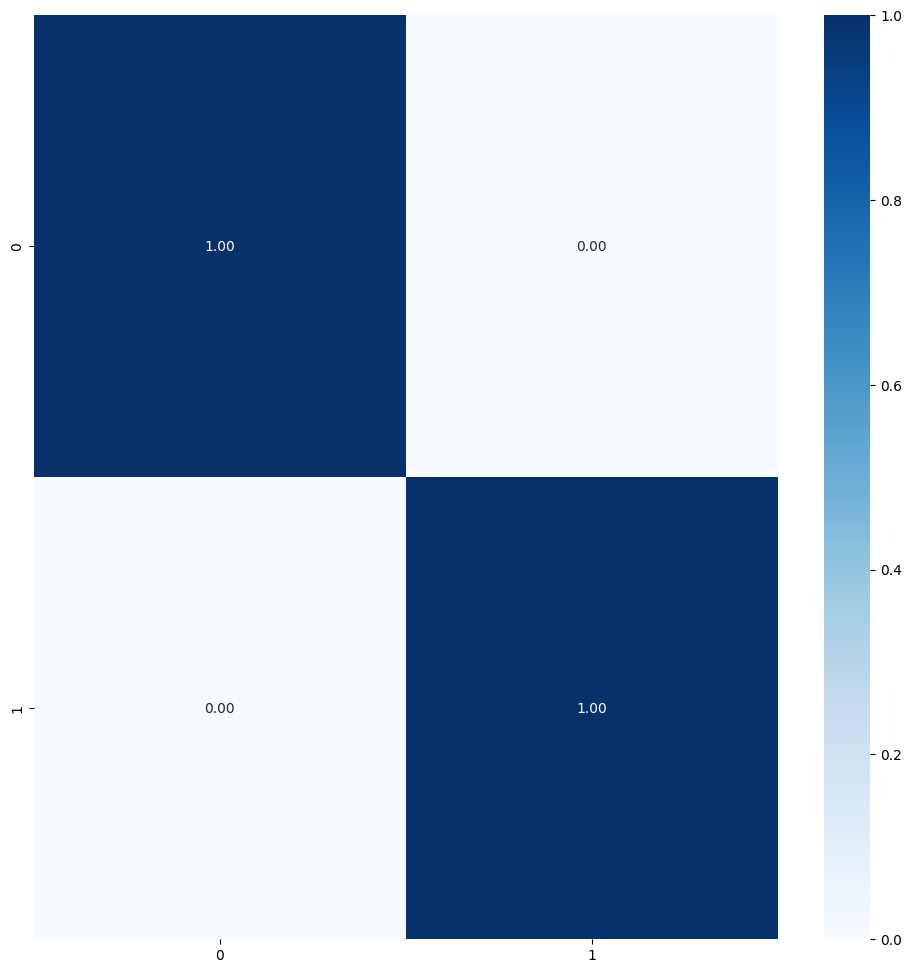


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
65/65 [==============================] - 25s 240ms/step - loss: 0.0761 - accuracy: 1.0000 - val_loss: 0.0608 - val_accuracy: 0.9978 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 11s 164ms/step - loss: 0.0516 - accuracy: 0.9995 - val_loss: 0.0452 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 12s 186ms/step - loss: 0.0410 - accuracy: 1.0000 - val_loss: 0.0371 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 11s 151ms

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15002_2.pkl
66/66 [==============================] - 7s 109ms/step - loss: 0.0015 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0015103654004633427
15/15 [==============================] - 3s 135ms/step - loss: 0.0015 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.0015114174457266927
15/15 [==============================] - 2s 112ms/step - loss: 0.0015 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0015103942714631557
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      

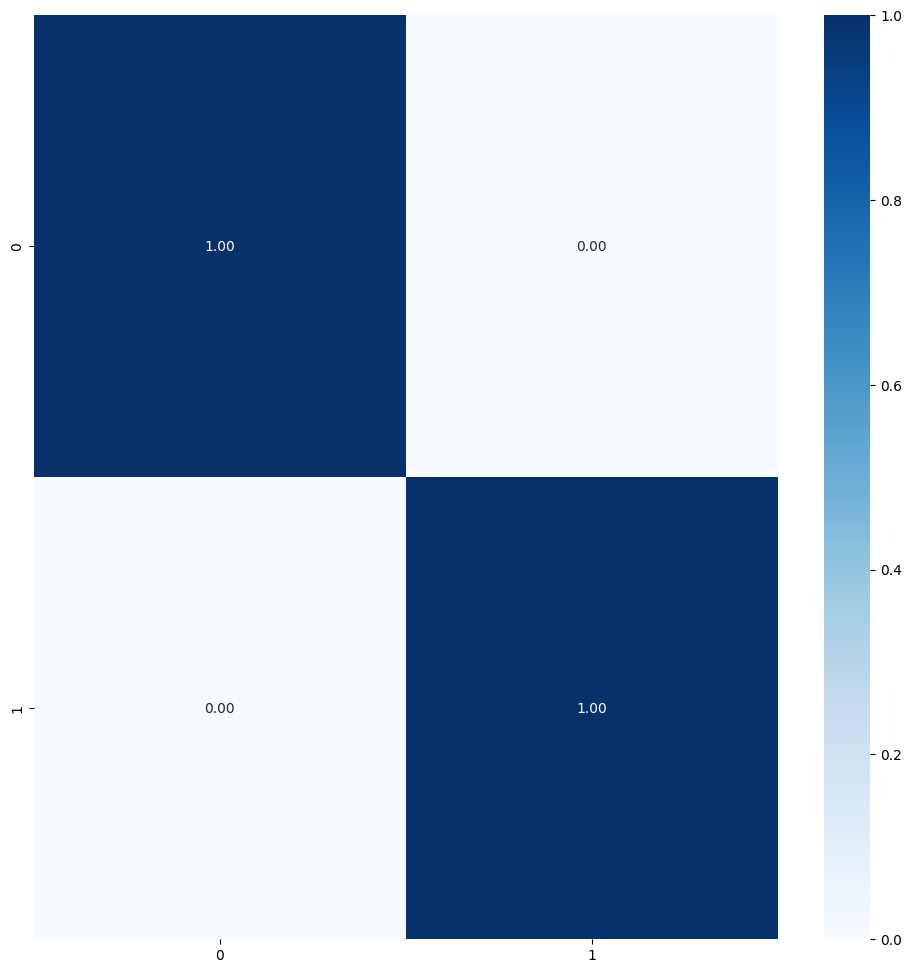


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
65/65 [==============================] - 26s 264ms/step - loss: 0.0768 - accuracy: 1.0000 - val_loss: 0.0574 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 12s 176ms/step - loss: 0.0448 - accuracy: 1.0000 - val_loss: 0.0342 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 10s 145ms/step - loss: 0.0275 - accuracy: 1.0000 - val_loss: 0.0225 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 7s 95ms/s

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15002_3.pkl
66/66 [==============================] - 9s 113ms/step - loss: 6.9220e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0006921966560184956
15/15 [==============================] - 2s 122ms/step - loss: 6.9466e-04 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.0006946644280105829
15/15 [==============================] - 2s 103ms/step - loss: 6.9235e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.00069235177943483
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       

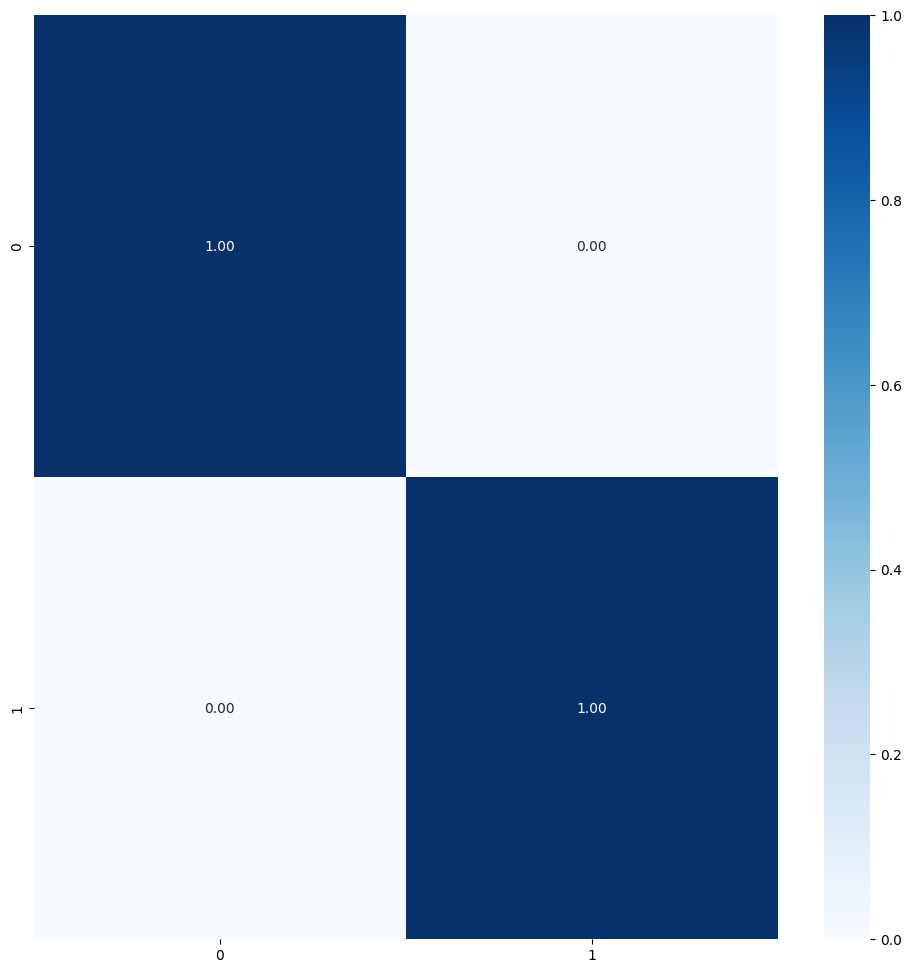


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
65/65 [==============================] - 25s 219ms/step - loss: 0.0763 - accuracy: 1.0000 - val_loss: 0.0580 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 9s 143ms/step - loss: 0.0439 - accuracy: 1.0000 - val_loss: 0.0336 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 11s 161ms/step - loss: 0.0267 - accuracy: 1.0000 - val_loss: 0.0208 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 11s 161ms/

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15002_4.pkl
66/66 [==============================] - 8s 108ms/step - loss: 0.0021 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0021436831448227167
15/15 [==============================] - 2s 128ms/step - loss: 0.0022 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.00215445039793849
15/15 [==============================] - 2s 108ms/step - loss: 0.0021 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0021449376363307238
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.

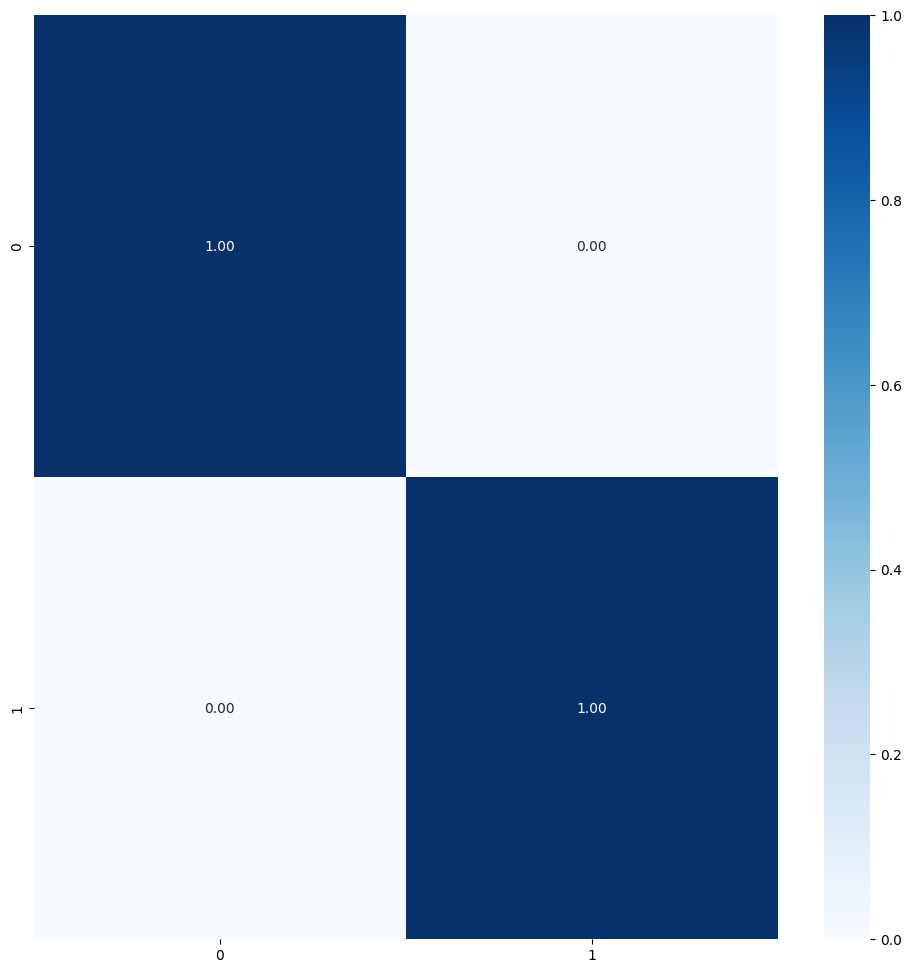


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
65/65 [==============================] - 24s 218ms/step - loss: 0.0797 - accuracy: 1.0000 - val_loss: 0.0654 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 2/50
65/65 [==============================] - 10s 155ms/step - loss: 0.0566 - accuracy: 1.0000 - val_loss: 0.0484 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
65/65 [==============================] - 11s 169ms/step - loss: 0.0420 - accuracy: 1.0000 - val_loss: 0.0361 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
65/65 [==============================] - 11s 158ms

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15002_5.pkl
66/66 [==============================] - 9s 133ms/step - loss: 7.2577e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0007257737452164292
15/15 [==============================] - 3s 114ms/step - loss: 7.2782e-04 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.0007278175326064229
15/15 [==============================] - 4s 176ms/step - loss: 7.2692e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0007269188645295799
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg     

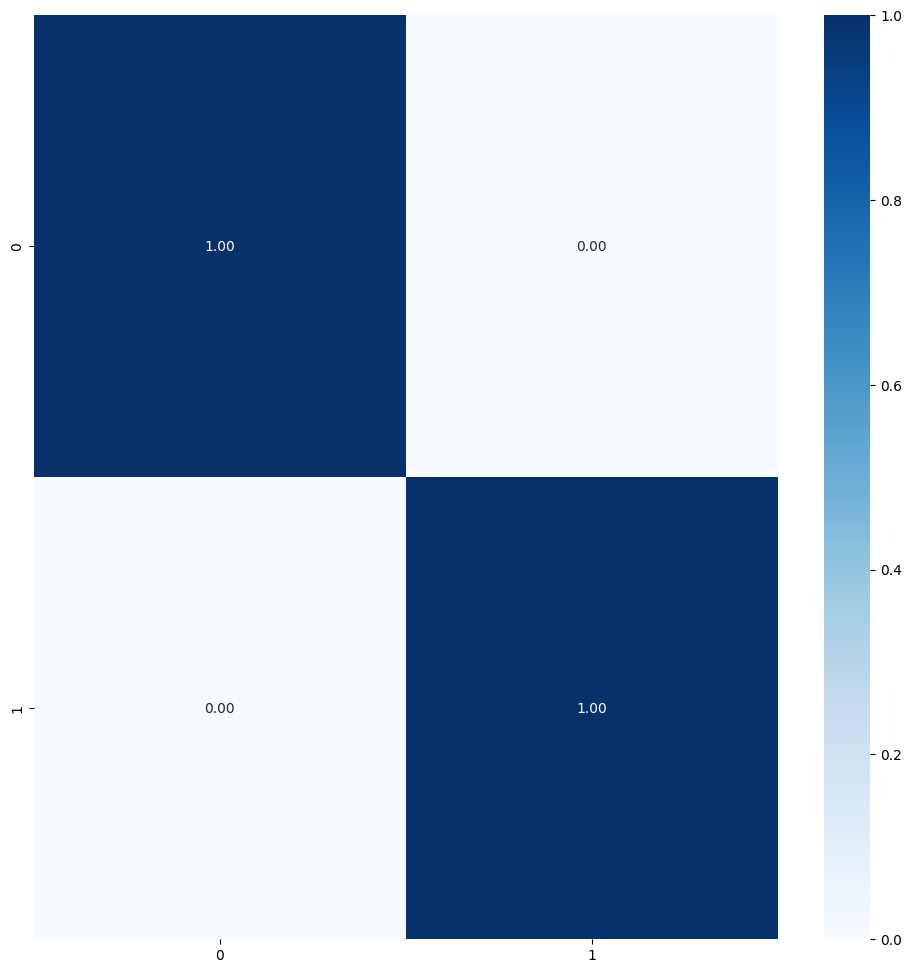


Best fold was 1 with val_accuracy: 1.0000
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0

Test Metrics
test_acc_list: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Test Accuracy with 5-fold: 1.0
test_loss_list: [0.0008097119862213731, 0.0015103942714631557, 0.00069235177943483, 0.0021449376363307238, 0.0007269188645295799]
Average Test Log Loss with 5-fold: 0.0011768629075959325

Precision List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Precision List with 5-fold: 1.0
Recall List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Recall List with 5-fold: 1.0
F1 Score List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average F1 Score List with 5-fold: 1.0

Metrics List Store

test_acc_list_all = [1.0]
test_loss_list_all = [0.0011768629075959325]
precision_list_all = [1.0]
recall_list_all = [1.0]
f1_score_list_all = [1.0]
La carpeta 2 fue eliminada.
CPU times: user 47min 45s, sys: 5min 20s, total: 53min 6s
Wall time: 52min 32s


In [17]:
%%time
###################################### Probar Dropout 0.4
num_classes = 2
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/3
name_save_model: MobileNet_tf_15003
Found 3150 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 31s 212ms/step - loss: 0.0190 - accuracy: 1.0000 - val_loss: 0.0111 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 23s 231ms/step 

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15003_1.pkl
99/99 [==============================] - 14s 129ms/step - loss: 9.1128e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0009112783591262996
22/22 [==============================] - 4s 151ms/step - loss: 0.0059 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.005916442722082138
22/22 [==============================] - 3s 132ms/step - loss: 9.1171e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0009117121808230877
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy         

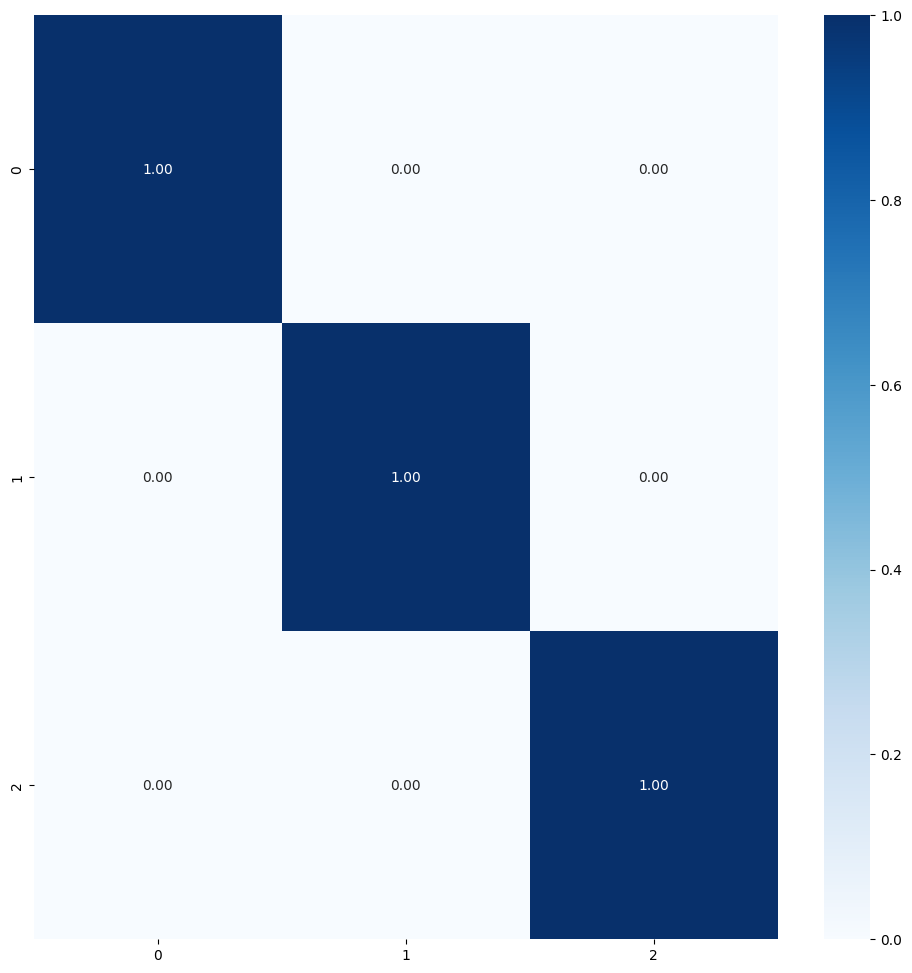


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 29s 189ms/step - loss: 0.0190 - accuracy: 1.0000 - val_loss: 0.0244 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 24s 244ms/step - loss: 0.0097 - accuracy: 1.0000 - val_loss: 0.0073 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
98/98 [==============================] - 16s 159ms/step - loss: 0.0058 - accuracy: 1.0000 - val_loss: 0.0080 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 4/50
98/98 [==============================] - 1

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15003_2.pkl
99/99 [==============================] - 21s 204ms/step - loss: 0.0023 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0023377398028969765
22/22 [==============================] - 4s 143ms/step - loss: 0.0110 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.01098497025668621
22/22 [==============================] - 4s 168ms/step - loss: 0.0023 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0023380089551210403
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                  

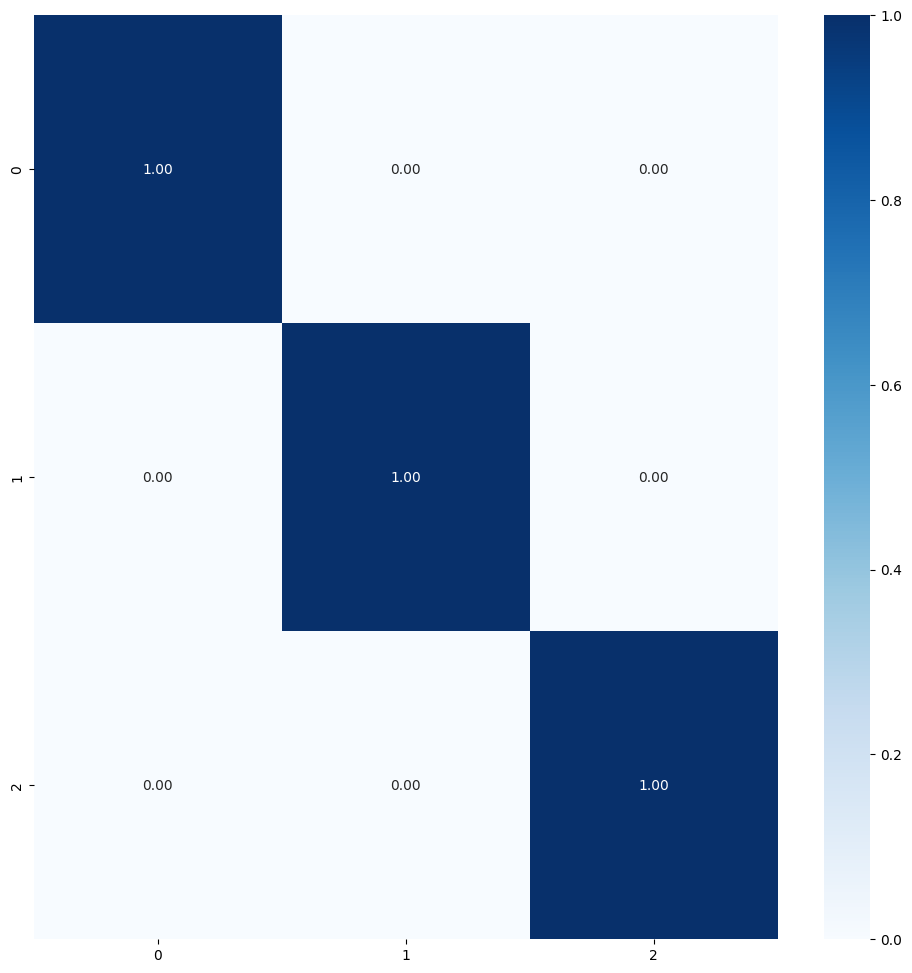


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 31s 208ms/step - loss: 0.0209 - accuracy: 1.0000 - val_loss: 0.0176 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 27s 278ms/step - loss: 0.0138 - accuracy: 1.0000 - val_loss: 0.0118 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
98/98 [==============================] - 20s 190ms/step - loss: 0.0105 - accuracy: 1.0000 - val_loss: 0.0096 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 4/50
98/98 [==============================] - 1

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15003_3.pkl
99/99 [==============================] - 15s 139ms/step - loss: 0.0058 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.005805534310638905
22/22 [==============================] - 3s 128ms/step - loss: 0.0058 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.005811500828713179
22/22 [==============================] - 3s 120ms/step - loss: 0.0058 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0058089992962777615
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00  

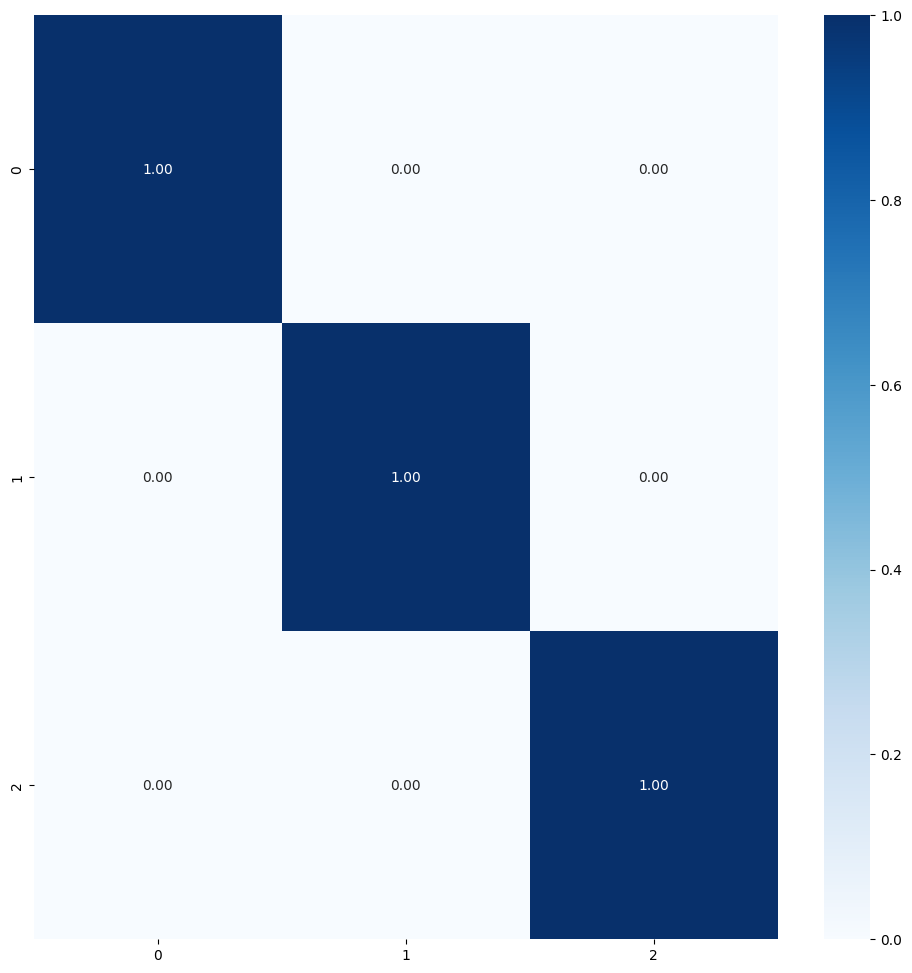


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 30s 191ms/step - loss: 0.0234 - accuracy: 0.9997 - val_loss: 0.0208 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 18s 186ms/step - loss: 0.0163 - accuracy: 0.9994 - val_loss: 0.0244 - val_accuracy: 0.9970 - lr: 1.0000e-04
Epoch 3/50
98/98 [==============================] - 22s 227ms/step - loss: 0.0140 - accuracy: 0.9997 - val_loss: 0.0185 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 4/50
98/98 [==============================] - 1

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15003_4.pkl
99/99 [==============================] - 16s 161ms/step - loss: 0.0016 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.001592070679180324
22/22 [==============================] - 4s 152ms/step - loss: 0.0027 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.0027022105641663074
22/22 [==============================] - 4s 135ms/step - loss: 0.0016 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0015922904713079333
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                 

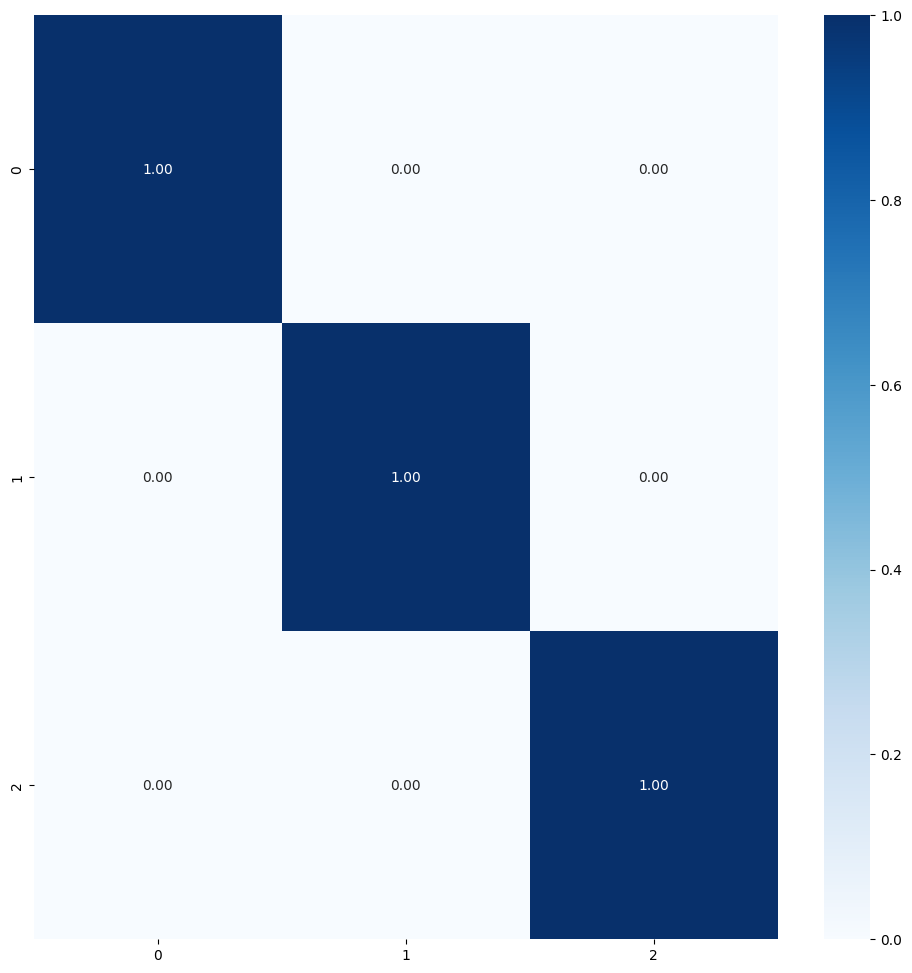


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 31s 211ms/step - loss: 0.0201 - accuracy: 1.0000 - val_loss: 0.0231 - val_accuracy: 0.9985 - lr: 1.0000e-04
Epoch 2/50
98/98 [==============================] - 18s 179ms/step - loss: 0.0106 - accuracy: 1.0000 - val_loss: 0.0082 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/50
98/98 [==============================] - 12s 119ms/step - loss: 0.0112 - accuracy: 0.9987 - val_loss: 0.0236 - val_accuracy: 0.9970 - lr: 1.0000e-04
Epoch 4/50
98/98 [==============================] - 1

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15003_5.pkl
99/99 [==============================] - 15s 144ms/step - loss: 0.0018 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0018268860876560211
22/22 [==============================] - 4s 124ms/step - loss: 0.0059 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.005897402763366699
22/22 [==============================] - 4s 139ms/step - loss: 0.0018 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.001827870961278677
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                  

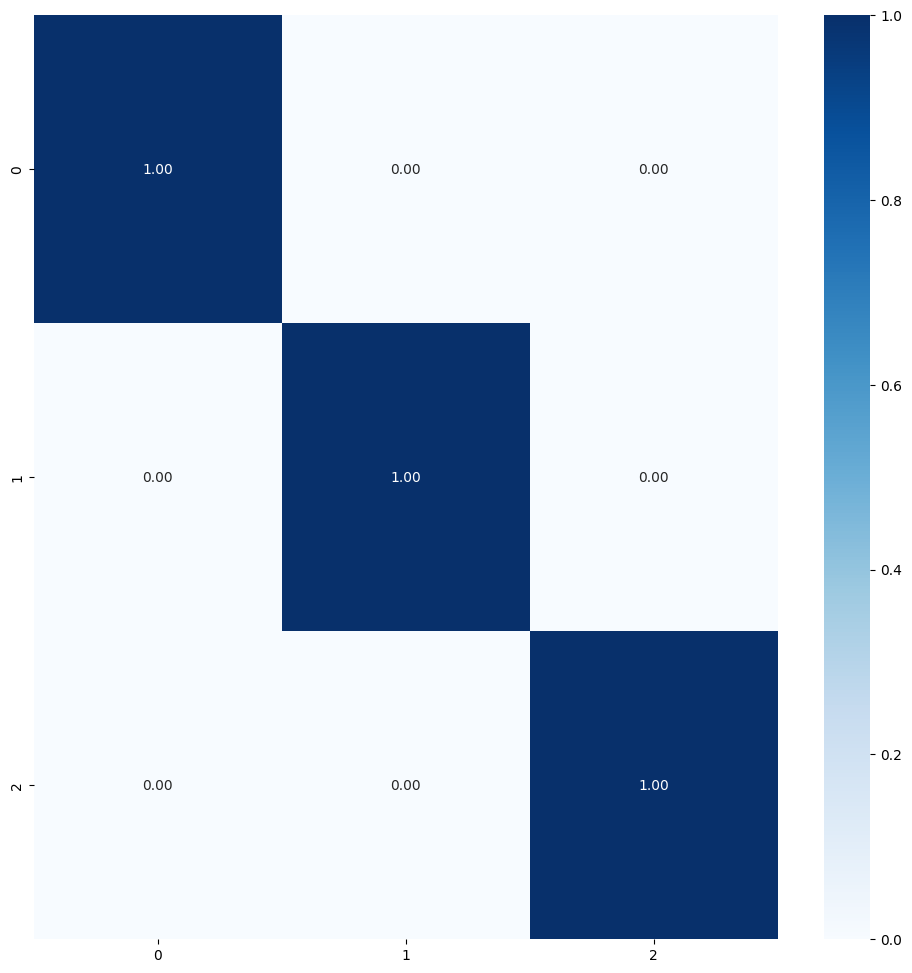


Best fold was 1 with val_accuracy: 1.0000
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0

Test Metrics
test_acc_list: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Test Accuracy with 5-fold: 1.0
test_loss_list: [0.0009117121808230877, 0.0023380089551210403, 0.0058089992962777615, 0.0015922904713079333, 0.001827870961278677]
Average Test Log Loss with 5-fold: 0.0024957763729617

Precision List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Precision List with 5-fold: 1.0
Recall List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Recall List with 5-fold: 1.0
F1 Score List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average F1 Score List with 5-fold: 1.0

Metrics List Store

test_acc_list_all = [1.0, 1.0]
test_loss_list_all = [0.0011768629075959325, 0.0024957763729617]
precision_list_all = [1.0, 1.0]
recall_list_all = [1.0, 1.0]
f1_score_list_all = [1.0, 1.0]
La carpeta 3 fue eliminada.
CPU times: user 1h 19min 56s, sys: 10min 3s, total: 1h 30min
Wall time: 1h 20min 52s


In [18]:
%%time

num_classes = 3
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/4
name_save_model: MobileNet_tf_15004
Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50
131/131 [==============================] - 28s 132ms/step - loss: 0.0107 - accuracy: 1.0000 - val_loss: 0.0324 - val_accuracy: 0.9978 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 2

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15004_1.pkl
132/132 [==============================] - 17s 128ms/step - loss: 0.0021 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0020593341905623674
29/29 [==============================] - 5s 163ms/step - loss: 0.0302 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.03019145503640175
29/29 [==============================] - 4s 135ms/step - loss: 0.0172 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.01715991273522377
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00    

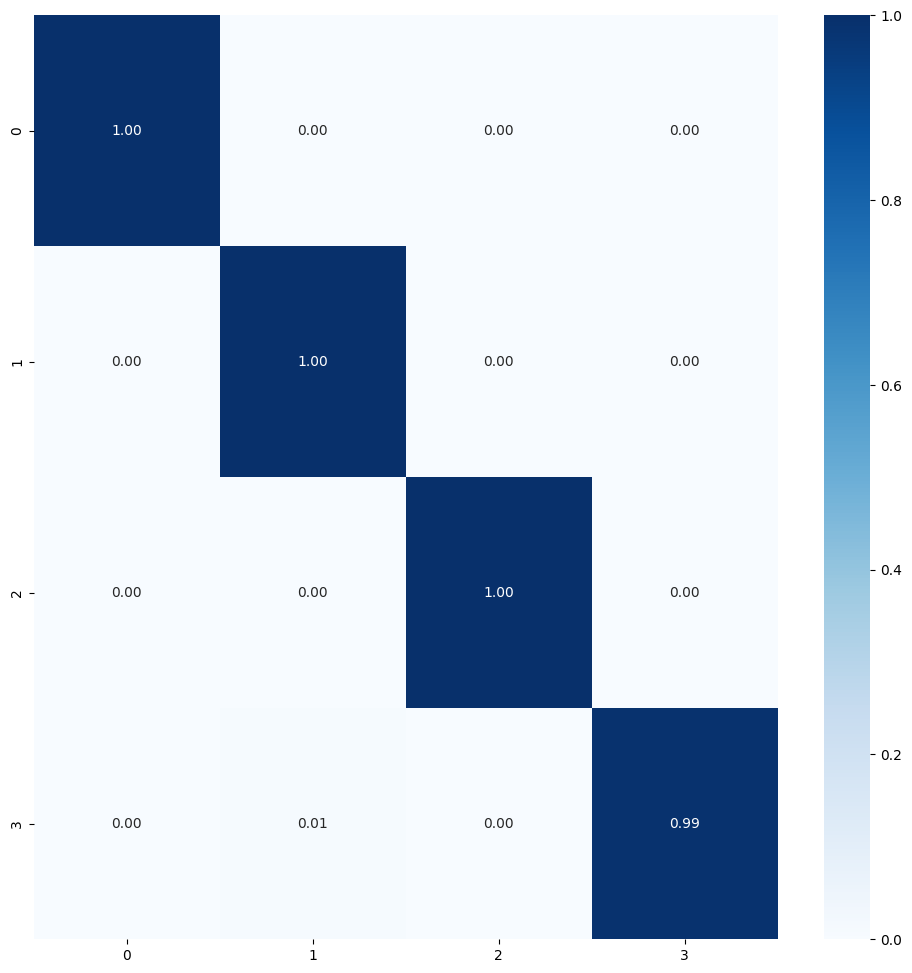


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50
131/131 [==============================] - 34s 176ms/step - loss: 0.0116 - accuracy: 1.0000 - val_loss: 0.0300 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 22s 163ms/step - loss: 0.0066 - accuracy: 1.0000 - val_loss: 0.0310 - val_accuracy: 0.9967 - lr: 1.0000e-04
Epoch 3/50
131/131 [==============================] - 21s 162ms/step - loss: 0.0080 - accuracy: 0.9990 - val_loss: 0.0408 - val_accuracy: 0.9900 - lr: 1.0000e-04
Epoch 4/50
131/131 [==========================

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15004_2.pkl
132/132 [==============================] - 17s 127ms/step - loss: 0.0035 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0035383296199142933
29/29 [==============================] - 5s 121ms/step - loss: 0.0331 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.033056698739528656
29/29 [==============================] - 4s 140ms/step - loss: 0.0239 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.023853212594985962
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00  

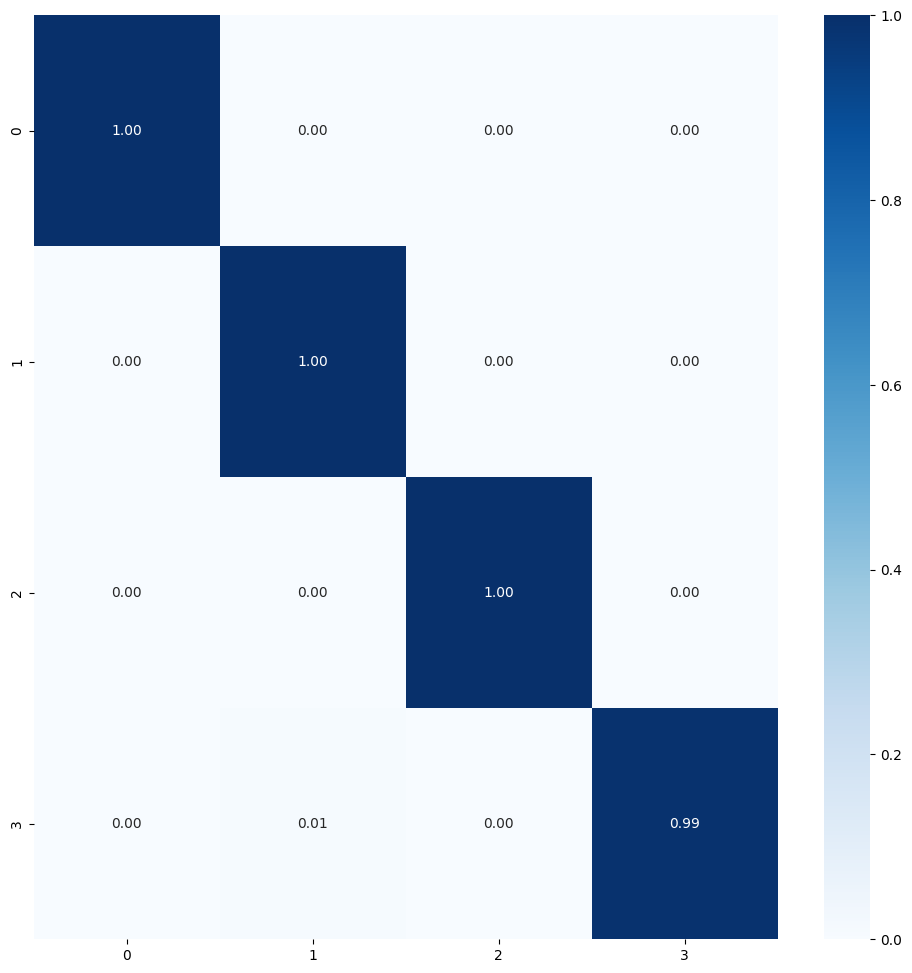


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50
131/131 [==============================] - 35s 185ms/step - loss: 0.0113 - accuracy: 1.0000 - val_loss: 0.0301 - val_accuracy: 0.9967 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 21s 156ms/step - loss: 0.0061 - accuracy: 0.9998 - val_loss: 0.0354 - val_accuracy: 0.9967 - lr: 1.0000e-04
Epoch 3/50
131/131 [==============================] - 20s 153ms/step - loss: 0.0091 - accuracy: 0.9993 - val_loss: 0.0759 - val_accuracy: 0.9844 - lr: 1.0000e-04
Epoch 4/50
131/131 [==========================

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15004_3.pkl
132/132 [==============================] - 16s 120ms/step - loss: 0.0042 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.004185010213404894
29/29 [==============================] - 4s 133ms/step - loss: 0.0310 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.031017422676086426
29/29 [==============================] - 5s 119ms/step - loss: 0.0287 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.028661321848630905
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00   

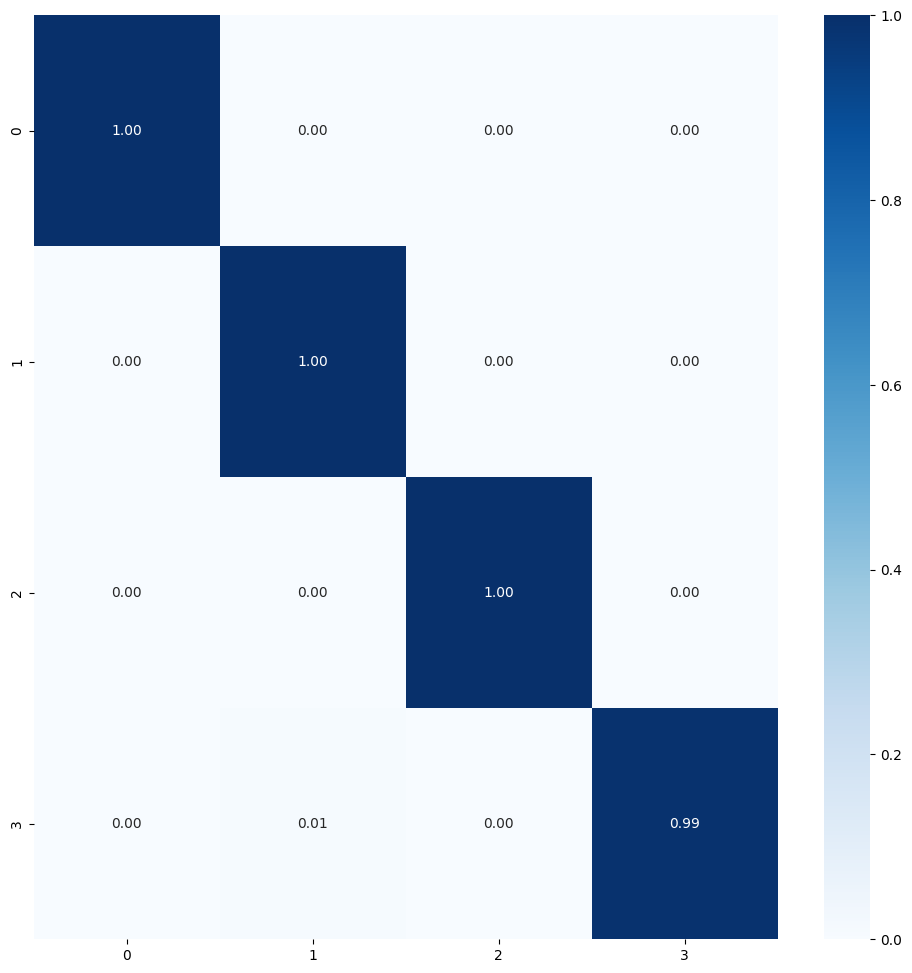


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50
131/131 [==============================] - 38s 210ms/step - loss: 0.0120 - accuracy: 0.9998 - val_loss: 0.0231 - val_accuracy: 0.9978 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 21s 156ms/step - loss: 0.0084 - accuracy: 1.0000 - val_loss: 0.0428 - val_accuracy: 0.9967 - lr: 1.0000e-04
Epoch 3/50
131/131 [==============================] - 21s 161ms/step - loss: 0.0108 - accuracy: 0.9993 - val_loss: 0.0443 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 4/50
131/131 [==========================

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15004_4.pkl
132/132 [==============================] - 18s 128ms/step - loss: 0.0025 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0024952013045549393
29/29 [==============================] - 7s 224ms/step - loss: 0.0245 - accuracy: 0.9978
Validation Accuracy: 0.9977777600288391
Validation Log Loss: 0.02448306418955326
29/29 [==============================] - 7s 254ms/step - loss: 0.0244 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.024355586618185043
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00  

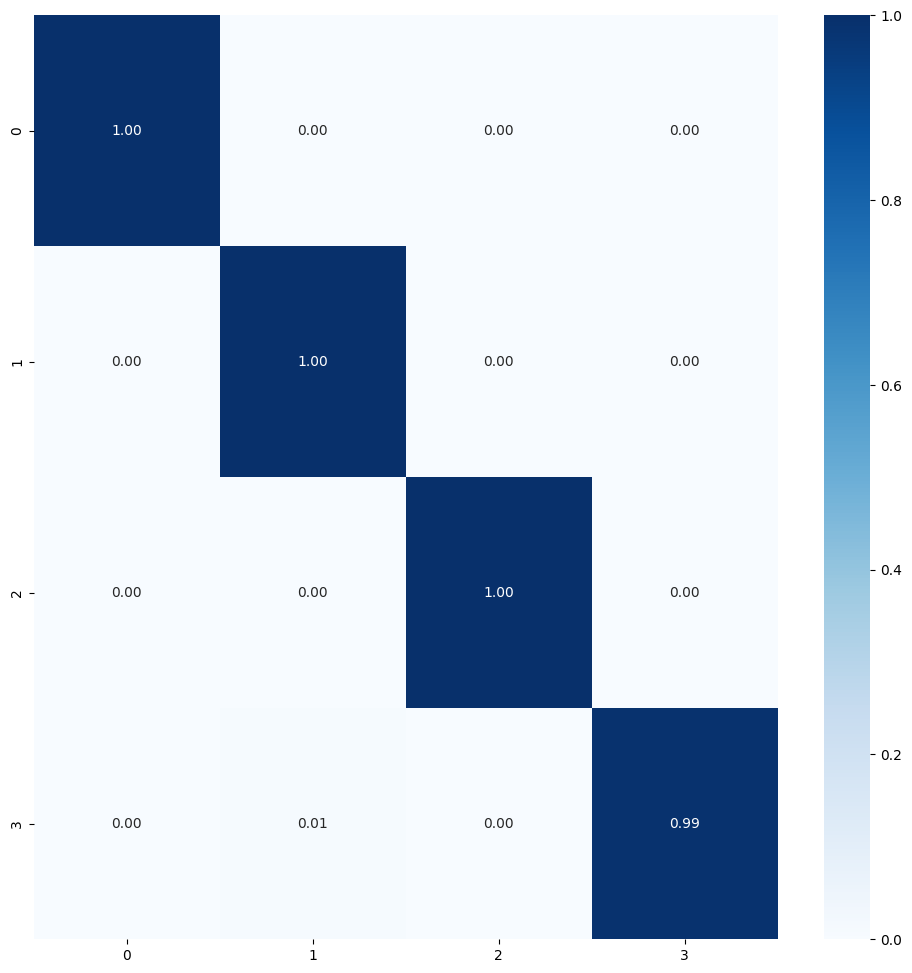


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50
131/131 [==============================] - 35s 185ms/step - loss: 0.0109 - accuracy: 1.0000 - val_loss: 0.0301 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 2/50
131/131 [==============================] - 23s 171ms/step - loss: 0.0086 - accuracy: 0.9993 - val_loss: 0.0329 - val_accuracy: 0.9967 - lr: 1.0000e-04
Epoch 3/50
131/131 [==============================] - 24s 182ms/step - loss: 0.0082 - accuracy: 0.9993 - val_loss: 0.0213 - val_accuracy: 0.9944 - lr: 1.0000e-04
Epoch 4/50
131/131 [==========================

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15004_5.pkl
132/132 [==============================] - 17s 127ms/step - loss: 0.0025 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0025265926960855722
29/29 [==============================] - 4s 124ms/step - loss: 0.0280 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.02802829071879387
29/29 [==============================] - 5s 153ms/step - loss: 0.0195 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.01946537382900715
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 224   0   1]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00     

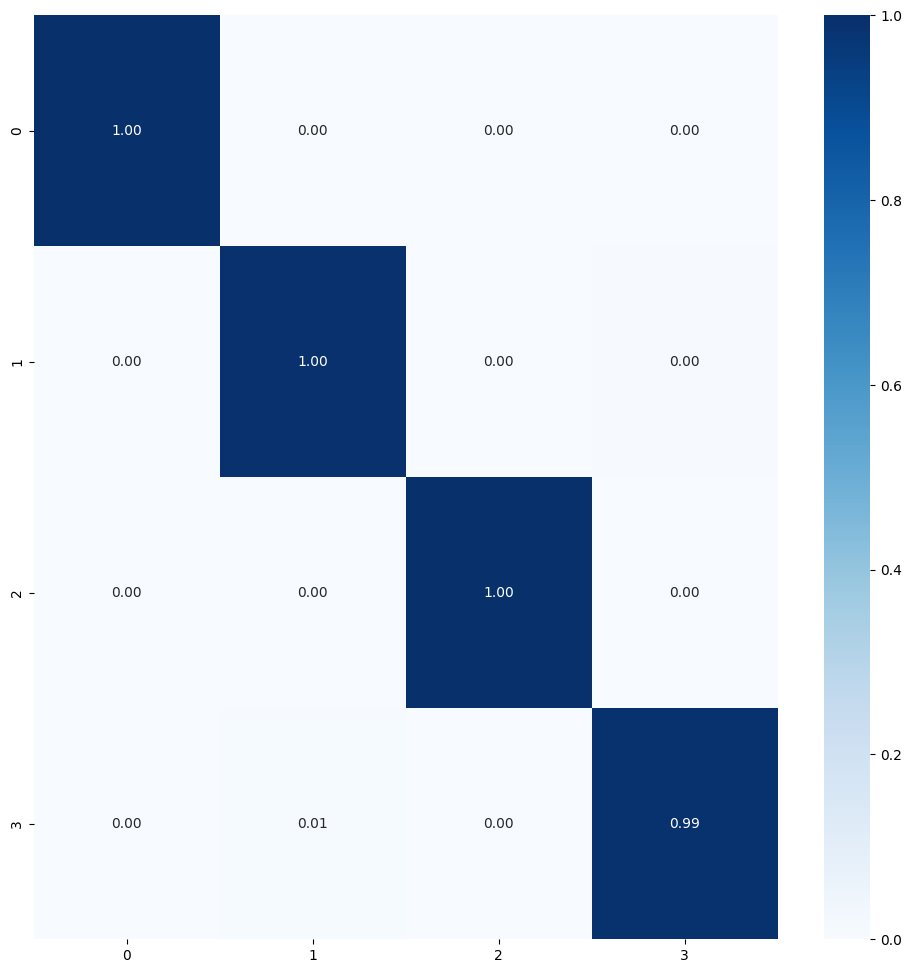


Best fold was 1 with val_accuracy: 0.9978
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9975446462631226

Test Metrics
test_acc_list: [0.9977777600288391, 0.9977777600288391, 0.9977777600288391, 0.9977777600288391, 0.996666669845581]
Average Test Accuracy with 5-fold: 0.9975555419921875
test_loss_list: [0.01715991273522377, 0.023853212594985962, 0.028661321848630905, 0.024355586618185043, 0.01946537382900715]
Average Test Log Loss with 5-fold: 0.022699081525206565

Precision List: [0.9977973568281938, 0.9977973568281938, 0.9977973568281938, 0.9977973568281938, 0.9966715391908976]
Average Precision List with 5-fold: 0.9975721933007347
Recall List: [0.9977777777777778, 0.9977777777777778, 0.9977777777777778, 0.9977777777777778, 0.9966666666666667]
Average Recall List with 5-fold: 0.9975555555555555
F1 Score List: [0.9977777338811631, 0.9977777338811631, 0.9977777338811631, 0.9977777338811631, 0.99666665020568]
Average F1 Score List with 5-fold: 0.997

In [19]:
%%time

num_classes = 4
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/5
name_save_model: MobileNet_tf_15005
Found 5250 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 41s 187ms/step - loss: 0.1112 - accuracy: 0.9990 - val_loss: 0.1316 - val_accuracy: 0.9929 - lr: 1.0000e-04
Epoch 2/50
164/164 [=========================

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15005_1.pkl
165/165 [==============================] - 22s 130ms/step - loss: 0.0362 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.03621324151754379
36/36 [==============================] - 5s 146ms/step - loss: 0.0626 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.06264369934797287
36/36 [==============================] - 6s 141ms/step - loss: 0.0682 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.06821009516716003
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.

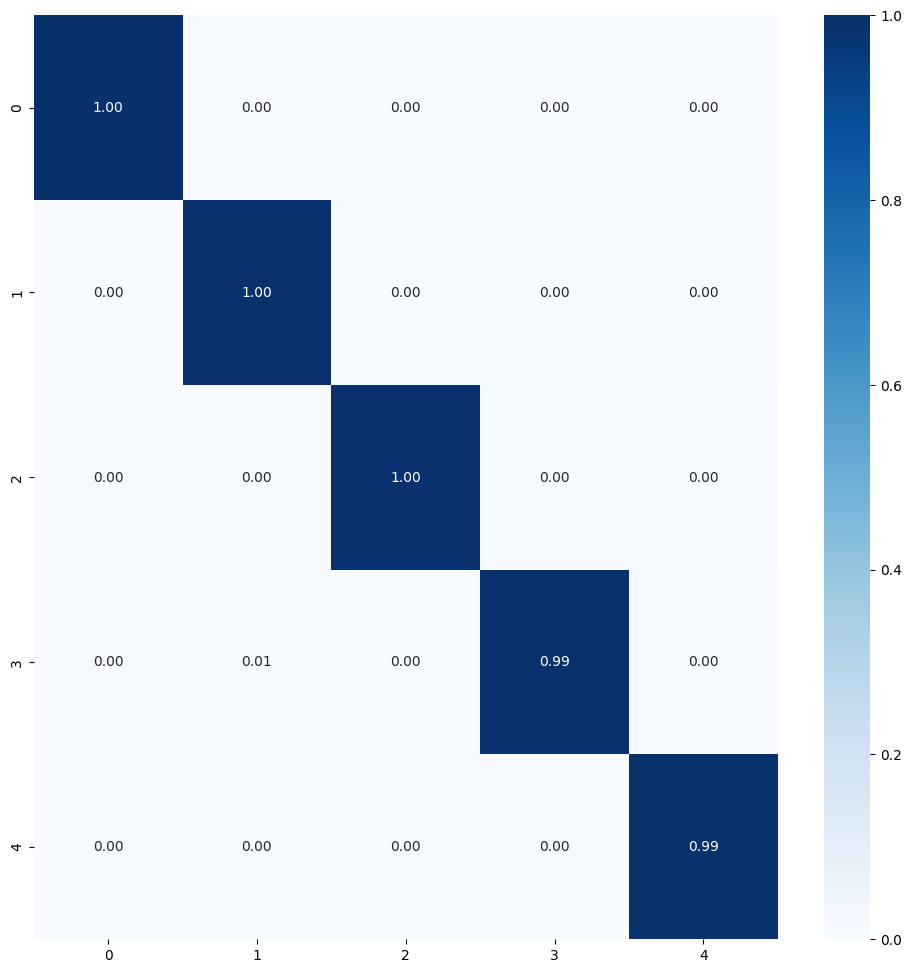


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 40s 184ms/step - loss: 0.1105 - accuracy: 0.9992 - val_loss: 0.1280 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 2/50
164/164 [==============================] - 34s 210ms/step - loss: 0.0958 - accuracy: 0.9987 - val_loss: 0.1547 - val_accuracy: 0.9857 - lr: 1.0000e-04
Epoch 3/50
164/164 [==============================] - 31s 183ms/step - loss: 0.0855 - accuracy: 0.9987 - val_loss: 0.1202 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 4/50
164/164 [==========================

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15005_2.pkl
165/165 [==============================] - 22s 133ms/step - loss: 0.0238 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.02384769916534424
36/36 [==============================] - 5s 125ms/step - loss: 0.0502 - accuracy: 0.9964
Validation Accuracy: 0.9964444637298584
Validation Log Loss: 0.050229642540216446
36/36 [==============================] - 5s 127ms/step - loss: 0.0573 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.05731101334095001
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 225   0   0]
 [  0   2   0 223   0]
 [  0   1   2   0 222]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1

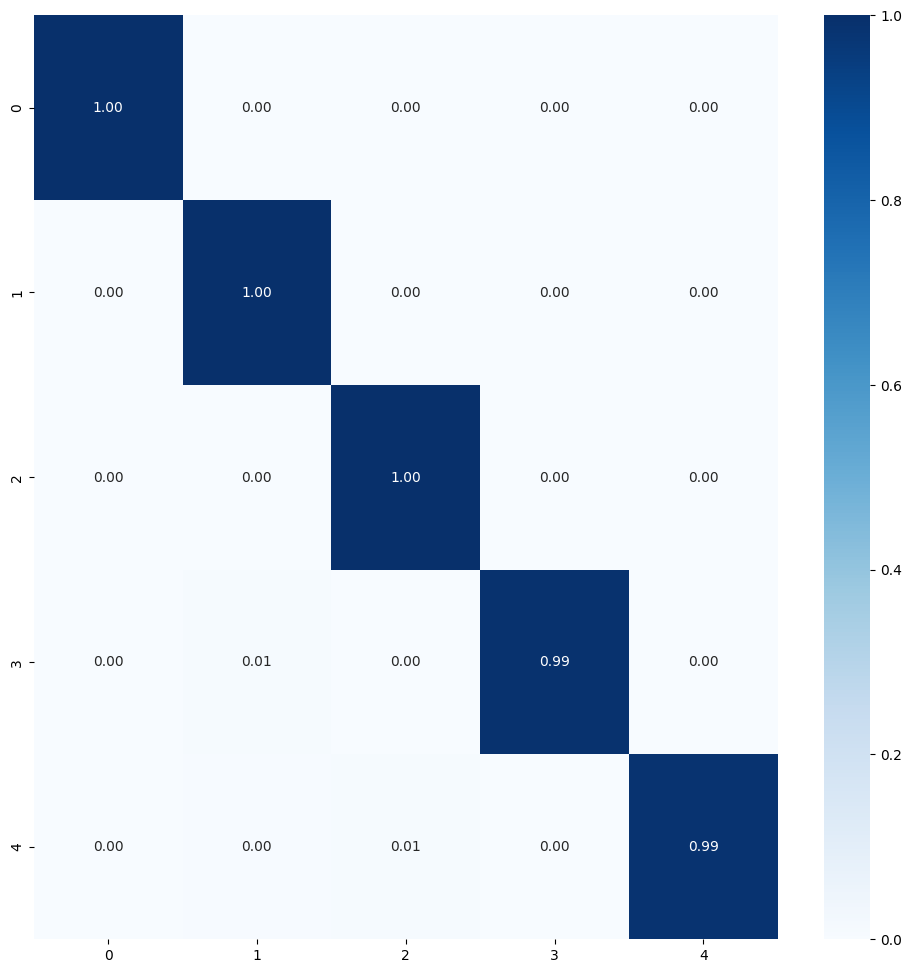


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 55s 264ms/step - loss: 0.1088 - accuracy: 0.9983 - val_loss: 0.1192 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 2/50
164/164 [==============================] - 30s 176ms/step - loss: 0.0930 - accuracy: 0.9990 - val_loss: 0.1168 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 3/50
164/164 [==============================] - 28s 167ms/step - loss: 0.0847 - accuracy: 0.9996 - val_loss: 0.1783 - val_accuracy: 0.9759 - lr: 1.0000e-04
Epoch 4/50
164/164 [==========================

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15005_3.pkl
165/165 [==============================] - 21s 122ms/step - loss: 0.0345 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.034534670412540436
36/36 [==============================] - 5s 124ms/step - loss: 0.0619 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.061942797154188156
36/36 [==============================] - 5s 127ms/step - loss: 0.0618 - accuracy: 0.9938
Test Accuracy: 0.9937777519226074
Test Log Loss: 0.061780158430337906
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   2   0 222]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99     

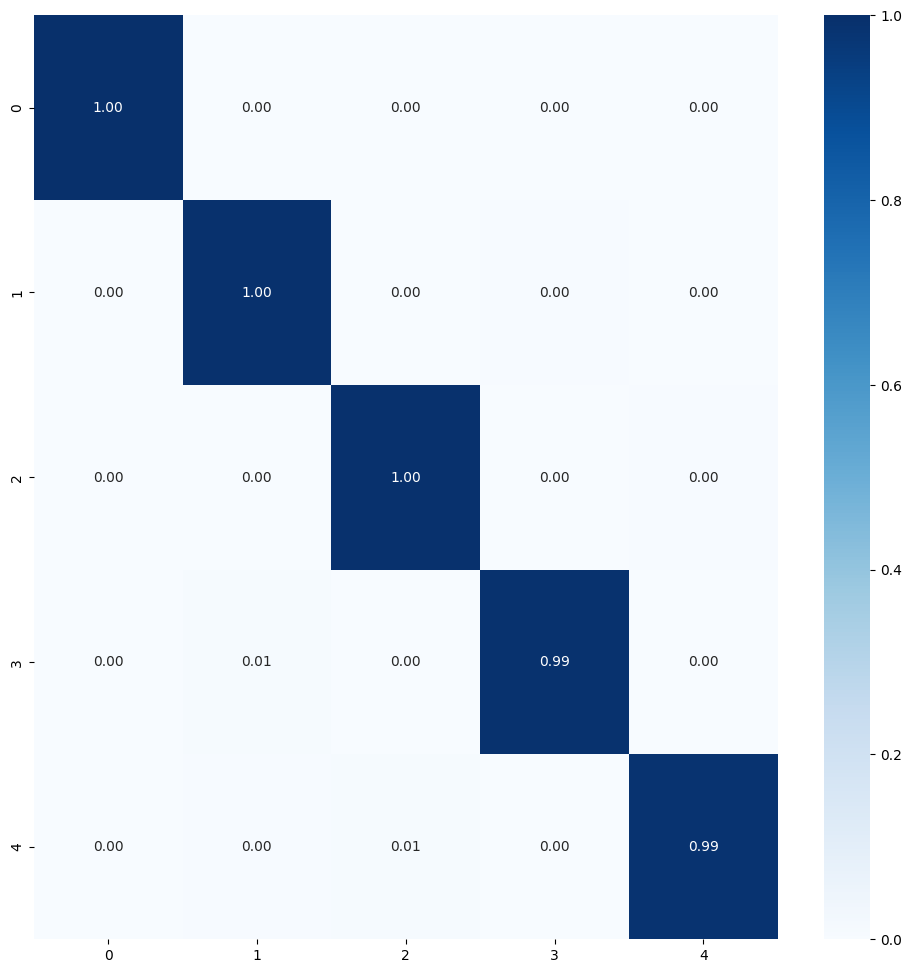


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 42s 194ms/step - loss: 0.1132 - accuracy: 0.9979 - val_loss: 0.1216 - val_accuracy: 0.9964 - lr: 1.0000e-04
Epoch 2/50
164/164 [==============================] - 32s 196ms/step - loss: 0.0967 - accuracy: 0.9990 - val_loss: 0.1178 - val_accuracy: 0.9946 - lr: 1.0000e-04
Epoch 3/50
164/164 [==============================] - 26s 156ms/step - loss: 0.0854 - accuracy: 0.9996 - val_loss: 0.1077 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 4/50
164/164 [==========================

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15005_4.pkl
165/165 [==============================] - 21s 125ms/step - loss: 0.0258 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.025783369317650795
36/36 [==============================] - 5s 123ms/step - loss: 0.0540 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.05401480942964554
36/36 [==============================] - 5s 123ms/step - loss: 0.0546 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.05460291728377342
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   0   2   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.

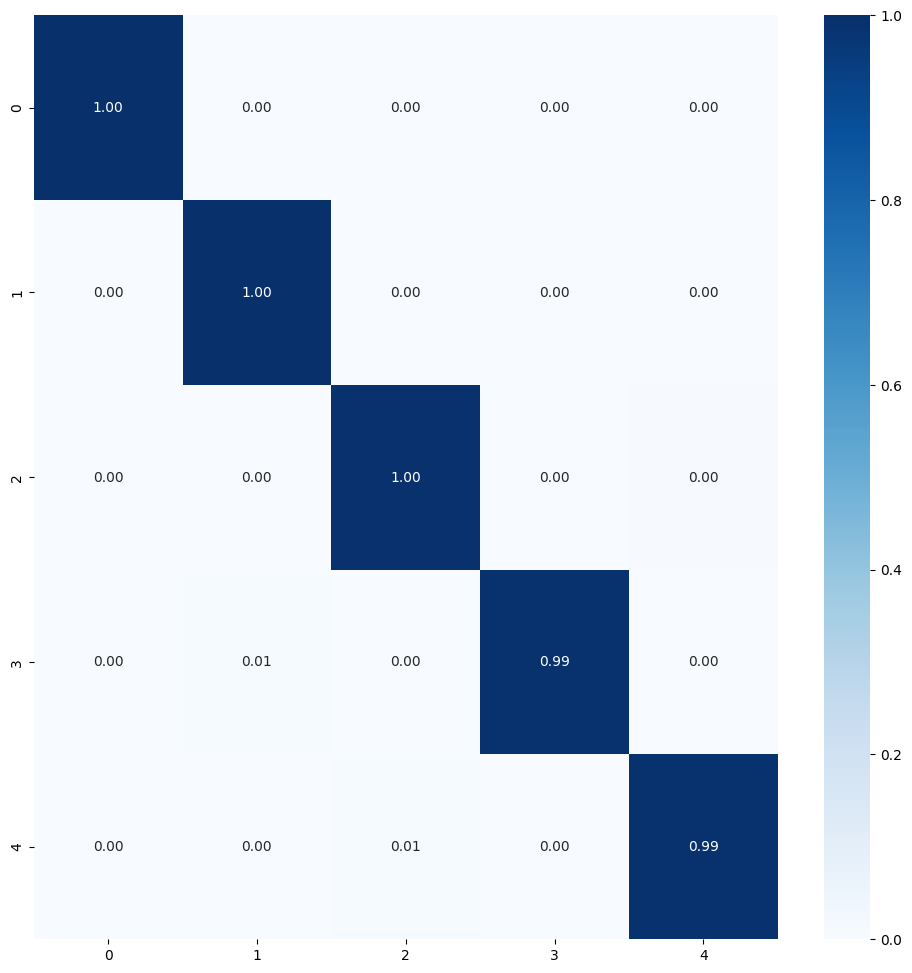


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 40s 179ms/step - loss: 0.1077 - accuracy: 0.9985 - val_loss: 0.1227 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 2/50
164/164 [==============================] - 28s 171ms/step - loss: 0.0871 - accuracy: 1.0000 - val_loss: 0.1114 - val_accuracy: 0.9946 - lr: 1.0000e-04
Epoch 3/50
164/164 [==============================] - 26s 155ms/step - loss: 0.0758 - accuracy: 0.9998 - val_loss: 0.1004 - val_accuracy: 0.9946 - lr: 1.0000e-04
Epoch 4/50
164/164 [==========================

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15005_5.pkl
165/165 [==============================] - 23s 136ms/step - loss: 0.0151 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.015146811492741108
36/36 [==============================] - 5s 144ms/step - loss: 0.0426 - accuracy: 0.9964
Validation Accuracy: 0.9964444637298584
Validation Log Loss: 0.04255462437868118
36/36 [==============================] - 5s 128ms/step - loss: 0.0455 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.045455265790224075
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 225   0   0]
 [  0   2   0 223   0]
 [  0   1   2   0 222]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      

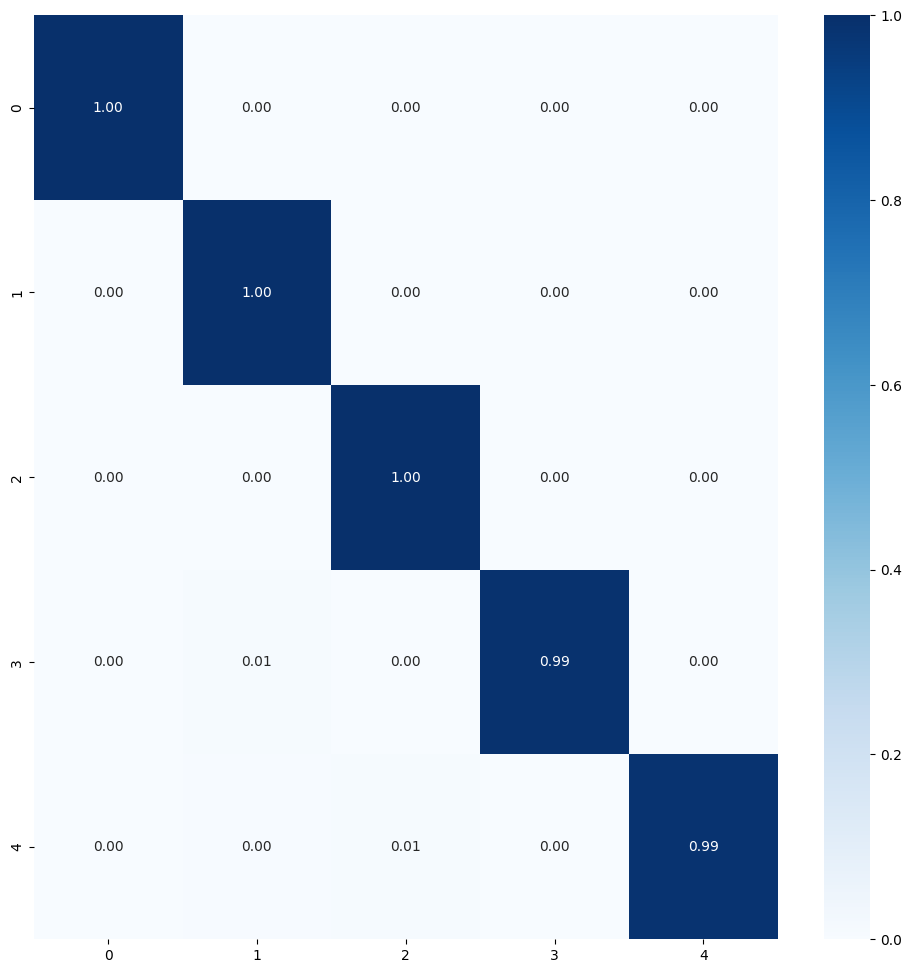


Best fold was 4 with val_accuracy: 0.9982
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9973214268684387

Test Metrics
test_acc_list: [0.9946666955947876, 0.995555579662323, 0.9937777519226074, 0.995555579662323, 0.995555579662323]
Average Test Accuracy with 5-fold: 0.9950222373008728
test_loss_list: [0.06821009516716003, 0.05731101334095001, 0.061780158430337906, 0.05460291728377342, 0.045455265790224075]
Average Test Log Loss with 5-fold: 0.05747189000248909

Precision List: [0.9946822250192294, 0.9956063065151867, 0.9937971985600036, 0.9955751168152732, 0.9956063065151867]
Average Precision List with 5-fold: 0.9950534306849759
Recall List: [0.9946666666666667, 0.9955555555555555, 0.9937777777777776, 0.9955555555555555, 0.9955555555555555]
Average Recall List with 5-fold: 0.9950222222222223
F1 Score List: [0.9946685938160404, 0.9955554019144776, 0.993777694374405, 0.9955555072694745, 0.9955554019144776]
Average F1 Score List with 5-fold: 0.995022

In [20]:
%%time

num_classes = 5
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/6
name_save_model: MobileNet_tf_15006
Found 6300 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 45s 174ms/step - loss: 0.0208 - accuracy: 0.9989 - val_loss: 0.0462 - val_accuracy: 0.9926 - lr: 1.0000e-04
Epoch 2/50
196/196 [==================

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15006_1.pkl
197/197 [==============================] - 29s 148ms/step - loss: 0.0029 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0028797530103474855
43/43 [==============================] - 7s 143ms/step - loss: 0.0304 - accuracy: 0.9948
Validation Accuracy: 0.9948148131370544
Validation Log Loss: 0.030419427901506424
43/43 [==============================] - 7s 151ms/step - loss: 0.0278 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.027846306562423706
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00

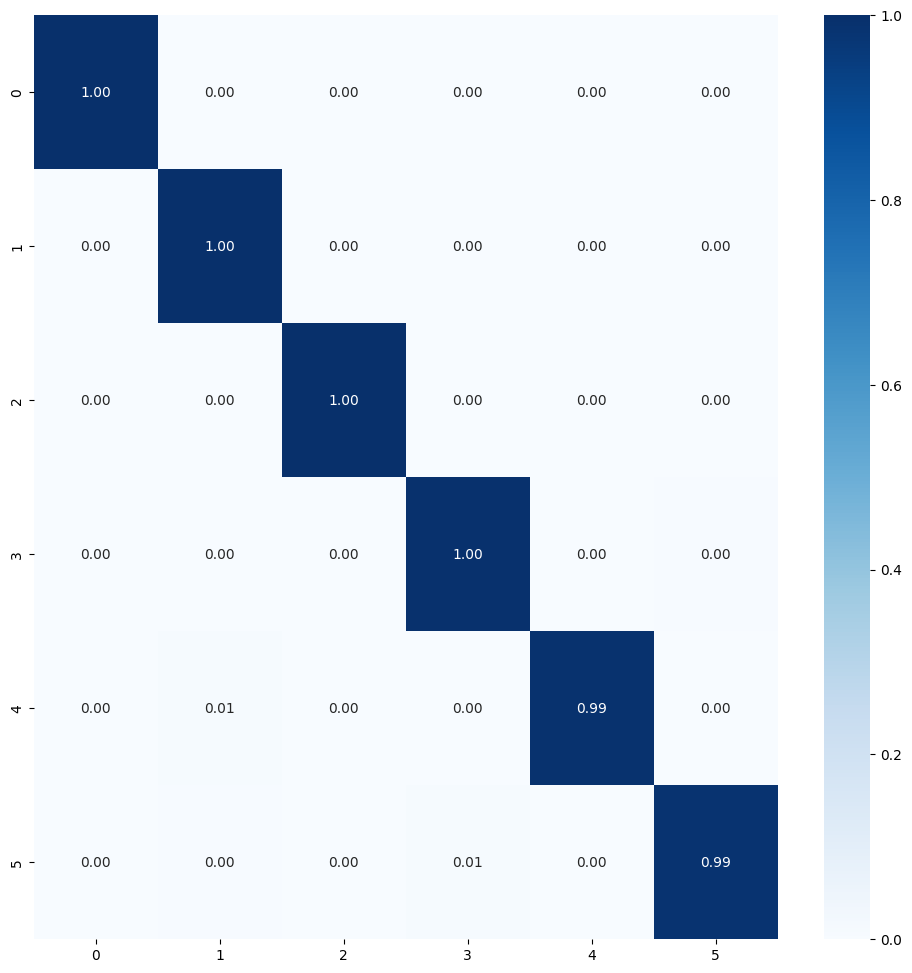


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 56s 221ms/step - loss: 0.0223 - accuracy: 0.9990 - val_loss: 0.0602 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 2/50
196/196 [==============================] - 34s 169ms/step - loss: 0.0197 - accuracy: 0.9990 - val_loss: 0.2104 - val_accuracy: 0.9613 - lr: 1.0000e-04
Epoch 3/50
196/196 [==============================] - 47s 237ms/step - loss: 0.0163 - accuracy: 0.9998 - val_loss: 0.0467 - val_accuracy: 0.9940 - lr: 1.0000e-04
Epoch 4/50
196/196 [==========================

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15006_2.pkl
197/197 [==============================] - 33s 166ms/step - loss: 0.0046 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.004553601611405611
43/43 [==============================] - 6s 129ms/step - loss: 0.0333 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.03334920480847359
43/43 [==============================] - 9s 201ms/step - loss: 0.0393 - accuracy: 0.9948
Test Accuracy: 0.9948148131370544
Test Log Loss: 0.039258040487766266
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00  

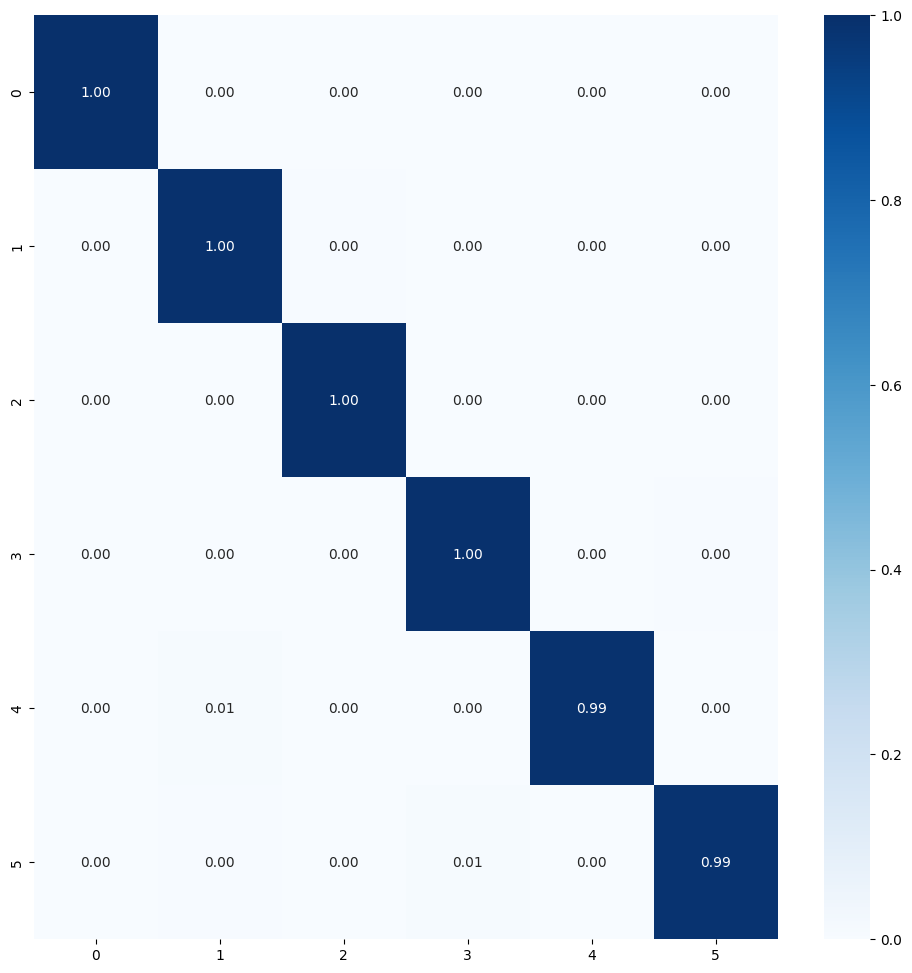


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 54s 225ms/step - loss: 0.0220 - accuracy: 0.9992 - val_loss: 0.0676 - val_accuracy: 0.9881 - lr: 1.0000e-04
Epoch 2/50
196/196 [==============================] - 49s 249ms/step - loss: 0.0166 - accuracy: 0.9997 - val_loss: 0.0462 - val_accuracy: 0.9948 - lr: 1.0000e-04
Epoch 3/50
196/196 [==============================] - 37s 188ms/step - loss: 0.0181 - accuracy: 0.9992 - val_loss: 0.0929 - val_accuracy: 0.9851 - lr: 1.0000e-04
Epoch 4/50
196/196 [==========================

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15006_3.pkl
197/197 [==============================] - 27s 136ms/step - loss: 0.0017 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.001704677240923047
43/43 [==============================] - 8s 181ms/step - loss: 0.0310 - accuracy: 0.9948
Validation Accuracy: 0.9948148131370544
Validation Log Loss: 0.03100542351603508
43/43 [==============================] - 6s 135ms/step - loss: 0.0301 - accuracy: 0.9948
Test Accuracy: 0.9948148131370544
Test Log Loss: 0.030052388086915016
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00 

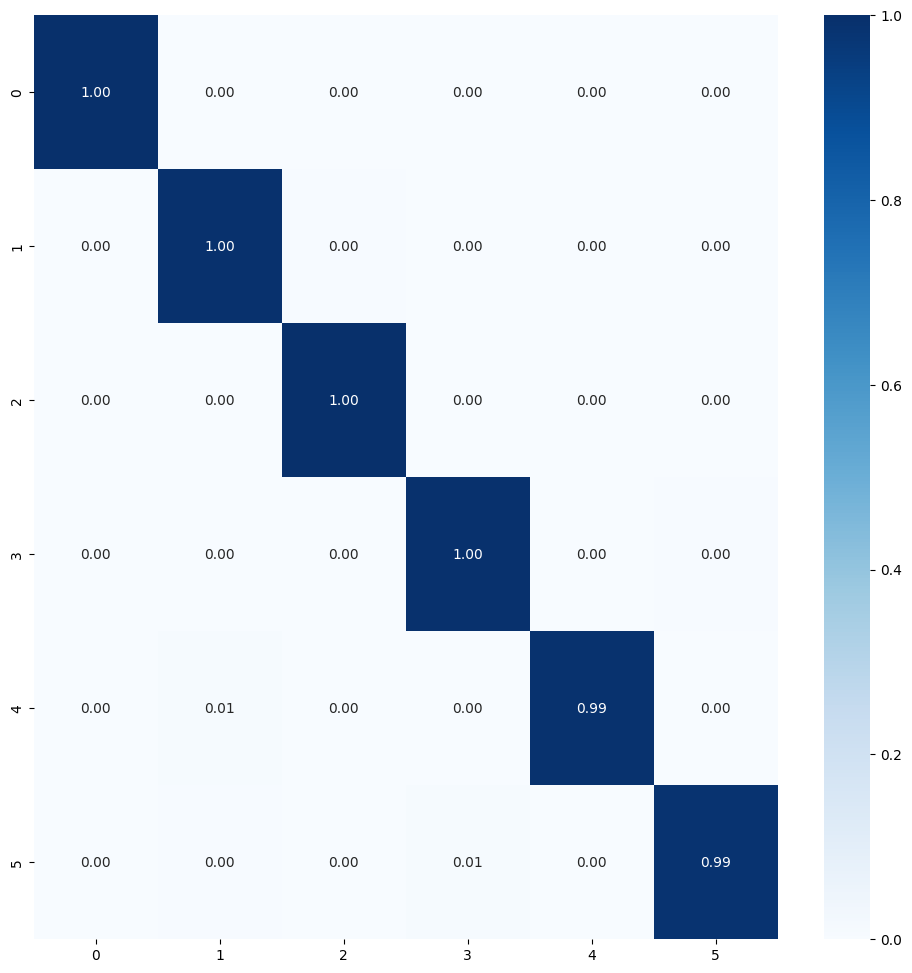


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 48s 190ms/step - loss: 0.0238 - accuracy: 0.9992 - val_loss: 0.0520 - val_accuracy: 0.9940 - lr: 1.0000e-04
Epoch 2/50
196/196 [==============================] - 33s 167ms/step - loss: 0.0191 - accuracy: 0.9987 - val_loss: 0.0547 - val_accuracy: 0.9926 - lr: 1.0000e-04
Epoch 3/50
196/196 [==============================] - 37s 186ms/step - loss: 0.0158 - accuracy: 0.9998 - val_loss: 0.0409 - val_accuracy: 0.9948 - lr: 1.0000e-04
Epoch 4/50
196/196 [==========================

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15006_4.pkl
197/197 [==============================] - 39s 192ms/step - loss: 0.0027 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0027193480636924505
43/43 [==============================] - 8s 182ms/step - loss: 0.0244 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.024405963718891144
43/43 [==============================] - 7s 140ms/step - loss: 0.0314 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.03140391781926155
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 225   0   0]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00  

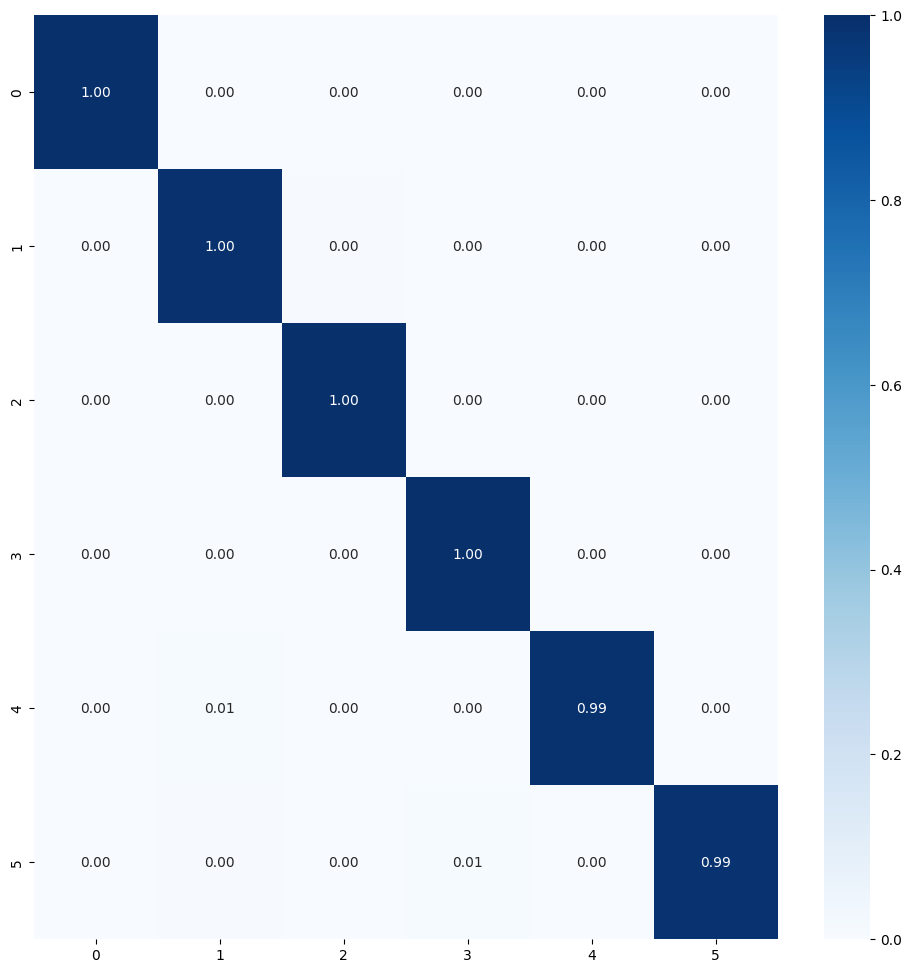


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 39s 173ms/step - loss: 0.0233 - accuracy: 0.9986 - val_loss: 0.0574 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 2/50
196/196 [==============================] - 34s 172ms/step - loss: 0.0180 - accuracy: 0.9998 - val_loss: 0.0431 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 3/50
196/196 [==============================] - 33s 164ms/step - loss: 0.0187 - accuracy: 0.9995 - val_loss: 0.0412 - val_accuracy: 0.9940 - lr: 1.0000e-04
Epoch 4/50
196/196 [==========================

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15006_5.pkl
197/197 [==============================] - 28s 140ms/step - loss: 0.0036 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0036156494170427322
43/43 [==============================] - 7s 129ms/step - loss: 0.0327 - accuracy: 0.9948
Validation Accuracy: 0.9948148131370544
Validation Log Loss: 0.032690051943063736
43/43 [==============================] - 7s 126ms/step - loss: 0.0280 - accuracy: 0.9963
Test Accuracy: 0.9962962865829468
Test Log Loss: 0.027975786477327347
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 225   0   0]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.0

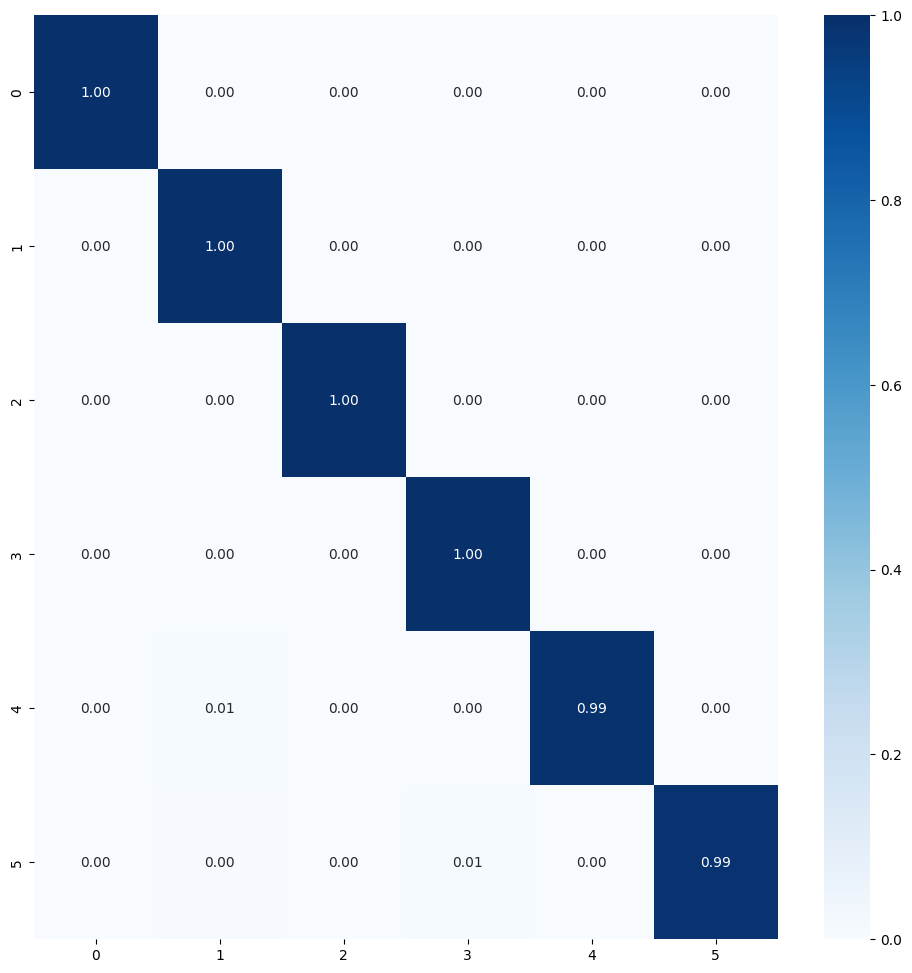


Best fold was 1 with val_accuracy: 0.9970
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9965773940086364

Test Metrics
test_acc_list: [0.995555579662323, 0.9948148131370544, 0.9948148131370544, 0.995555579662323, 0.9962962865829468]
Average Test Accuracy with 5-fold: 0.9954074144363403
test_loss_list: [0.027846306562423706, 0.039258040487766266, 0.030052388086915016, 0.03140391781926155, 0.027975786477327347]
Average Test Log Loss with 5-fold: 0.031307287886738776

Precision List: [0.9955847071347165, 0.994837583292207, 0.994837583292207, 0.995591464920146, 0.9963385887626556]
Average Precision List with 5-fold: 0.9954379854803864
Recall List: [0.9955555555555556, 0.9948148148148149, 0.9948148148148149, 0.9955555555555556, 0.9962962962962963]
Average Recall List with 5-fold: 0.9954074074074075
F1 Score List: [0.9955554569333644, 0.994814734289022, 0.994814734289022, 0.9955554456177222, 0.9962961682620647]
Average F1 Score List with 5-fold: 0.995407

In [21]:
%%time

num_classes = 6
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/7
name_save_model: MobileNet_tf_15007
Found 7350 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_25 - Trainable: True
dropout_50 - Trainable: True
dense_76 - Trainable: True
dropout_51 - Trainable: True
dense_77 - Trainable: True
Epoch 1/50
229/229 [==============================] - 73s 272ms/step - loss: 0.0084 - accuracy: 0.9997 - val_loss: 0.0578 - val_accuracy: 0.9917 - lr: 1.0000e-04
Epoch 2/50
229/229 [===

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15007_1.pkl
230/230 [==============================] - 37s 158ms/step - loss: 0.0019 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0018548497464507818
50/50 [==============================] - 9s 171ms/step - loss: 0.0384 - accuracy: 0.9937
Validation Accuracy: 0.9936507940292358
Validation Log Loss: 0.03835124522447586
50/50 [==============================] - 8s 145ms/step - loss: 0.0370 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.03704957664012909
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
      

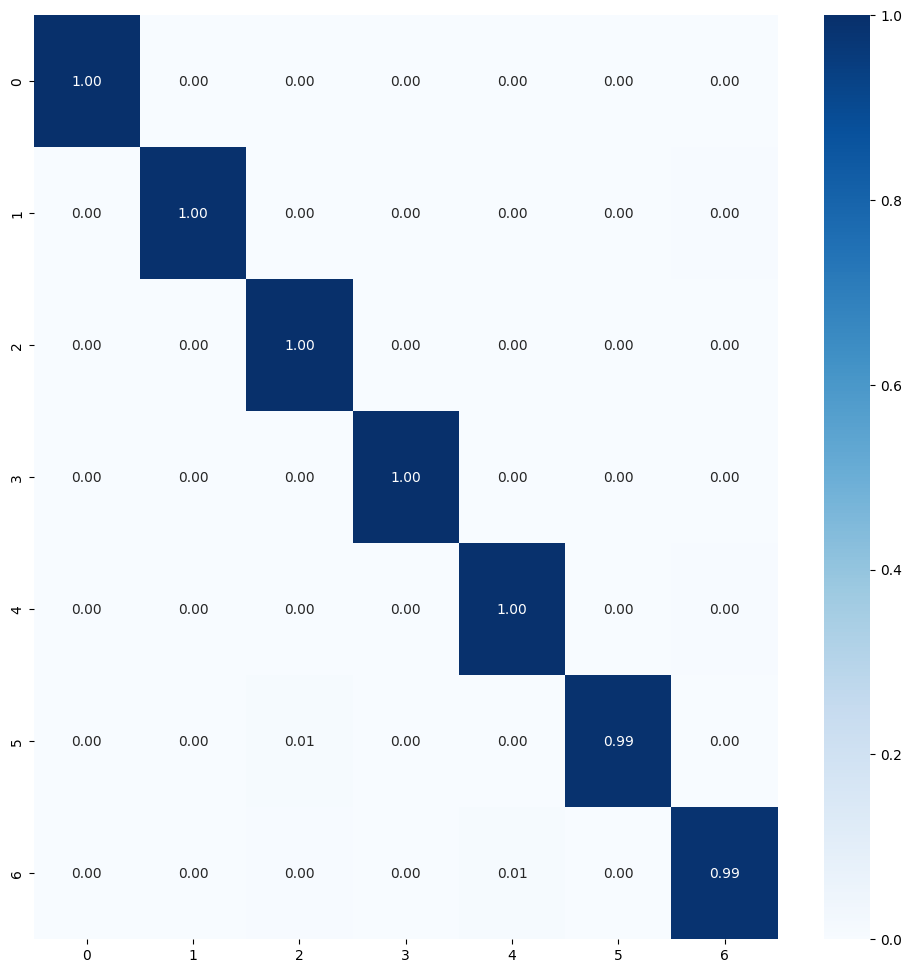


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_25 - Trainable: True
dropout_50 - Trainable: True
dense_76 - Trainable: True
dropout_51 - Trainable: True
dense_77 - Trainable: True
Epoch 1/50
229/229 [==============================] - 59s 215ms/step - loss: 0.0098 - accuracy: 0.9997 - val_loss: 0.1316 - val_accuracy: 0.9739 - lr: 1.0000e-04
Epoch 2/50
229/229 [==============================] - 51s 222ms/step - loss: 0.0099 - accuracy: 0.9993 - val_loss: 0.0468 - val_accuracy: 0.9949 - lr: 1.0000e-04
Epoch 3/50
229/229 [==============================] - 45s 198ms/step - loss: 0.0076 - accuracy: 1.0000 - val_loss: 0.0470 - val_accuracy: 0.9943 - lr: 1.0000e-04
Epoch 4/50
229/229 [==========================

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15007_2.pkl
230/230 [==============================] - 53s 229ms/step - loss: 0.0023 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0022630959283560514
50/50 [==============================] - 12s 221ms/step - loss: 0.0386 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.0386023223400116
50/50 [==============================] - 9s 176ms/step - loss: 0.0342 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.03423378989100456
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   1   0   0   0]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
       

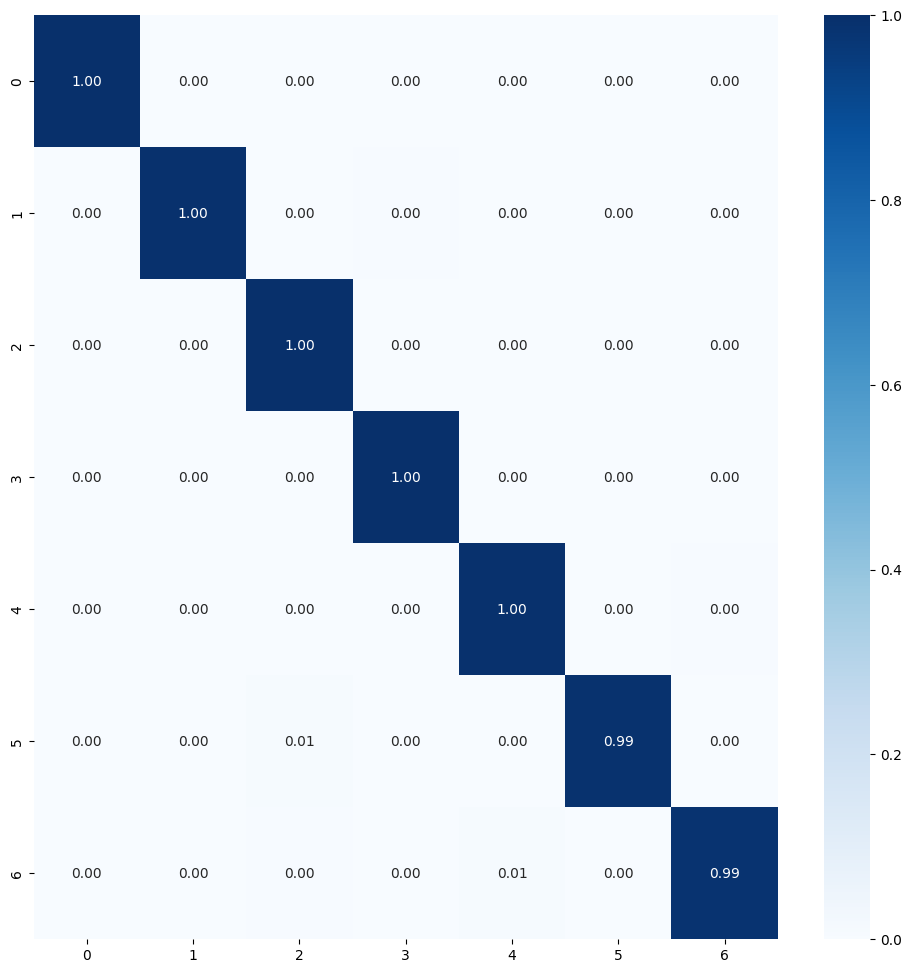


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_25 - Trainable: True
dropout_50 - Trainable: True
dense_76 - Trainable: True
dropout_51 - Trainable: True
dense_77 - Trainable: True
Epoch 1/50
229/229 [==============================] - 73s 251ms/step - loss: 0.0089 - accuracy: 0.9999 - val_loss: 0.0402 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 2/50
229/229 [==============================] - 50s 216ms/step - loss: 0.0066 - accuracy: 1.0000 - val_loss: 0.0515 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 3/50
229/229 [==============================] - 54s 233ms/step - loss: 0.0114 - accuracy: 0.9984 - val_loss: 0.0506 - val_accuracy: 0.9936 - lr: 1.0000e-04
Epoch 4/50
229/229 [==========================

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15007_3.pkl
230/230 [==============================] - 29s 128ms/step - loss: 0.0018 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0017566066235303879
50/50 [==============================] - 9s 176ms/step - loss: 0.0342 - accuracy: 0.9943
Validation Accuracy: 0.9942857027053833
Validation Log Loss: 0.03417909890413284
50/50 [==============================] - 15s 289ms/step - loss: 0.0321 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.03210718184709549
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
     

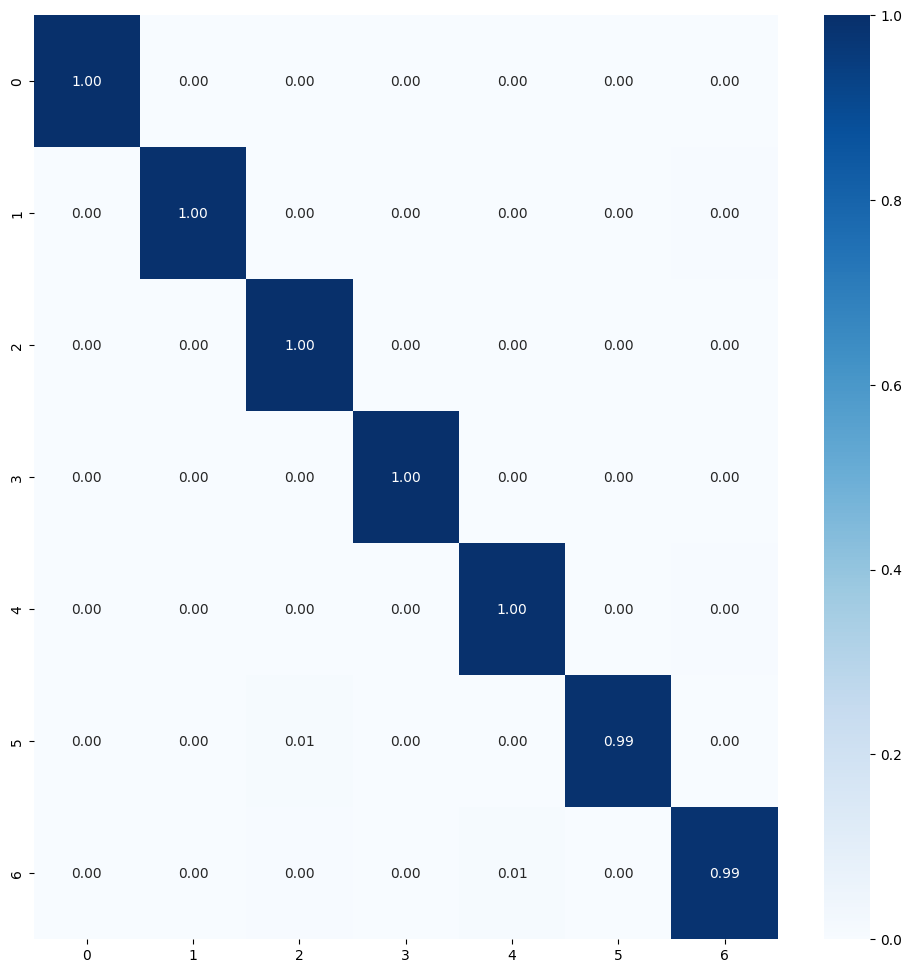


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_25 - Trainable: True
dropout_50 - Trainable: True
dense_76 - Trainable: True
dropout_51 - Trainable: True
dense_77 - Trainable: True
Epoch 1/50
229/229 [==============================] - 66s 244ms/step - loss: 0.0087 - accuracy: 0.9999 - val_loss: 0.0490 - val_accuracy: 0.9930 - lr: 1.0000e-04
Epoch 2/50
229/229 [==============================] - 53s 233ms/step - loss: 0.0064 - accuracy: 1.0000 - val_loss: 0.0432 - val_accuracy: 0.9943 - lr: 1.0000e-04
Epoch 3/50
229/229 [==============================] - 51s 219ms/step - loss: 0.0085 - accuracy: 0.9989 - val_loss: 0.1263 - val_accuracy: 0.9662 - lr: 1.0000e-04
Epoch 4/50
229/229 [==========================

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [22]:
%%time

num_classes = 7
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/8
name_save_model: MobileNet_tf_15008
Found 8400 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_30 - Trainable: True
dropout_60 - Trainable: True
dense_91 - Trainable: True
dropout_61 - Trainable: True
dense_92 - Trainable: True
Epoch 1/50
262/262 [==============================] - 79s 238ms/step - loss: 0.0085 - accuracy: 0.9995 - val_loss: 0.0379 - val_accuracy: 0.9939 - lr: 1.0000e-04
Epoch 2/50
262

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 42/50
262/262 [==============================] - 61s 232ms/step - loss: 0.0019 - accuracy: 1.0000 - val_loss: 0.0338 - val_accuracy: 0.9950 - lr: 4.0000e-06
Epoch 43/50
262/262 [==============================] - 62s 236ms/step - loss: 0.0019 - accuracy: 1.0000 - val_loss: 0.0332 - val_accuracy: 0.9950 - lr: 4.0000e-06
Epoch 44/50
262/262 [==============================] - 57s 214ms/step - loss: 0.0018 - accuracy: 1.0000 - val_loss: 0.0314 - val_accuracy: 0.9950 - lr: 4.0000e-06
Epoch 47/50
262/262 [==============================] - 74s 279ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.0314 - val_accuracy: 0.9950 - lr: 4.0000e-06
Epoch 48/50
262/262 [==============================] - 52s 192ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.0310 - val_accuracy: 0.9950 - lr: 1.0000e-06
Epoch 49/50
262/262 [==============================] - 59s 226ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.0314 - val_accuracy: 0.9950 - lr: 1.0000e-06
Epoch 50/50
262/262 [=

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_15008_1.pkl
263/263 [==============================] - 51s 192ms/step - loss: 0.0015 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0014992783544585109
57/57 [==============================] - 11s 177ms/step - loss: 0.0313 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.03131559118628502
57/57 [==============================] - 10s 173ms/step - loss: 0.0312 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.031193792819976807
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   3   0 221]]
True labe

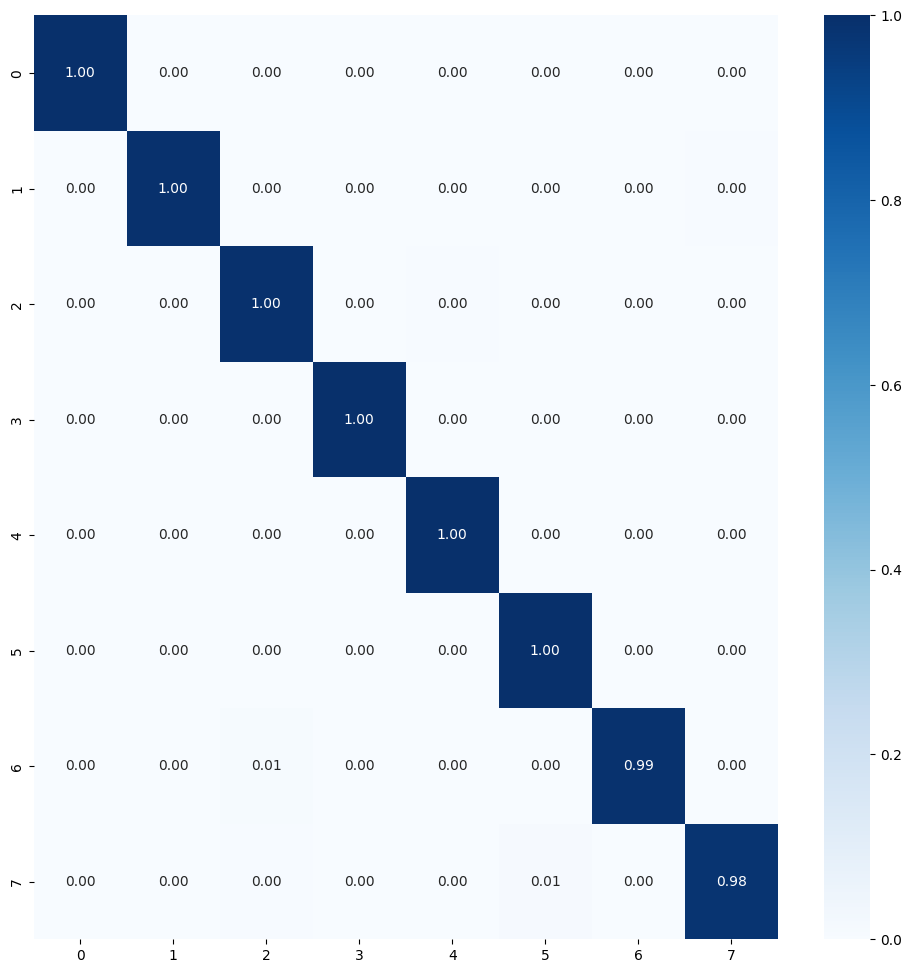


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_30 - Trainable: True
dropout_60 - Trainable: True
dense_91 - Trainable: True
dropout_61 - Trainable: True
dense_92 - Trainable: True
Epoch 1/50
262/262 [==============================] - 65s 208ms/step - loss: 0.0091 - accuracy: 0.9995 - val_loss: 0.0418 - val_accuracy: 0.9939 - lr: 1.0000e-04
Epoch 2/50
262/262 [==============================] - 62s 237ms/step - loss: 0.0082 - accuracy: 0.9999 - val_loss: 0.0429 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 3/50
262/262 [==============================] - 55s 211ms/step - loss: 0.0086 - accuracy: 0.9995 - val_loss: 0.0355 - val_accuracy: 0.9955 - lr: 1.0000e-04
Epoch 4/50
262/262 [==========================

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 9/50
262/262 [==============================] - 52s 196ms/step - loss: 0.0078 - accuracy: 0.9999 - val_loss: 0.0506 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 10/50
262/262 [==============================] - 59s 226ms/step - loss: 0.0075 - accuracy: 0.9998 - val_loss: 0.0436 - val_accuracy: 0.9950 - lr: 1.0000e-04
Epoch 11/50
262/262 [==============================] - 57s 216ms/step - loss: 0.0118 - accuracy: 0.9989 - val_loss: 0.0447 - val_accuracy: 0.9933 - lr: 1.0000e-04
Epoch 12/50
262/262 [==============================] - 59s 226ms/step - loss: 0.0073 - accuracy: 0.9999 - val_loss: 0.0436 - val_accuracy: 0.9950 - lr: 1.0000e-04
Epoch 13/50
262/262 [==============================] - 61s 228ms/step - loss: 0.0061 - accuracy: 1.0000 - val_loss: 0.0414 - val_accuracy: 0.9950 - lr: 1.0000e-04
Epoch 14/50
262/262 [==============================] - 55s 208ms/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.0397 - val_accuracy: 0.9950 - lr: 1.0000e-04
Epoch 15/50
262/262 [==

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



262/262 [==============================] - 49s 186ms/step - loss: 0.0054 - accuracy: 1.0000 - val_loss: 0.0429 - val_accuracy: 0.9955 - lr: 2.0000e-05
Epoch 17/50
262/262 [==============================] - 50s 190ms/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.0422 - val_accuracy: 0.9955 - lr: 2.0000e-05
Epoch 18/50
262/262 [==============================] - 56s 207ms/step - loss: 0.0049 - accuracy: 1.0000 - val_loss: 0.0412 - val_accuracy: 0.9955 - lr: 2.0000e-05
Epoch 19/50
262/262 [==============================] - 54s 206ms/step - loss: 0.0046 - accuracy: 1.0000 - val_loss: 0.0405 - val_accuracy: 0.9955 - lr: 2.0000e-05
Epoch 20/50
262/262 [==============================] - 49s 186ms/step - loss: 0.0044 - accuracy: 1.0000 - val_loss: 0.0374 - val_accuracy: 0.9955 - lr: 2.0000e-05
Epoch 21/50
262/262 [==============================] - 47s 175ms/step - loss: 0.0041 - accuracy: 1.0000 - val_loss: 0.0370 - val_accuracy: 0.9950 - lr: 2.0000e-05
Epoch 22/50
262/262 [=============

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [23]:
%%time

num_classes = 8
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

In [24]:
%%time

num_classes = 9
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/9
name_save_model: MobileNet_tf_15009
Found 9450 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_38 - Trainable: True
dropout_76 - Trainable: True
dense_115 - Trainable: True
dropout_77 - Trainable: True
dense_116 - Trainable: True
Epoch 1/50
295/295 [==============================] - 75s 211ms/step - loss: 0.0078 - accuracy: 0.9995 - val_loss: 0.0262 - val_accuracy: 0.9950 - lr: 1.0000e-04


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



295/295 [==============================] - 59s 199ms/step - loss: 0.0073 - accuracy: 0.9998 - val_loss: 0.0362 - val_accuracy: 0.9945 - lr: 1.0000e-04
Epoch 14/50
295/295 [==============================] - 56s 188ms/step - loss: 0.0060 - accuracy: 1.0000 - val_loss: 0.0389 - val_accuracy: 0.9945 - lr: 1.0000e-04
Epoch 15/50
295/295 [==============================] - 57s 193ms/step - loss: 0.0054 - accuracy: 1.0000 - val_loss: 0.0400 - val_accuracy: 0.9940 - lr: 2.0000e-05
Epoch 16/50
295/295 [==============================] - 56s 186ms/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.0383 - val_accuracy: 0.9940 - lr: 2.0000e-05
Epoch 17/50
295/295 [==============================] - 46s 153ms/step - loss: 0.0049 - accuracy: 1.0000 - val_loss: 0.0373 - val_accuracy: 0.9940 - lr: 2.0000e-05
Epoch 18/50
295/295 [==============================] - 57s 193ms/step - loss: 0.0047 - accuracy: 1.0000 - val_loss: 0.0361 - val_accuracy: 0.9940 - lr: 2.0000e-05
Epoch 19/50
295/295 [=============

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



295/295 [==============================] - 57s 188ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0293 - val_accuracy: 0.9965 - lr: 4.0000e-06
Epoch 37/50
295/295 [==============================] - 53s 180ms/step - loss: 0.0029 - accuracy: 1.0000 - val_loss: 0.0291 - val_accuracy: 0.9965 - lr: 4.0000e-06
Epoch 38/50
295/295 [==============================] - 54s 181ms/step - loss: 0.0028 - accuracy: 1.0000 - val_loss: 0.0288 - val_accuracy: 0.9965 - lr: 4.0000e-06
Epoch 39/50
295/295 [==============================] - 55s 183ms/step - loss: 0.0028 - accuracy: 1.0000 - val_loss: 0.0294 - val_accuracy: 0.9960 - lr: 4.0000e-06
Epoch 40/50
295/295 [==============================] - 53s 178ms/step - loss: 0.0027 - accuracy: 1.0000 - val_loss: 0.0291 - val_accuracy: 0.9965 - lr: 4.0000e-06
Epoch 41/50
295/295 [==============================] - 58s 195ms/step - loss: 0.0026 - accuracy: 1.0000 - val_loss: 0.0285 - val_accuracy: 0.9965 - lr: 4.0000e-06
Epoch 42/50
295/295 [=============

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Familias de malware copiadas
source2: /notebooks/train3/all_malware/10
name_save_model: MobileNet_tf_150010
Found 10500 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 89s 235ms/step - loss: 0.0422 - accuracy: 0.9977 - val_loss: 0.4457 - val_accuracy: 0.9192 - lr: 1.00

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 41/50
328/328 [==============================] - 57s 174ms/step - loss: 0.0124 - accuracy: 0.9995 - val_loss: 0.1834 - val_accuracy: 0.9719 - lr: 2.0000e-05
Epoch 42/50
328/328 [==============================] - 57s 175ms/step - loss: 0.0116 - accuracy: 0.9998 - val_loss: 0.1851 - val_accuracy: 0.9705 - lr: 2.0000e-05
Epoch 43/50
328/328 [==============================] - 65s 196ms/step - loss: 0.0112 - accuracy: 0.9999 - val_loss: 0.1810 - val_accuracy: 0.9683 - lr: 2.0000e-05
Epoch 44/50
328/328 [==============================] - 67s 203ms/step - loss: 0.0109 - accuracy: 0.9999 - val_loss: 0.1868 - val_accuracy: 0.9710 - lr: 2.0000e-05
Epoch 45/50
328/328 [==============================] - 63s 193ms/step - loss: 0.0105 - accuracy: 0.9998 - val_loss: 0.1902 - val_accuracy: 0.9710 - lr: 2.0000e-05
Epoch 46/50
328/328 [==============================] - 66s 201ms/step - loss: 0.0103 - accuracy: 0.9999 - val_loss: 0.1856 - val_accuracy: 0.9719 - lr: 4.0000e-06
Epoch 47/50
328/328 [=

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150010_1.pkl
329/329 [==============================] - 57s 172ms/step - loss: 0.0092 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00917107705026865
71/71 [==============================] - 13s 164ms/step - loss: 0.1864 - accuracy: 0.9702
Validation Accuracy: 0.9702222347259521
Validation Log Loss: 0.1864427924156189
71/71 [==============================] - 12s 155ms/step - loss: 0.1716 - accuracy: 0.9729
Test Accuracy: 0.9728888869285583
Test Log Loss: 0.17162162065505981
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 225   0   0   0   0]
 [  

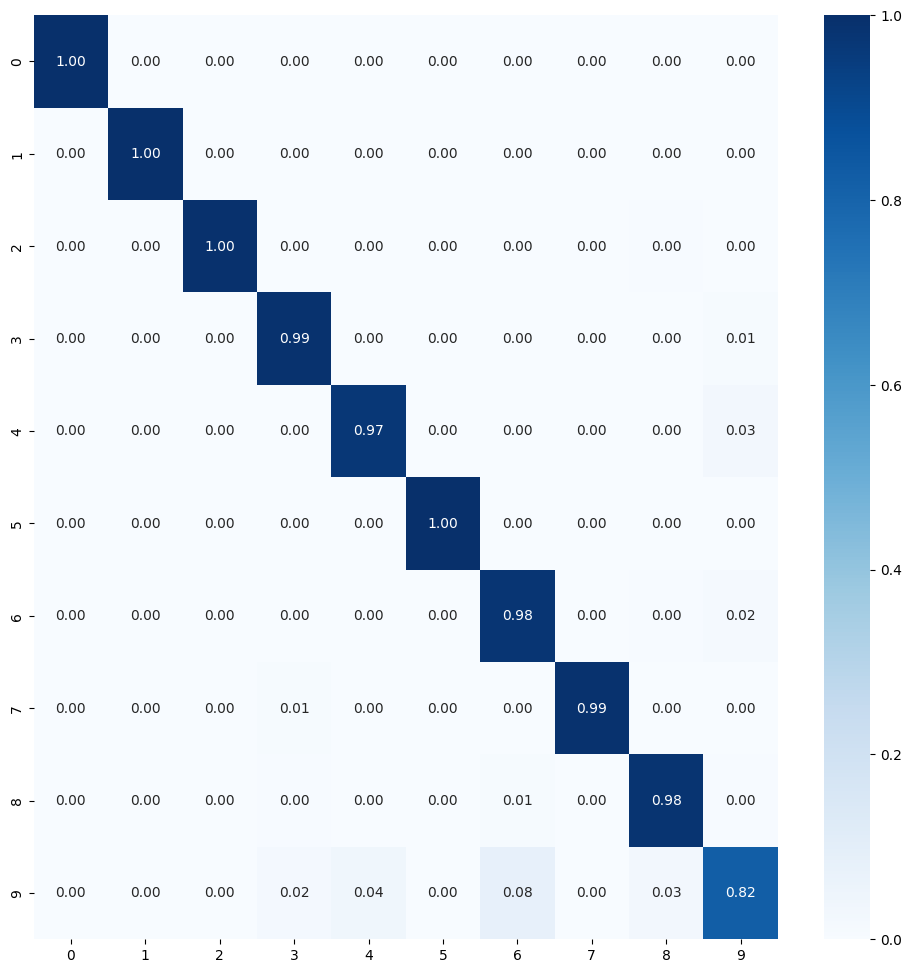


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 86s 221ms/step - loss: 0.0428 - accuracy: 0.9969 - val_loss: 0.2032 - val_accuracy: 0.9688 - lr: 1.0000e-04
Epoch 2/50
328/328 [==============================] - 58s 174ms/step - loss: 0.0373 - accuracy: 0.9984 - val_loss: 0.1959 - val_accuracy: 0.9719 - lr: 1.0000e-04
Epoch 3/50
328/328 [==============================] - 65s 197ms/step - loss: 0.0355 - accuracy: 0.9980 - val_loss: 0.1795 - val_accuracy: 0.9705 - lr: 1.0000e-04
Epoch 4/50
328/328 [==============================] -

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150010_2.pkl
329/329 [==============================] - 52s 156ms/step - loss: 0.0112 - accuracy: 0.9999
Train Accuracy: 0.9999047517776489
Train Log Loss: 0.011164460331201553
71/71 [==============================] - 11s 136ms/step - loss: 0.1760 - accuracy: 0.9724
Validation Accuracy: 0.9724444150924683
Validation Log Loss: 0.17602303624153137
71/71 [==============================] - 12s 166ms/step - loss: 0.1593 - accuracy: 0.9760
Test Accuracy: 0.9760000109672546
Test Log Loss: 0.15928027033805847
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 224   0   0   0   0   0   1]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 225   0 

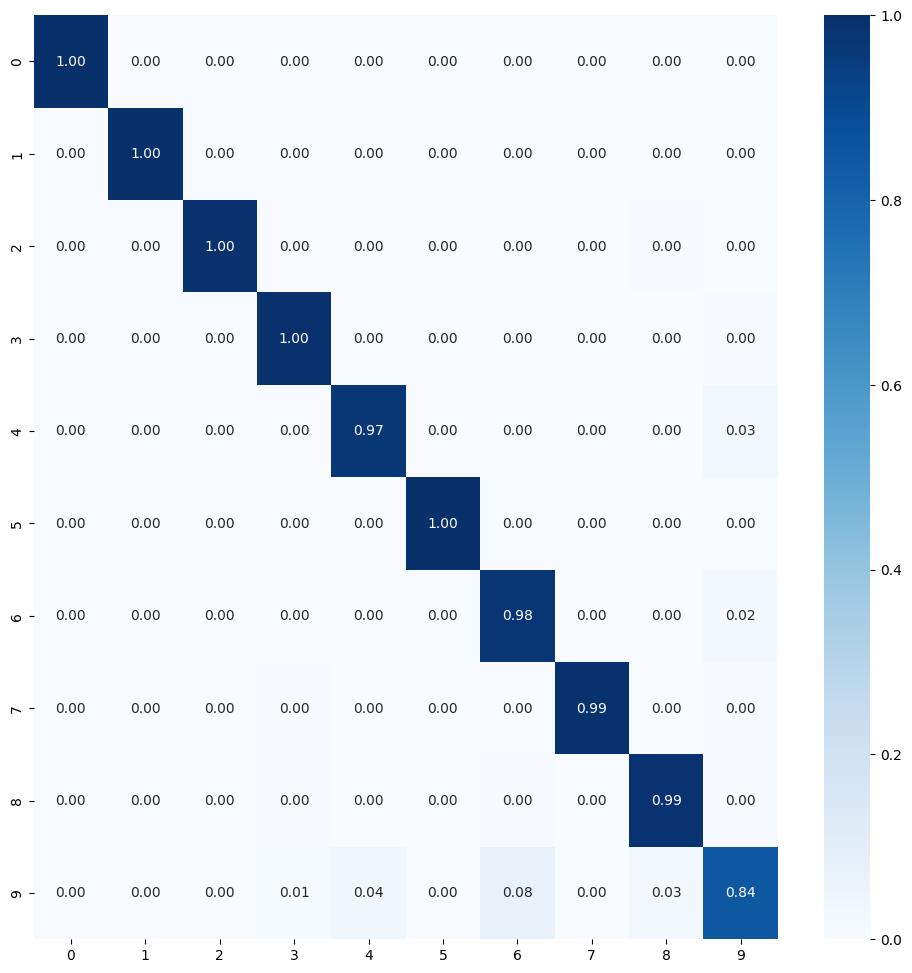


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 77s 198ms/step - loss: 0.0411 - accuracy: 0.9981 - val_loss: 0.2564 - val_accuracy: 0.9652 - lr: 1.0000e-04
Epoch 2/50
328/328 [==============================] - 72s 217ms/step - loss: 0.0416 - accuracy: 0.9972 - val_loss: 0.3566 - val_accuracy: 0.9375 - lr: 1.0000e-04
Epoch 3/50
328/328 [==============================] - 58s 176ms/step - loss: 0.0414 - accuracy: 0.9964 - val_loss: 0.2284 - val_accuracy: 0.9696 - lr: 1.0000e-04
Epoch 4/50
328/328 [==============================] -

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150010_3.pkl
329/329 [==============================] - 40s 120ms/step - loss: 0.0090 - accuracy: 0.9999
Train Accuracy: 0.9999047517776489
Train Log Loss: 0.008998247794806957
71/71 [==============================] - 10s 135ms/step - loss: 0.1788 - accuracy: 0.9702
Validation Accuracy: 0.9702222347259521
Validation Log Loss: 0.1787552535533905
71/71 [==============================] - 12s 170ms/step - loss: 0.1570 - accuracy: 0.9756
Test Accuracy: 0.9755555391311646
Test Log Loss: 0.15701539814472198
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 225   0  

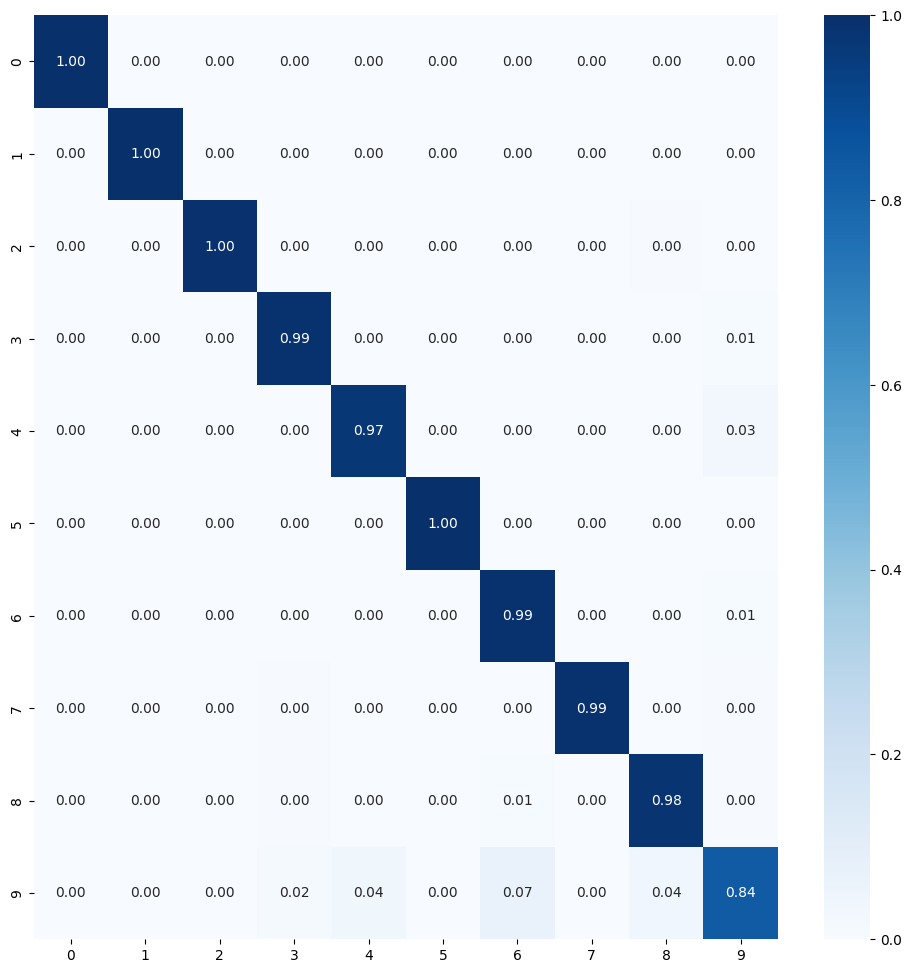


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 75s 204ms/step - loss: 0.0432 - accuracy: 0.9972 - val_loss: 0.3363 - val_accuracy: 0.9567 - lr: 1.0000e-04
Epoch 2/50
328/328 [==============================] - 65s 198ms/step - loss: 0.0400 - accuracy: 0.9981 - val_loss: 0.2164 - val_accuracy: 0.9652 - lr: 1.0000e-04
Epoch 3/50
328/328 [==============================] - 62s 189ms/step - loss: 0.0410 - accuracy: 0.9973 - val_loss: 0.1860 - val_accuracy: 0.9665 - lr: 1.0000e-04
Epoch 4/50
328/328 [==============================] -

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150010_4.pkl
329/329 [==============================] - 51s 153ms/step - loss: 0.0100 - accuracy: 0.9999
Train Accuracy: 0.9999047517776489
Train Log Loss: 0.010000200942158699
71/71 [==============================] - 12s 164ms/step - loss: 0.1890 - accuracy: 0.9711
Validation Accuracy: 0.9711111187934875
Validation Log Loss: 0.18898272514343262
71/71 [==============================] - 13s 170ms/step - loss: 0.1596 - accuracy: 0.9733
Test Accuracy: 0.9733333587646484
Test Log Loss: 0.15958045423030853
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 224   0   0   0   0   0   1]
 [  0   0   0   0 218   0   0   0   0   7]
 [  0   0   0   0   0 224   0 

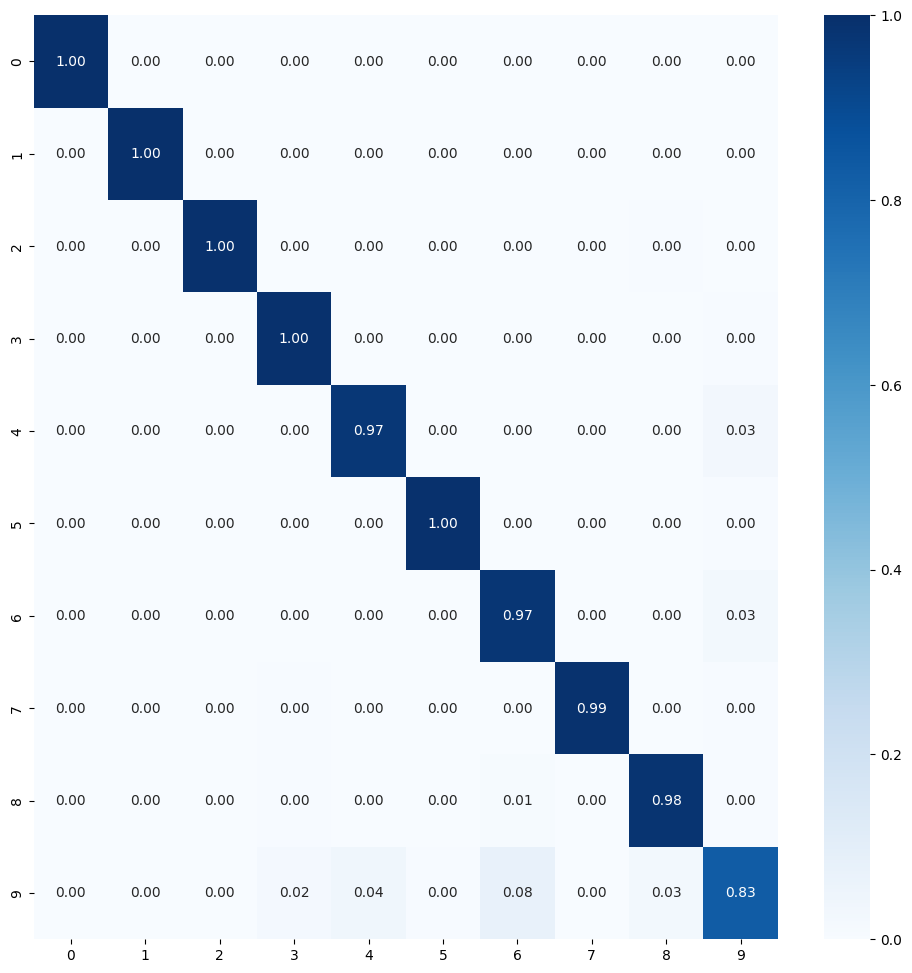


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 79s 202ms/step - loss: 0.0412 - accuracy: 0.9976 - val_loss: 0.2690 - val_accuracy: 0.9554 - lr: 1.0000e-04
Epoch 2/50
328/328 [==============================] - 62s 189ms/step - loss: 0.0402 - accuracy: 0.9976 - val_loss: 0.1858 - val_accuracy: 0.9714 - lr: 1.0000e-04
Epoch 3/50
328/328 [==============================] - 59s 179ms/step - loss: 0.0362 - accuracy: 0.9983 - val_loss: 0.2091 - val_accuracy: 0.9665 - lr: 1.0000e-04
Epoch 4/50
328/328 [==============================] -

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150010_5.pkl
329/329 [==============================] - 55s 162ms/step - loss: 0.0125 - accuracy: 0.9999
Train Accuracy: 0.9999047517776489
Train Log Loss: 0.012522917240858078
71/71 [==============================] - 12s 164ms/step - loss: 0.1951 - accuracy: 0.9693
Validation Accuracy: 0.9693333506584167
Validation Log Loss: 0.1951359659433365
71/71 [==============================] - 13s 172ms/step - loss: 0.1689 - accuracy: 0.9724
Test Accuracy: 0.9724444150924683
Test Log Loss: 0.16892988979816437
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 222   0   0   0   0   0   3]
 [  0   0   0   0 217   0   0   0   0   8]
 [  0   0   0   0   0 224   0  

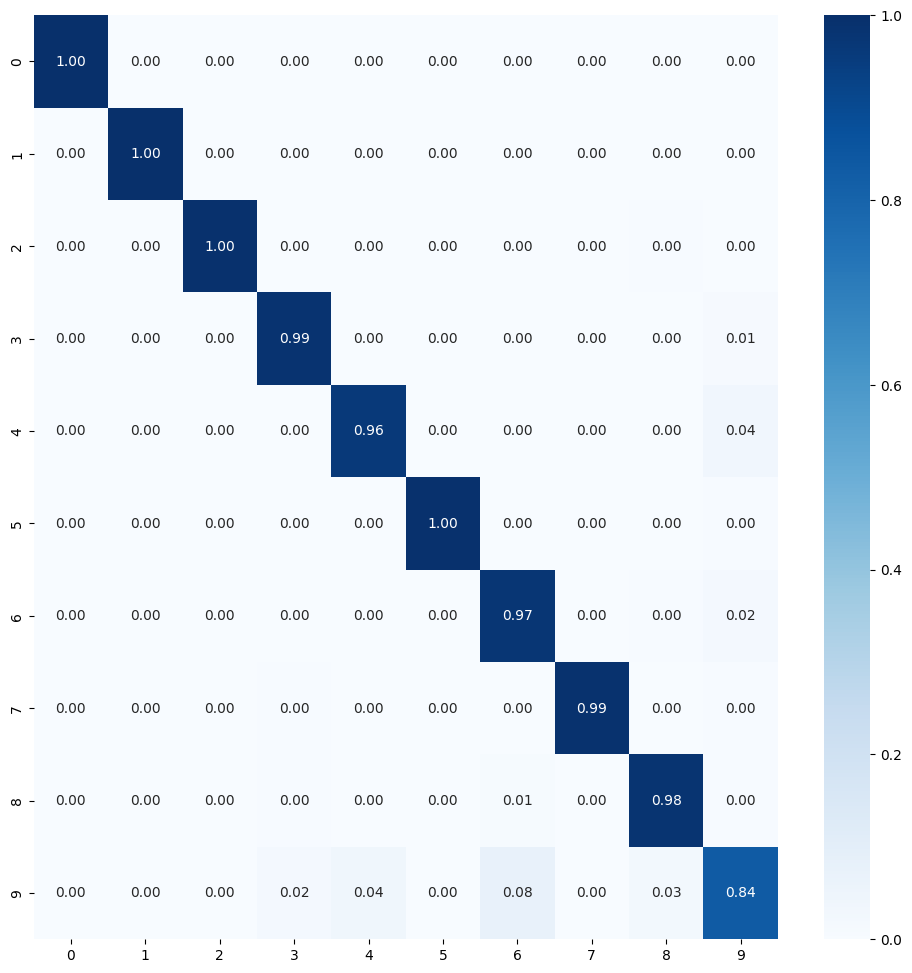


Best fold was 1 with val_accuracy: 0.9741
Average training accuracy in 5-fold: 0.999980890750885
Average validation precision in 5-fold: 0.9731250047683716

Test Metrics
test_acc_list: [0.9728888869285583, 0.9760000109672546, 0.9755555391311646, 0.9733333587646484, 0.9724444150924683]
Average Test Accuracy with 5-fold: 0.9740444421768188
test_loss_list: [0.17162162065505981, 0.15928027033805847, 0.15701539814472198, 0.15958045423030853, 0.16892988979816437]
Average Test Log Loss with 5-fold: 0.16328552663326262

Precision List: [0.9729101265238294, 0.9759224970754558, 0.9755655701166516, 0.9731737927667607, 0.9723055435357694]
Average Precision List with 5-fold: 0.9739755060036934
Recall List: [0.9728888888888891, 0.976, 0.9755555555555556, 0.9733333333333334, 0.9724444444444444]
Average Recall List with 5-fold: 0.9740444444444444
F1 Score List: [0.9724256577589834, 0.9756741865250002, 0.9751428391804733, 0.9729438639354345, 0.9721303898242597]
Average F1 Score List with 5-fold: 0.973

In [25]:
%%time

num_classes = 10
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/11
name_save_model: MobileNet_tf_150011
Found 11550 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 93s 204ms/step - loss: 0.0667 - accuracy: 0.9907 - val_loss: 0.3057 - val_accuracy: 

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150011_1.pkl
361/361 [==============================] - 64s 177ms/step - loss: 0.0151 - accuracy: 0.9986
Train Accuracy: 0.9986147284507751
Train Log Loss: 0.015092477202415466
78/78 [==============================] - 12s 145ms/step - loss: 0.3550 - accuracy: 0.9491
Validation Accuracy: 0.9490908980369568
Validation Log Loss: 0.35502150654792786
78/78 [==============================] - 12s 148ms/step - loss: 0.2783 - accuracy: 0.9556
Test Accuracy: 0.9555555582046509
Test Log Loss: 0.2782593369483948
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   0   1   0   0   1]
 [  0   0   0   0 204   8   0   0   0   0  1

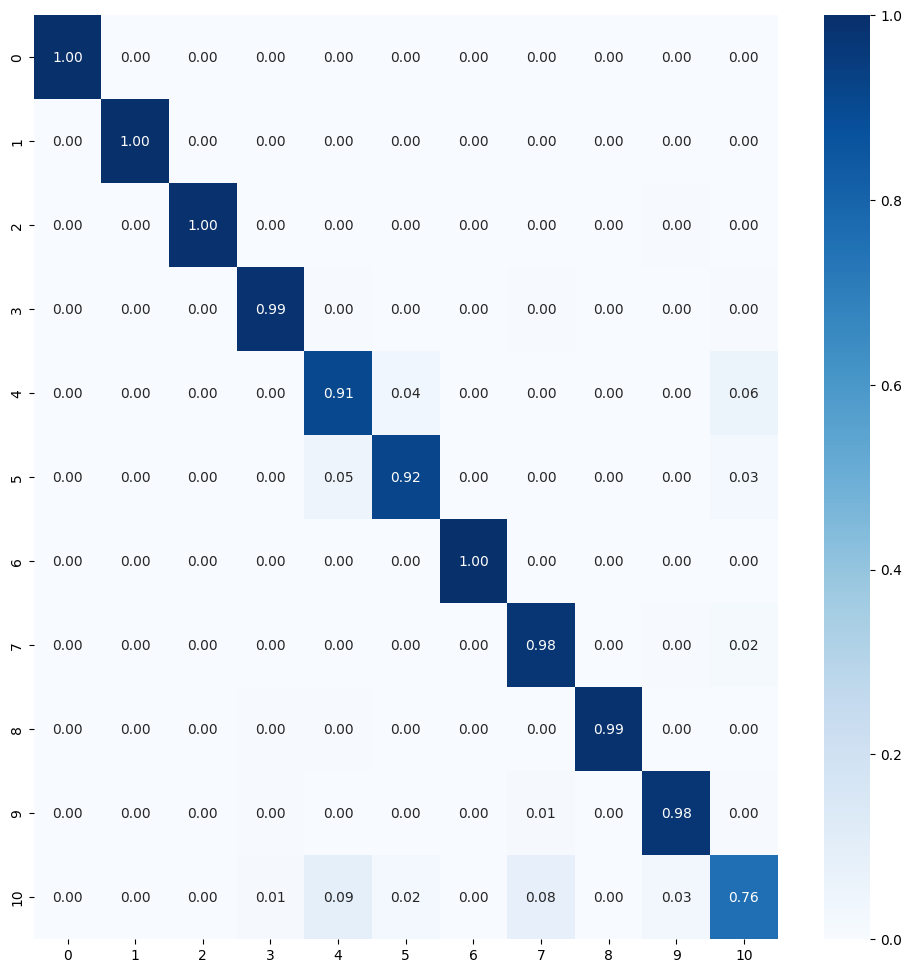


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 87s 209ms/step - loss: 0.0681 - accuracy: 0.9927 - val_loss: 0.2918 - val_accuracy: 0.9440 - lr: 1.0000e-04
Epoch 2/50
360/360 [==============================] - 64s 179ms/step - loss: 0.0658 - accuracy: 0.9918 - val_loss: 0.3165 - val_accuracy: 0.9334 - lr: 1.0000e-04
Epoch 3/50
360/360 [==============================] - 78s 215ms/step - loss: 0.0660 - accuracy: 0.9918 - val_loss: 0.2871 - val_accuracy: 0.9428 - lr: 1.0000e-04
Epoch 4/50
360/360 [=========================

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150011_2.pkl
361/361 [==============================] - 57s 157ms/step - loss: 0.0207 - accuracy: 0.9984
Train Accuracy: 0.9984415769577026
Train Log Loss: 0.020728249102830887
78/78 [==============================] - 11s 138ms/step - loss: 0.3582 - accuracy: 0.9487
Validation Accuracy: 0.9486868977546692
Validation Log Loss: 0.35824450850486755
78/78 [==============================] - 12s 152ms/step - loss: 0.2910 - accuracy: 0.9547
Test Accuracy: 0.9547474980354309
Test Log Loss: 0.2910386621952057
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   0   1   0   0   1]
 [  0   0   0   0 198  11   0   0   0   0  1

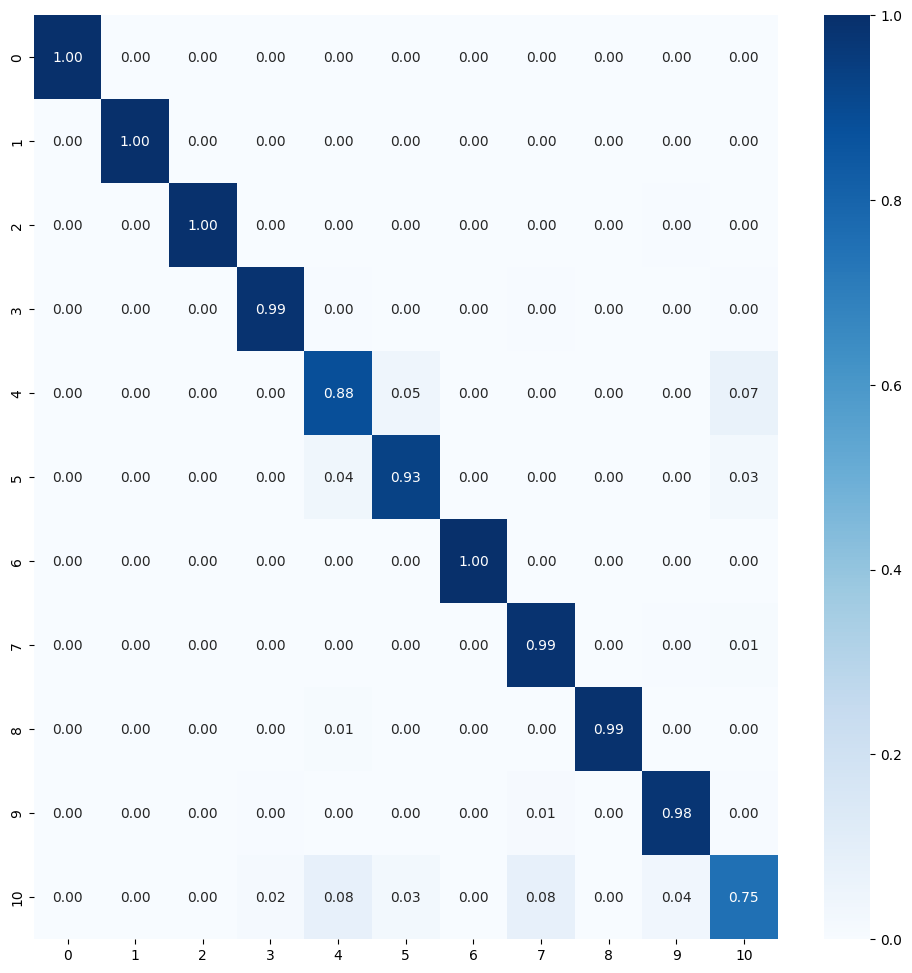


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 78s 191ms/step - loss: 0.0679 - accuracy: 0.9917 - val_loss: 0.3144 - val_accuracy: 0.9464 - lr: 1.0000e-04
Epoch 2/50
360/360 [==============================] - 68s 188ms/step - loss: 0.0646 - accuracy: 0.9916 - val_loss: 0.3106 - val_accuracy: 0.9497 - lr: 1.0000e-04
Epoch 3/50
360/360 [==============================] - 68s 184ms/step - loss: 0.0607 - accuracy: 0.9930 - val_loss: 0.2995 - val_accuracy: 0.9452 - lr: 1.0000e-04
Epoch 4/50
360/360 [=========================

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150011_3.pkl
361/361 [==============================] - 57s 157ms/step - loss: 0.0169 - accuracy: 0.9984
Train Accuracy: 0.9984415769577026
Train Log Loss: 0.01693369261920452
78/78 [==============================] - 12s 150ms/step - loss: 0.3376 - accuracy: 0.9507
Validation Accuracy: 0.9507070779800415
Validation Log Loss: 0.3375770151615143
78/78 [==============================] - 12s 156ms/step - loss: 0.2787 - accuracy: 0.9556
Test Accuracy: 0.9555555582046509
Test Log Loss: 0.27866873145103455
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   0   0   0   1]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   0   1   0   0   1]
 [  0   0   0   0 202   9   0   0   0   0  14

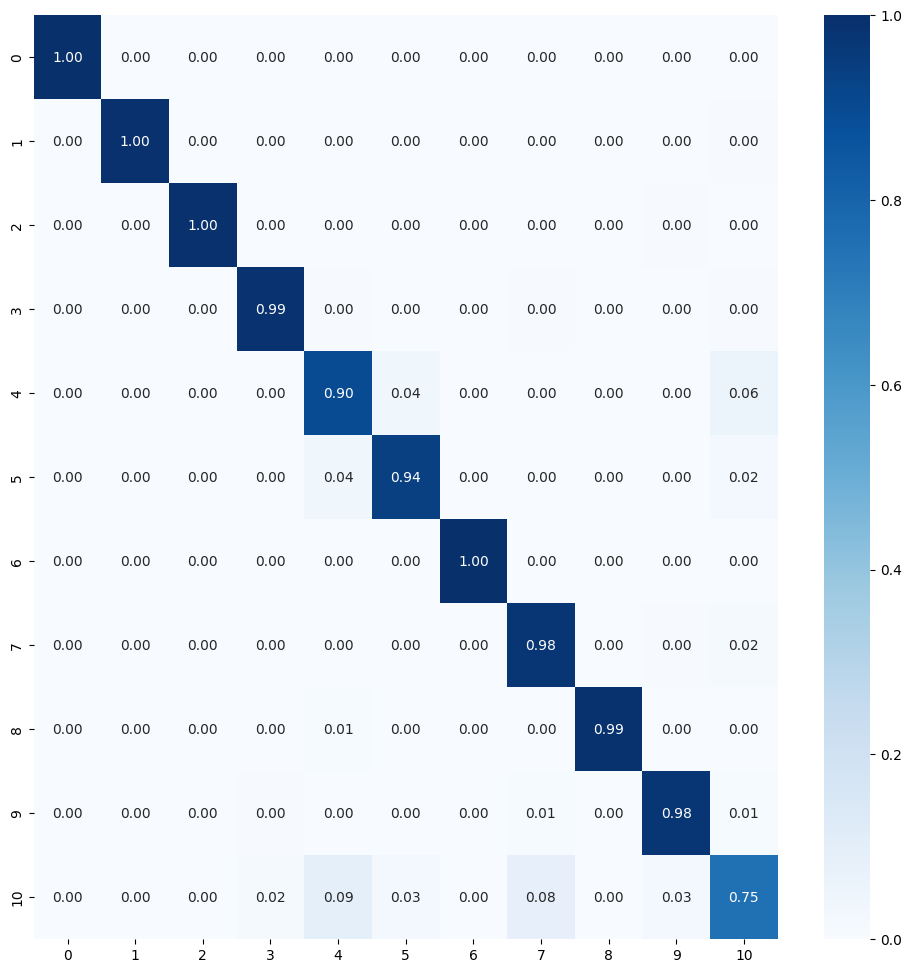


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 82s 199ms/step - loss: 0.0694 - accuracy: 0.9919 - val_loss: 0.2858 - val_accuracy: 0.9440 - lr: 1.0000e-04
Epoch 2/50
360/360 [==============================] - 68s 186ms/step - loss: 0.0631 - accuracy: 0.9923 - val_loss: 0.3698 - val_accuracy: 0.9399 - lr: 1.0000e-04
Epoch 3/50
360/360 [==============================] - 56s 155ms/step - loss: 0.0640 - accuracy: 0.9921 - val_loss: 0.3033 - val_accuracy: 0.9412 - lr: 1.0000e-04
Epoch 4/50
360/360 [=========================

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150011_4.pkl
361/361 [==============================] - 52s 142ms/step - loss: 0.0228 - accuracy: 0.9984
Train Accuracy: 0.9984415769577026
Train Log Loss: 0.02278895303606987
78/78 [==============================] - 11s 132ms/step - loss: 0.3412 - accuracy: 0.9491
Validation Accuracy: 0.9490908980369568
Validation Log Loss: 0.34120774269104004
78/78 [==============================] - 12s 150ms/step - loss: 0.2945 - accuracy: 0.9511
Test Accuracy: 0.9511111378669739
Test Log Loss: 0.2945112884044647
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 220   1   0   1   1   0   0   2]
 [  0   0   0   0 198   9   0   0   0   0  18

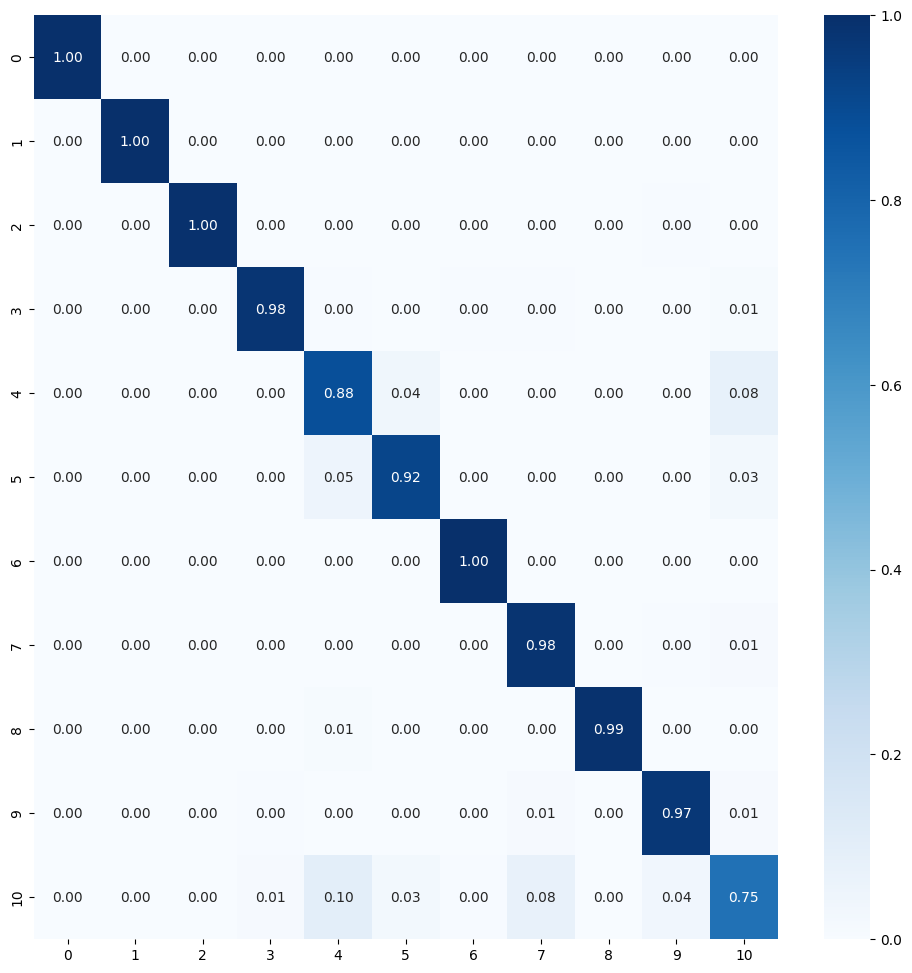


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 73s 171ms/step - loss: 0.0682 - accuracy: 0.9921 - val_loss: 0.3509 - val_accuracy: 0.9338 - lr: 1.0000e-04
Epoch 2/50
360/360 [==============================] - 41s 114ms/step - loss: 0.0658 - accuracy: 0.9917 - val_loss: 0.3368 - val_accuracy: 0.9432 - lr: 1.0000e-04
Epoch 3/50
360/360 [==============================] - 68s 189ms/step - loss: 0.0588 - accuracy: 0.9931 - val_loss: 0.3058 - val_accuracy: 0.9481 - lr: 1.0000e-04
Epoch 4/50
360/360 [=========================

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150011_5.pkl
361/361 [==============================] - 53s 146ms/step - loss: 0.0150 - accuracy: 0.9985
Train Accuracy: 0.9985281229019165
Train Log Loss: 0.01496327854692936
78/78 [==============================] - 11s 139ms/step - loss: 0.3443 - accuracy: 0.9511
Validation Accuracy: 0.9511111378669739
Validation Log Loss: 0.3443286716938019
78/78 [==============================] - 12s 151ms/step - loss: 0.2846 - accuracy: 0.9535
Test Accuracy: 0.9535353779792786
Test Log Loss: 0.2846469283103943
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   1   0   0   0   1]
 [  0   0   0   0 198   9   0   0   0   0  18]

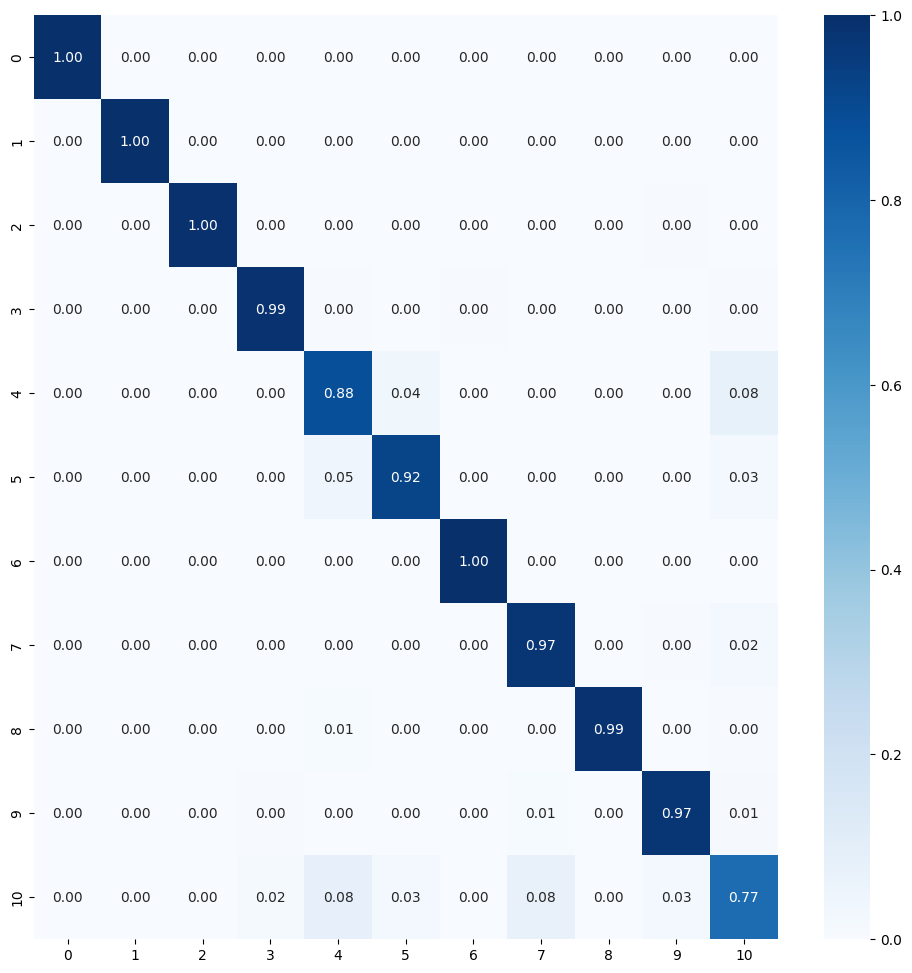


Best fold was 5 with val_accuracy: 0.9541
Average training accuracy in 5-fold: 0.9984719514846802
Average validation precision in 5-fold: 0.9515422105789184

Test Metrics
test_acc_list: [0.9555555582046509, 0.9547474980354309, 0.9555555582046509, 0.9511111378669739, 0.9535353779792786]
Average Test Accuracy with 5-fold: 0.954101026058197
test_loss_list: [0.2782593369483948, 0.2910386621952057, 0.27866873145103455, 0.2945112884044647, 0.2846469283103943]
Average Test Log Loss with 5-fold: 0.2854249894618988

Precision List: [0.955480227321506, 0.9542748523798111, 0.9552204038820875, 0.9506983090682262, 0.9531001492201113]
Average Precision List with 5-fold: 0.9537547883743484
Recall List: [0.9555555555555557, 0.9547474747474748, 0.9555555555555556, 0.951111111111111, 0.9535353535353533]
Average Recall List with 5-fold: 0.9541010101010101
F1 Score List: [0.9549195087743633, 0.9539577624060196, 0.9548798647674581, 0.9504918848510241, 0.9530994804202982]
Average F1 Score List with 5-fold:

In [26]:
%%time

num_classes = 11
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/12
name_save_model: MobileNet_tf_150012
Found 12600 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
393/393 [==============================] - 87s 194ms/step - loss: 0.0601 - accuracy: 0.9912 - val_loss: 0.3248 - va

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150012_1.pkl
394/394 [==============================] - 58s 145ms/step - loss: 0.0179 - accuracy: 0.9987
Train Accuracy: 0.9986507892608643
Train Log Loss: 0.017914719879627228
85/85 [==============================] - 13s 145ms/step - loss: 0.3196 - accuracy: 0.9526
Validation Accuracy: 0.9525926113128662
Validation Log Loss: 0.3196338713169098
85/85 [==============================] - 12s 141ms/step - loss: 0.2845 - accuracy: 0.9574
Test Accuracy: 0.9574074149131775
Test Log Loss: 0.2844683825969696
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   1   0   0   0   0   1   1]
 [  0   0   0

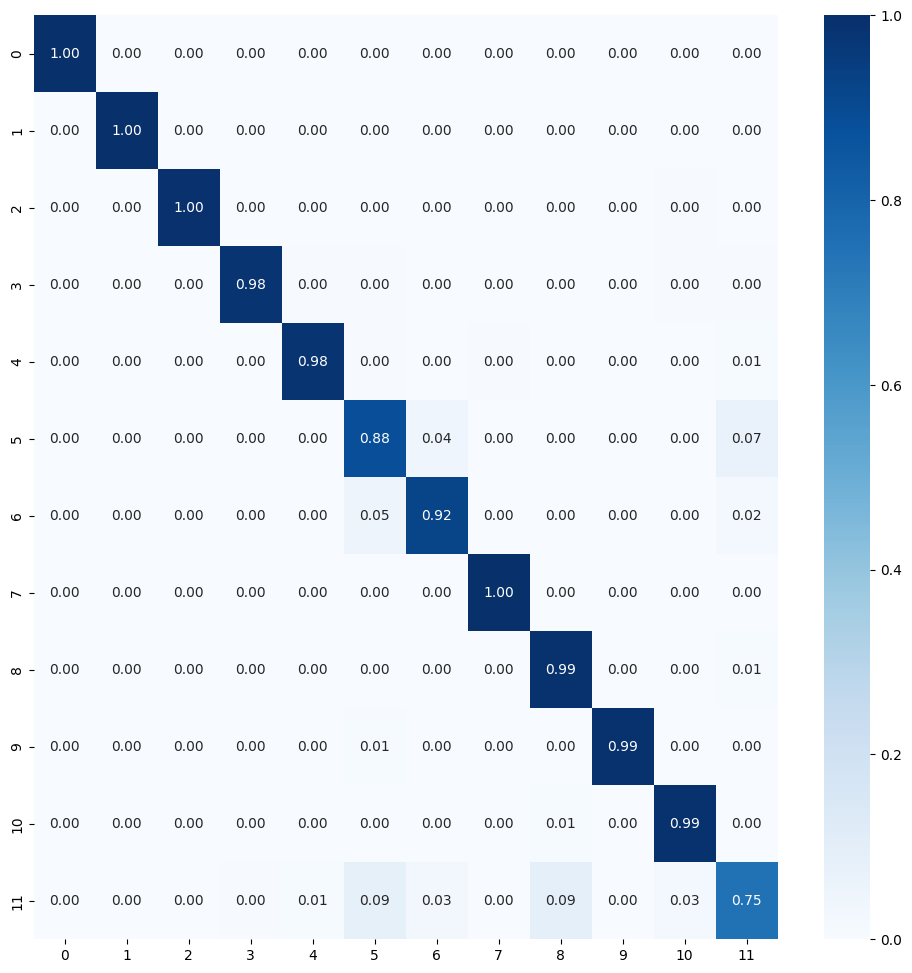


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
393/393 [==============================] - 80s 161ms/step - loss: 0.0589 - accuracy: 0.9923 - val_loss: 0.3957 - val_accuracy: 0.9275 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - 68s 172ms/step - loss: 0.0573 - accuracy: 0.9920 - val_loss: 0.2952 - val_accuracy: 0.9513 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - 70s 177ms/step - loss: 0.0495 - accuracy: 0.9936 - val_loss: 0.3069 - val_accuracy: 0.9382 - lr: 1.0000e-04
Epoch 4/50
393/393 [========================

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150012_2.pkl
394/394 [==============================] - 60s 151ms/step - loss: 0.0174 - accuracy: 0.9986
Train Accuracy: 0.9985714554786682
Train Log Loss: 0.017391381785273552
85/85 [==============================] - 13s 150ms/step - loss: 0.3262 - accuracy: 0.9533
Validation Accuracy: 0.95333331823349
Validation Log Loss: 0.3261638879776001
85/85 [==============================] - 13s 150ms/step - loss: 0.2840 - accuracy: 0.9559
Test Accuracy: 0.9559259414672852
Test Log Loss: 0.28399065136909485
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 220   1   0   0   0   1   0   1   2]
 [  0   0   0 

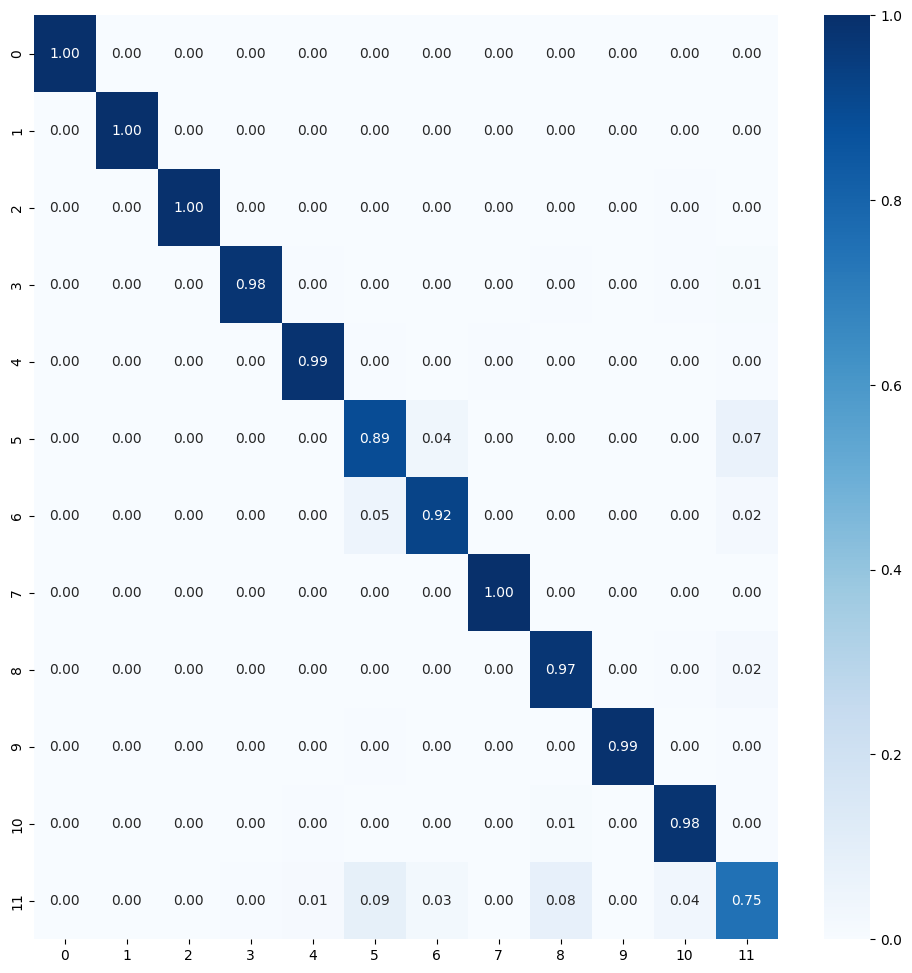


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
393/393 [==============================] - 88s 193ms/step - loss: 0.0556 - accuracy: 0.9927 - val_loss: 0.2916 - val_accuracy: 0.9461 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - 73s 186ms/step - loss: 0.0547 - accuracy: 0.9932 - val_loss: 0.3471 - val_accuracy: 0.9315 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - 75s 190ms/step - loss: 0.0545 - accuracy: 0.9925 - val_loss: 0.3337 - val_accuracy: 0.9501 - lr: 1.0000e-04
Epoch 4/50
393/393 [========================

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150012_3.pkl
394/394 [==============================] - 60s 151ms/step - loss: 0.0149 - accuracy: 0.9987
Train Accuracy: 0.9986507892608643
Train Log Loss: 0.014851178042590618
85/85 [==============================] - 13s 150ms/step - loss: 0.3177 - accuracy: 0.9515
Validation Accuracy: 0.9514814615249634
Validation Log Loss: 0.31774500012397766
85/85 [==============================] - 13s 149ms/step - loss: 0.2771 - accuracy: 0.9552
Test Accuracy: 0.9551851749420166
Test Log Loss: 0.2770630419254303
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1]
 [  0   0   0 221   2   1   0   0   0   0   0   1]
 [  0   0   

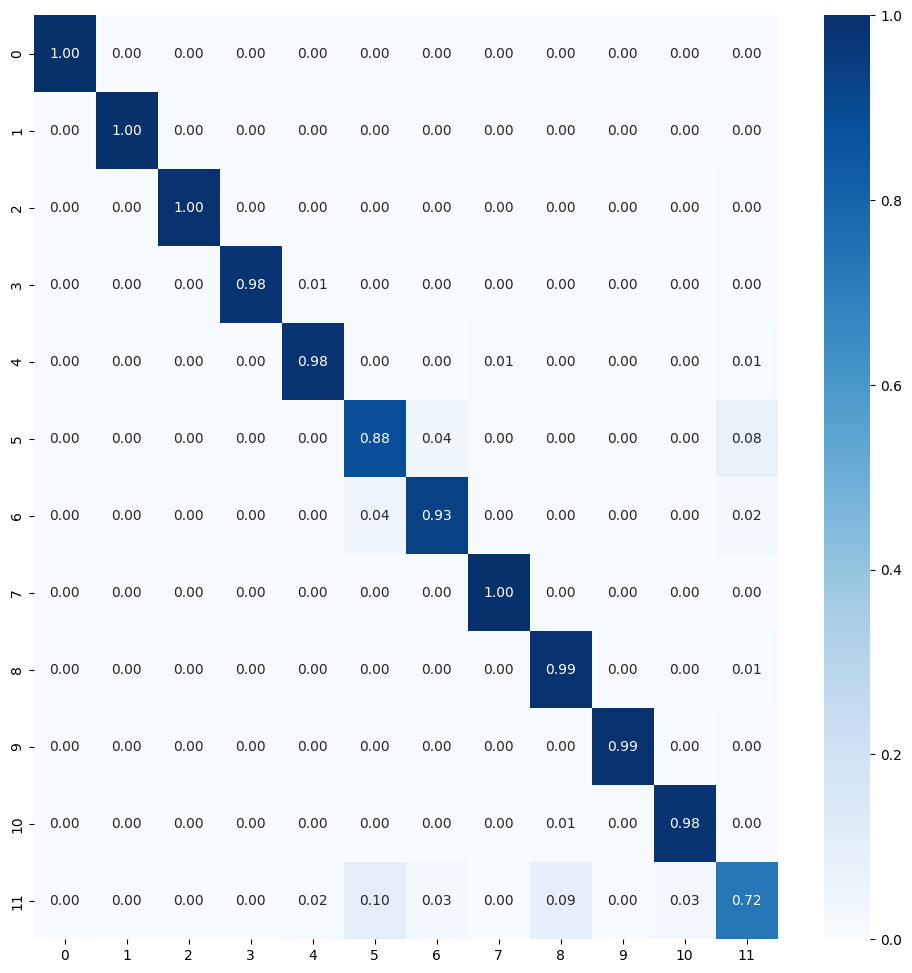


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
360/393 [==========================>...] - ETA: 5s - loss: 0.0594 - accuracy: 0.9923

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



393/393 [==============================] - 59s 149ms/step - loss: 0.0215 - accuracy: 0.9979 - val_loss: 0.3187 - val_accuracy: 0.9524 - lr: 1.0000e-06
Epoch 35/50
393/393 [==============================] - 65s 166ms/step - loss: 0.0217 - accuracy: 0.9977 - val_loss: 0.3218 - val_accuracy: 0.9528 - lr: 1.0000e-06
Epoch 36/50
393/393 [==============================] - 75s 190ms/step - loss: 0.0211 - accuracy: 0.9983 - val_loss: 0.3163 - val_accuracy: 0.9531 - lr: 1.0000e-06
Epoch 37/50
393/393 [==============================] - 74s 189ms/step - loss: 0.0212 - accuracy: 0.9981 - val_loss: 0.3183 - val_accuracy: 0.9535 - lr: 1.0000e-06
Epoch 38/50
393/393 [==============================] - 73s 186ms/step - loss: 0.0214 - accuracy: 0.9978 - val_loss: 0.3236 - val_accuracy: 0.9528 - lr: 1.0000e-06
Epoch 39/50
393/393 [==============================] - 83s 211ms/step - loss: 0.0215 - accuracy: 0.9980 - val_loss: 0.3228 - val_accuracy: 0.9531 - lr: 1.0000e-06
Epoch 40/50
393/393 [=============

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150012_4.pkl
394/394 [==============================] - 50s 127ms/step - loss: 0.0190 - accuracy: 0.9987
Train Accuracy: 0.9986507892608643
Train Log Loss: 0.01901581510901451
85/85 [==============================] - 11s 127ms/step - loss: 0.3259 - accuracy: 0.9533
Validation Accuracy: 0.95333331823349
Validation Log Loss: 0.32586807012557983
85/85 [==============================] - 13s 139ms/step - loss: 0.2840 - accuracy: 0.9559
Test Accuracy: 0.9559259414672852
Test Log Loss: 0.2839702367782593
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2   1   0   0   1   0   0   0]
 [  0   0   0  

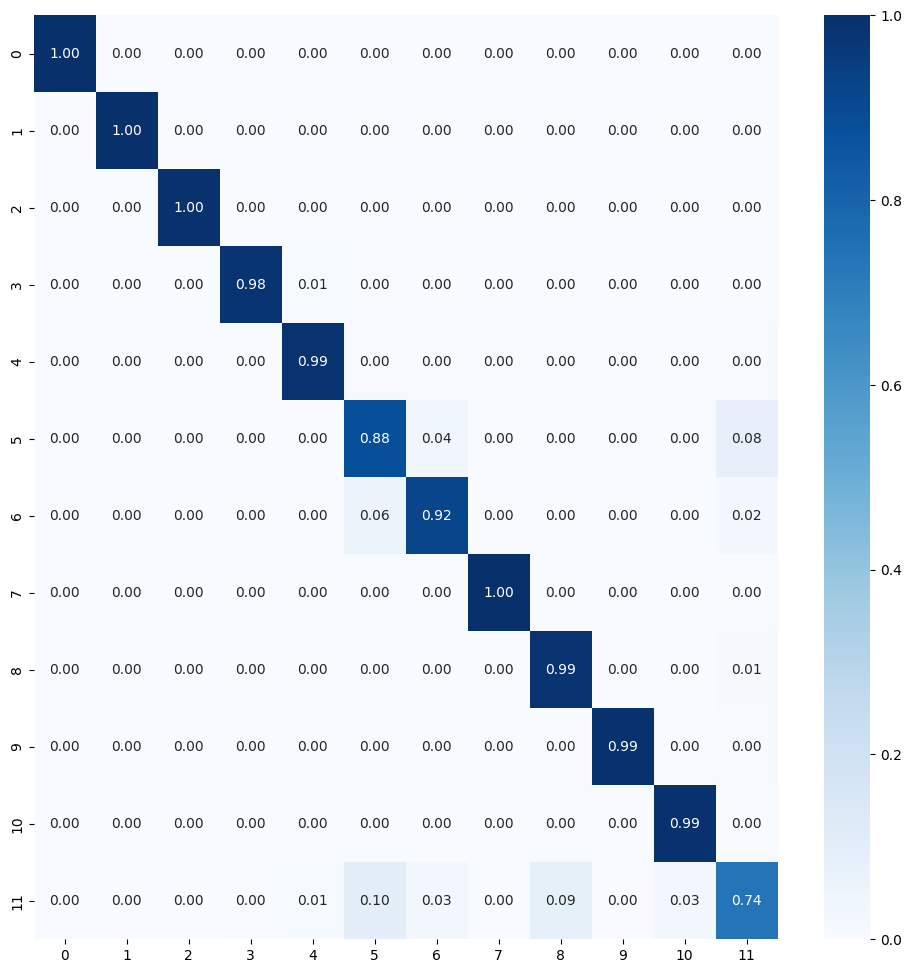


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
393/393 [==============================] - 69s 151ms/step - loss: 0.0615 - accuracy: 0.9908 - val_loss: 0.3624 - val_accuracy: 0.9412 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - 58s 149ms/step - loss: 0.0538 - accuracy: 0.9928 - val_loss: 0.2966 - val_accuracy: 0.9524 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - 58s 147ms/step - loss: 0.0526 - accuracy: 0.9928 - val_loss: 0.2847 - val_accuracy: 0.9498 - lr: 1.0000e-04
Epoch 4/50
393/393 [========================

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150012_5.pkl
394/394 [==============================] - 49s 125ms/step - loss: 0.0150 - accuracy: 0.9986
Train Accuracy: 0.9985714554786682
Train Log Loss: 0.014986860565841198
85/85 [==============================] - 11s 127ms/step - loss: 0.3222 - accuracy: 0.9556
Validation Accuracy: 0.9555555582046509
Validation Log Loss: 0.3221876323223114
85/85 [==============================] - 11s 133ms/step - loss: 0.2770 - accuracy: 0.9585
Test Accuracy: 0.9585185050964355
Test Log Loss: 0.2769981920719147
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1]
 [  0   0   0 223   1   0   0   0   1   0   0   0]
 [  0   0   0

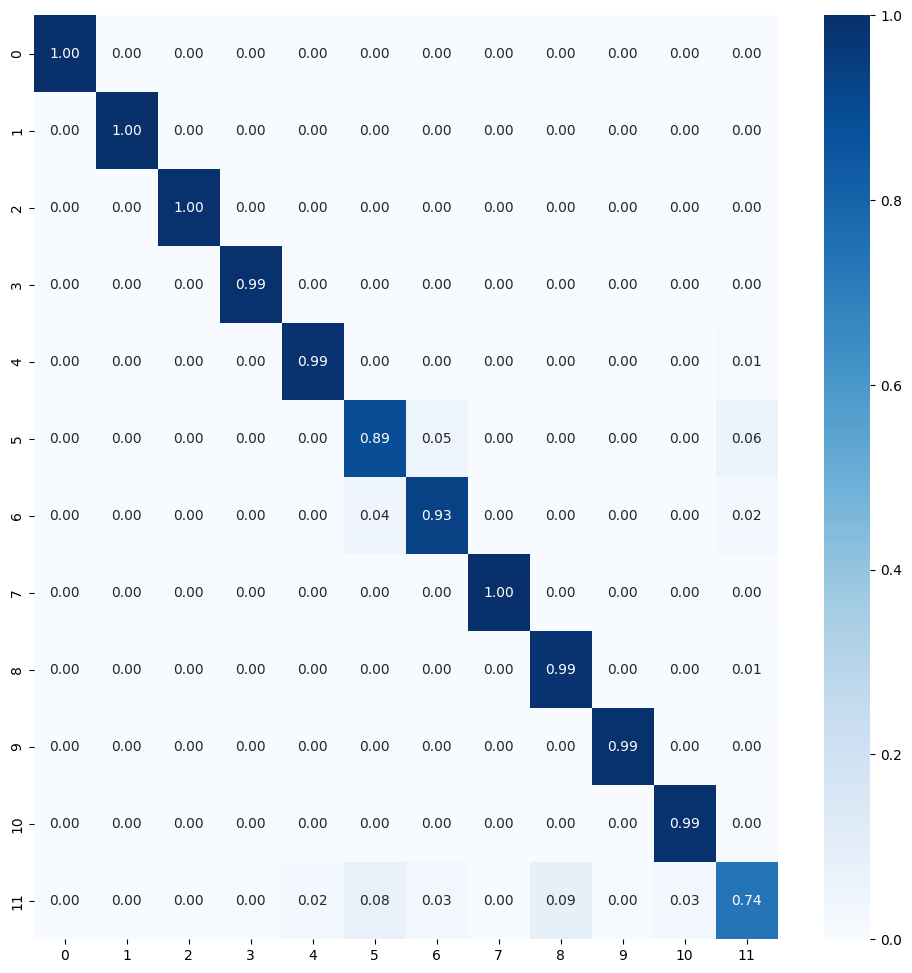


Best fold was 5 with val_accuracy: 0.9565
Average training accuracy in 5-fold: 0.998583710193634
Average validation precision in 5-fold: 0.9549851298332215

Test Metrics
test_acc_list: [0.9574074149131775, 0.9559259414672852, 0.9551851749420166, 0.9559259414672852, 0.9585185050964355]
Average Test Accuracy with 5-fold: 0.95659259557724
test_loss_list: [0.2844683825969696, 0.28399065136909485, 0.2770630419254303, 0.2839702367782593, 0.2769981920719147]
Average Test Log Loss with 5-fold: 0.28129810094833374

Precision List: [0.9572318522105195, 0.9555719354929705, 0.9545630609715755, 0.9555788208766708, 0.9578195049981213]
Average Precision List with 5-fold: 0.9561530349099716
Recall List: [0.9574074074074074, 0.9559259259259258, 0.9551851851851852, 0.955925925925926, 0.9585185185185185]
Average Recall List with 5-fold: 0.9565925925925924
F1 Score List: [0.956739843993437, 0.9553201114344837, 0.954306706295115, 0.9552187148523102, 0.9576024671917751]
Average F1 Score List with 5-fold: 0

In [27]:
%%time

num_classes = 12
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/13
name_save_model: MobileNet_tf_150013
Found 13650 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 101s 210ms/step - loss: 0.0530 - accuracy: 0.9925 - val_loss: 0

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150013_1.pkl
427/427 [==============================] - 67s 156ms/step - loss: 0.0167 - accuracy: 0.9986
Train Accuracy: 0.9986080527305603
Train Log Loss: 0.01669565588235855
92/92 [==============================] - 14s 146ms/step - loss: 0.2889 - accuracy: 0.9538
Validation Accuracy: 0.9538461565971375
Validation Log Loss: 0.28889721632003784
92/92 [==============================] - 14s 152ms/step - loss: 0.2563 - accuracy: 0.9593
Test Accuracy: 0.9593162536621094
Test Log Loss: 0.2562771141529083
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   0   0   0 

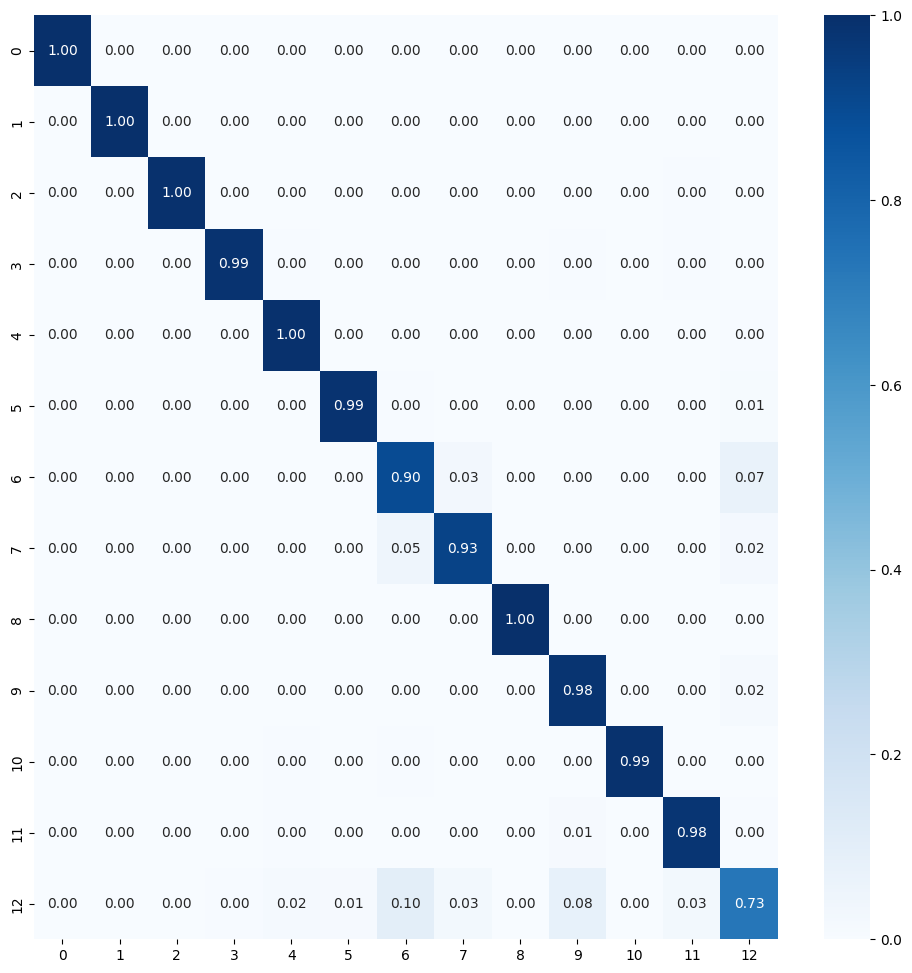


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 94s 193ms/step - loss: 0.0528 - accuracy: 0.9939 - val_loss: 0.3740 - val_accuracy: 0.9293 - lr: 1.0000e-04
Epoch 2/50
426/426 [==============================] - 77s 181ms/step - loss: 0.0499 - accuracy: 0.9927 - val_loss: 0.2640 - val_accuracy: 0.9505 - lr: 1.0000e-04
Epoch 3/50
426/426 [==============================] - 65s 152ms/step - loss: 0.0473 - accuracy: 0.9946 - val_loss: 0.2660 - val_accuracy: 0.9495 - lr: 1.0000e-04
Epoch 4/50
426/426 [========================

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150013_2.pkl
427/427 [==============================] - 58s 134ms/step - loss: 0.0152 - accuracy: 0.9986
Train Accuracy: 0.9986080527305603
Train Log Loss: 0.015226063318550587
92/92 [==============================] - 13s 137ms/step - loss: 0.2990 - accuracy: 0.9562
Validation Accuracy: 0.9562393426895142
Validation Log Loss: 0.2990085482597351
92/92 [==============================] - 12s 133ms/step - loss: 0.2525 - accuracy: 0.9610
Test Accuracy: 0.9610256552696228
Test Log Loss: 0.25252801179885864
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   0   0   0

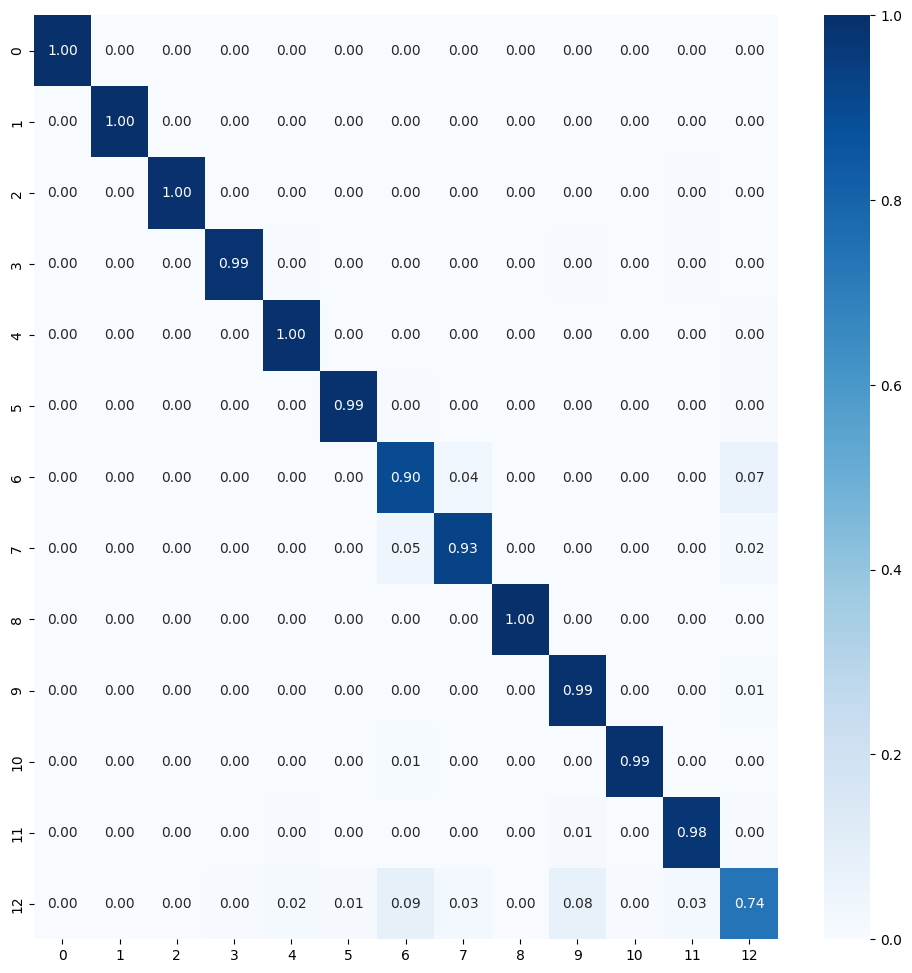


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 80s 166ms/step - loss: 0.0524 - accuracy: 0.9932 - val_loss: 0.2532 - val_accuracy: 0.9485 - lr: 1.0000e-04
Epoch 2/50
426/426 [==============================] - 69s 161ms/step - loss: 0.0509 - accuracy: 0.9924 - val_loss: 0.2894 - val_accuracy: 0.9495 - lr: 1.0000e-04
Epoch 3/50
426/426 [==============================] - 72s 169ms/step - loss: 0.0483 - accuracy: 0.9929 - val_loss: 0.2380 - val_accuracy: 0.9540 - lr: 1.0000e-04
Epoch 4/50
426/426 [========================

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150013_3.pkl
427/427 [==============================] - 68s 158ms/step - loss: 0.0164 - accuracy: 0.9985
Train Accuracy: 0.9985347986221313
Train Log Loss: 0.01637304201722145
92/92 [==============================] - 15s 161ms/step - loss: 0.2998 - accuracy: 0.9552
Validation Accuracy: 0.9552136659622192
Validation Log Loss: 0.29975712299346924
92/92 [==============================] - 16s 162ms/step - loss: 0.2554 - accuracy: 0.9576
Test Accuracy: 0.957606852054596
Test Log Loss: 0.2554192841053009
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   0   0   0  

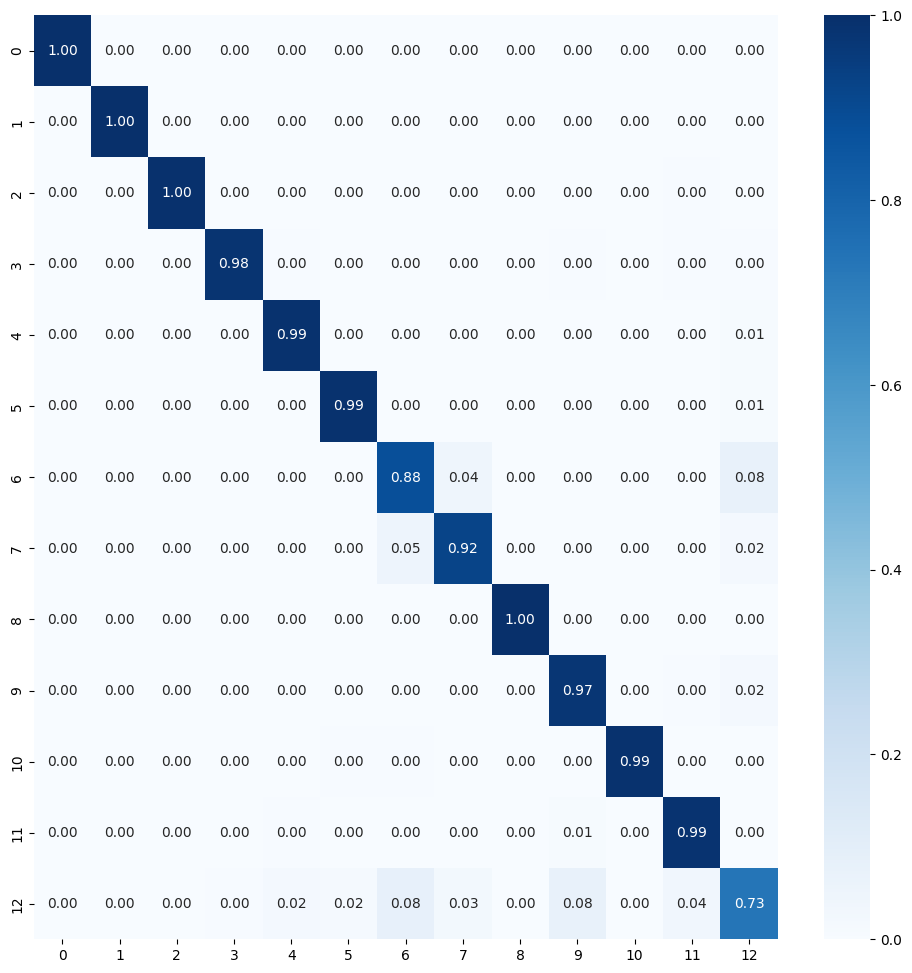


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 99s 202ms/step - loss: 0.0525 - accuracy: 0.9927 - val_loss: 0.3297 - val_accuracy: 0.9234 - lr: 1.0000e-04
Epoch 2/50
426/426 [==============================] - 72s 168ms/step - loss: 0.0480 - accuracy: 0.9938 - val_loss: 0.3124 - val_accuracy: 0.9317 - lr: 1.0000e-04
Epoch 3/50
426/426 [==============================] - 70s 164ms/step - loss: 0.0486 - accuracy: 0.9926 - val_loss: 0.2956 - val_accuracy: 0.9444 - lr: 1.0000e-04
Epoch 4/50
426/426 [========================

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150013_4.pkl
427/427 [==============================] - 63s 147ms/step - loss: 0.0152 - accuracy: 0.9987
Train Accuracy: 0.9986813068389893
Train Log Loss: 0.015156605280935764
92/92 [==============================] - 15s 144ms/step - loss: 0.2976 - accuracy: 0.9556
Validation Accuracy: 0.9555555582046509
Validation Log Loss: 0.29755887389183044
92/92 [==============================] - 15s 145ms/step - loss: 0.2613 - accuracy: 0.9590
Test Accuracy: 0.9589743614196777
Test Log Loss: 0.2612566649913788
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   0   0   0

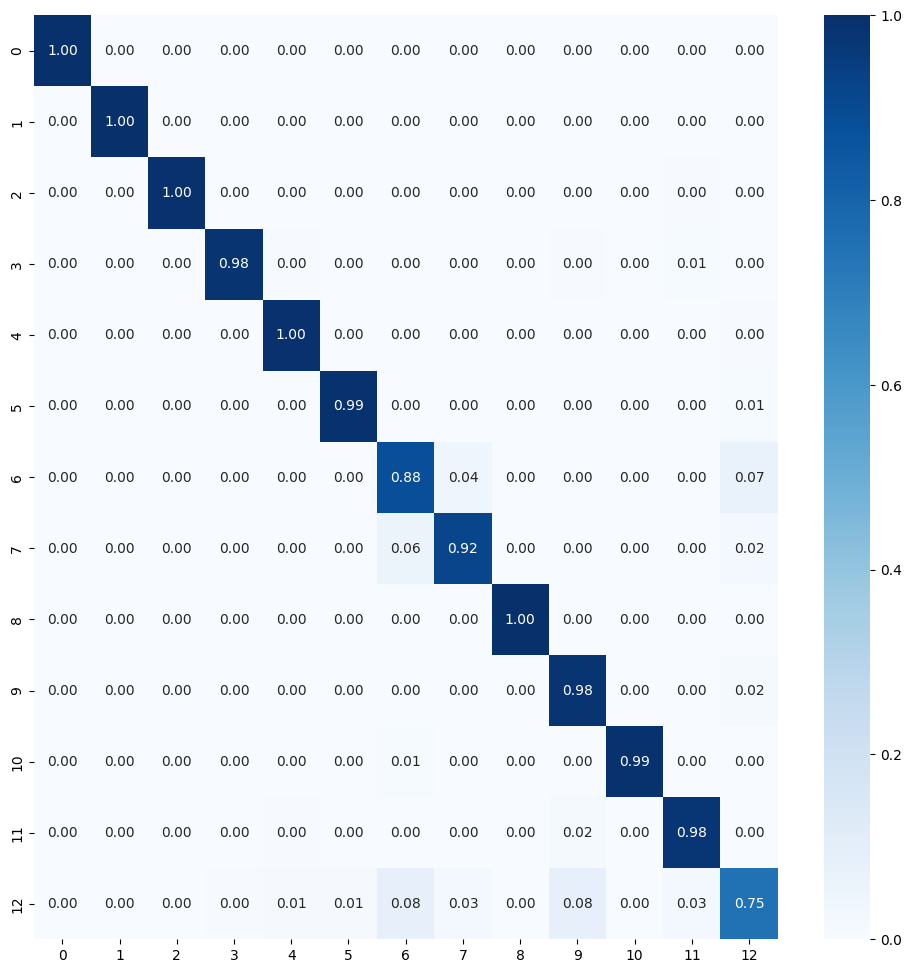


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 97s 200ms/step - loss: 0.0543 - accuracy: 0.9924 - val_loss: 0.2957 - val_accuracy: 0.9385 - lr: 1.0000e-04
Epoch 2/50
426/426 [==============================] - 75s 174ms/step - loss: 0.0523 - accuracy: 0.9913 - val_loss: 0.2635 - val_accuracy: 0.9505 - lr: 1.0000e-04
Epoch 3/50
426/426 [==============================] - 76s 177ms/step - loss: 0.0431 - accuracy: 0.9952 - val_loss: 0.2646 - val_accuracy: 0.9550 - lr: 1.0000e-04
Epoch 4/50
426/426 [========================

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150013_5.pkl
427/427 [==============================] - 56s 132ms/step - loss: 0.0137 - accuracy: 0.9987
Train Accuracy: 0.9986813068389893
Train Log Loss: 0.013712989166378975
92/92 [==============================] - 12s 132ms/step - loss: 0.2906 - accuracy: 0.9569
Validation Accuracy: 0.9569230675697327
Validation Log Loss: 0.2906251847743988
92/92 [==============================] - 12s 132ms/step - loss: 0.2505 - accuracy: 0.9597
Test Accuracy: 0.959658145904541
Test Log Loss: 0.25048190355300903
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 221   1   0   0   0   0 

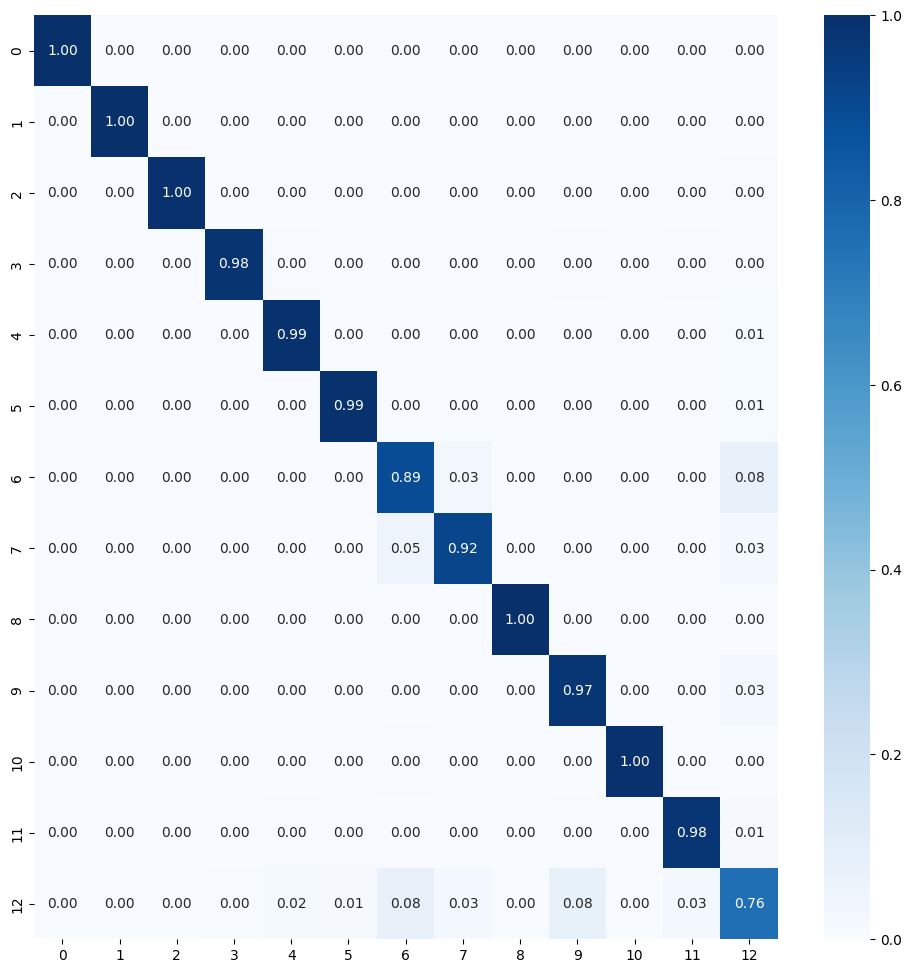


Best fold was 5 with val_accuracy: 0.9584
Average training accuracy in 5-fold: 0.9987222671508789
Average validation precision in 5-fold: 0.9577609896659851

Test Metrics
test_acc_list: [0.9593162536621094, 0.9610256552696228, 0.957606852054596, 0.9589743614196777, 0.959658145904541]
Average Test Accuracy with 5-fold: 0.9593162536621094
test_loss_list: [0.2562771141529083, 0.25252801179885864, 0.2554192841053009, 0.2612566649913788, 0.25048190355300903]
Average Test Log Loss with 5-fold: 0.2551925957202911

Precision List: [0.9589368078916181, 0.9606975662198443, 0.9568648480841138, 0.9586613719844443, 0.9592190712633099]
Average Precision List with 5-fold: 0.958875933088666
Recall List: [0.9593162393162393, 0.961025641025641, 0.9576068376068375, 0.958974358974359, 0.9596581196581196]
Average Recall List with 5-fold: 0.9593162393162393
F1 Score List: [0.9585870679375652, 0.9602614336093432, 0.9568547281631617, 0.9583547379199826, 0.9592465096189715]
Average F1 Score List with 5-fold: 

In [28]:
%%time

num_classes = 13
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/14
name_save_model: MobileNet_tf_150014
Found 14700 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_23 - Trainable: True
dropout_46 - Trainable: True
dense_70 - Trainable: True
dropout_47 - Trainable: True
dense_71 - Trainable: True
Epoch 1/50
459/459 [==============================] - 94s 182ms/step - loss: 0.1169 - accuracy: 0.9629 - val_

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150014_1.pkl
460/460 [==============================] - 65s 138ms/step - loss: 0.0639 - accuracy: 0.9773
Train Accuracy: 0.9772788882255554
Train Log Loss: 0.0638580173254013
99/99 [==============================] - 14s 137ms/step - loss: 0.3527 - accuracy: 0.9308
Validation Accuracy: 0.9307936429977417
Validation Log Loss: 0.3527180254459381
99/99 [==============================] - 14s 143ms/step - loss: 0.3204 - accuracy: 0.9343
Test Accuracy: 0.9342857003211975
Test Log Loss: 0.32041946053504944
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 

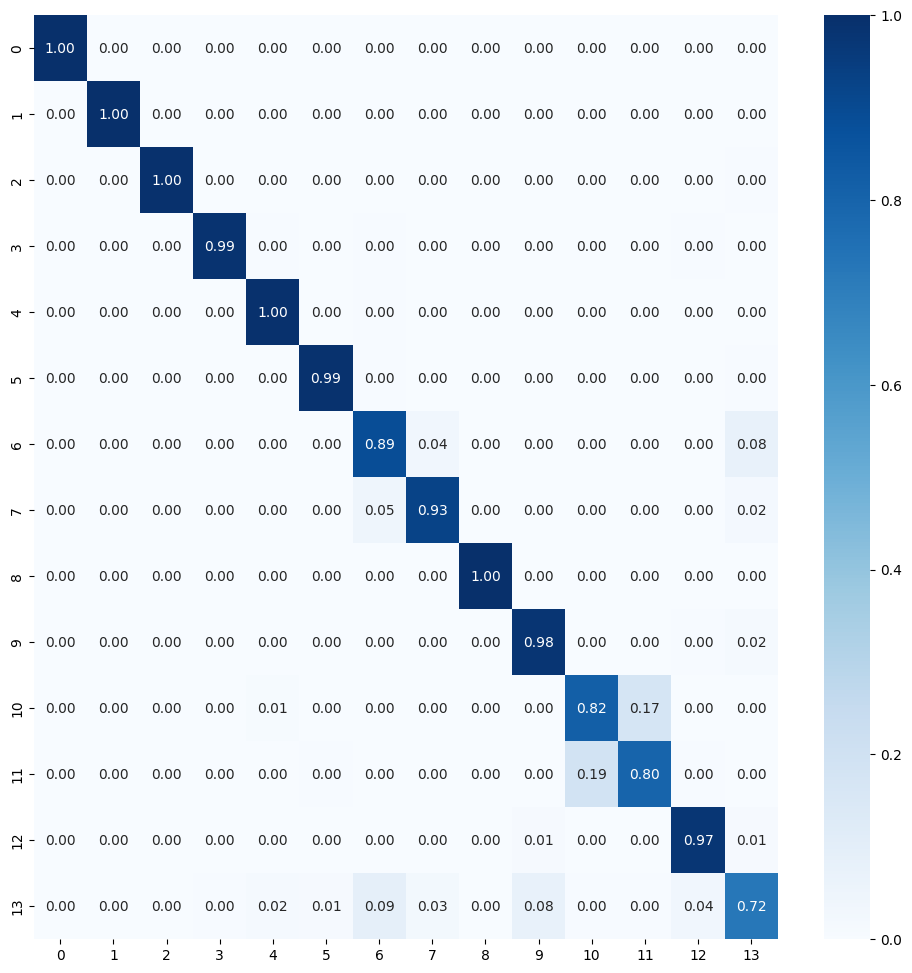


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_23 - Trainable: True
dropout_46 - Trainable: True
dense_70 - Trainable: True
dropout_47 - Trainable: True
dense_71 - Trainable: True
Epoch 1/50
459/459 [==============================] - 85s 163ms/step - loss: 0.1203 - accuracy: 0.9601 - val_loss: 0.3426 - val_accuracy: 0.9098 - lr: 1.0000e-04
Epoch 2/50
459/459 [==============================] - 77s 168ms/step - loss: 0.1177 - accuracy: 0.9597 - val_loss: 0.3294 - val_accuracy: 0.9104 - lr: 1.0000e-04
Epoch 3/50
459/459 [==============================] - 76s 165ms/step - loss: 0.1144 - accuracy: 0.9618 - val_loss: 0.3075 - val_accuracy: 0.9222 - lr: 1.0000e-04
Epoch 4/50
459/459 [========================

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150014_2.pkl
460/460 [==============================] - 61s 133ms/step - loss: 0.0639 - accuracy: 0.9777
Train Accuracy: 0.9776870608329773
Train Log Loss: 0.06386908143758774
99/99 [==============================] - 14s 131ms/step - loss: 0.3533 - accuracy: 0.9295
Validation Accuracy: 0.9295238256454468
Validation Log Loss: 0.35328802466392517
99/99 [==============================] - 13s 131ms/step - loss: 0.3221 - accuracy: 0.9340
Test Accuracy: 0.9339682459831238
Test Log Loss: 0.32208147644996643
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   

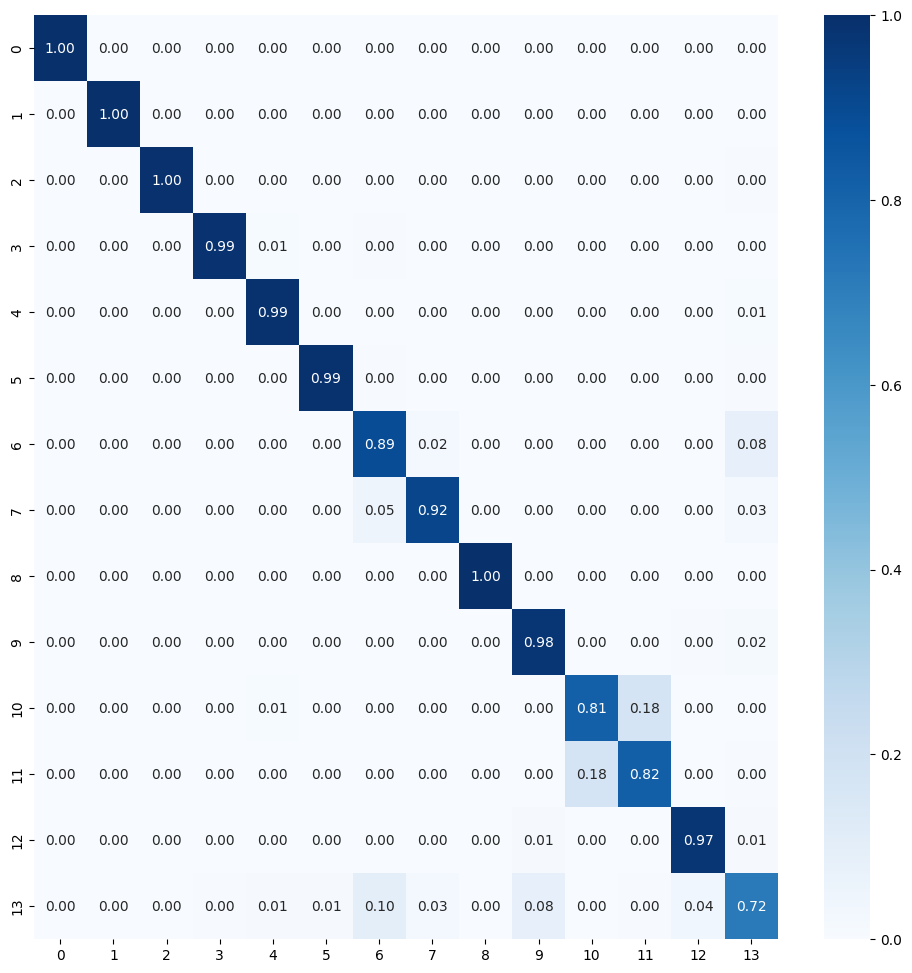


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_23 - Trainable: True
dropout_46 - Trainable: True
dense_70 - Trainable: True
dropout_47 - Trainable: True
dense_71 - Trainable: True
Epoch 1/50
459/459 [==============================] - 86s 165ms/step - loss: 0.1185 - accuracy: 0.9607 - val_loss: 0.3167 - val_accuracy: 0.9232 - lr: 1.0000e-04
Epoch 2/50
459/459 [==============================] - 72s 156ms/step - loss: 0.1157 - accuracy: 0.9618 - val_loss: 0.3163 - val_accuracy: 0.9251 - lr: 1.0000e-04
Epoch 3/50
459/459 [==============================] - 71s 155ms/step - loss: 0.1164 - accuracy: 0.9603 - val_loss: 0.3162 - val_accuracy: 0.9088 - lr: 1.0000e-04
Epoch 4/50
459/459 [========================

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150014_3.pkl
460/460 [==============================] - 61s 131ms/step - loss: 0.0649 - accuracy: 0.9777
Train Accuracy: 0.9776870608329773
Train Log Loss: 0.06487192213535309
99/99 [==============================] - 14s 139ms/step - loss: 0.3539 - accuracy: 0.9283
Validation Accuracy: 0.9282539486885071
Validation Log Loss: 0.35387447476387024
99/99 [==============================] - 15s 150ms/step - loss: 0.3233 - accuracy: 0.9343
Test Accuracy: 0.9342857003211975
Test Log Loss: 0.32327982783317566
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   

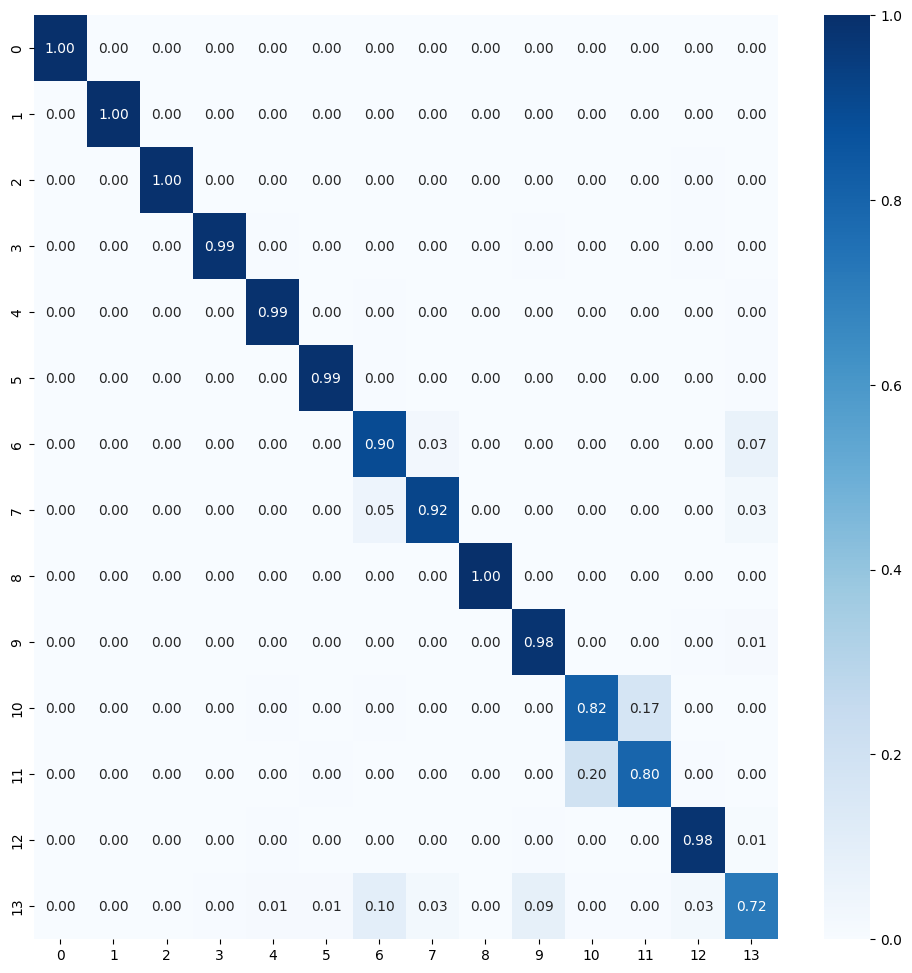


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_23 - Trainable: True
dropout_46 - Trainable: True
dense_70 - Trainable: True
dropout_47 - Trainable: True
dense_71 - Trainable: True
Epoch 1/50
459/459 [==============================] - 86s 167ms/step - loss: 0.1202 - accuracy: 0.9595 - val_loss: 0.3185 - val_accuracy: 0.9180 - lr: 1.0000e-04
Epoch 2/50
459/459 [==============================] - 74s 161ms/step - loss: 0.1141 - accuracy: 0.9634 - val_loss: 0.3682 - val_accuracy: 0.9168 - lr: 1.0000e-04
Epoch 3/50
459/459 [==============================] - 83s 180ms/step - loss: 0.1128 - accuracy: 0.9625 - val_loss: 0.3702 - val_accuracy: 0.9149 - lr: 1.0000e-04
Epoch 4/50
459/459 [========================

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150014_4.pkl
460/460 [==============================] - 55s 118ms/step - loss: 0.0680 - accuracy: 0.9761
Train Accuracy: 0.9761224389076233
Train Log Loss: 0.06802108138799667
99/99 [==============================] - 11s 113ms/step - loss: 0.3580 - accuracy: 0.9302
Validation Accuracy: 0.9301587343215942
Validation Log Loss: 0.35803505778312683
99/99 [==============================] - 11s 112ms/step - loss: 0.3212 - accuracy: 0.9330
Test Accuracy: 0.9330158829689026
Test Log Loss: 0.32115671038627625
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   

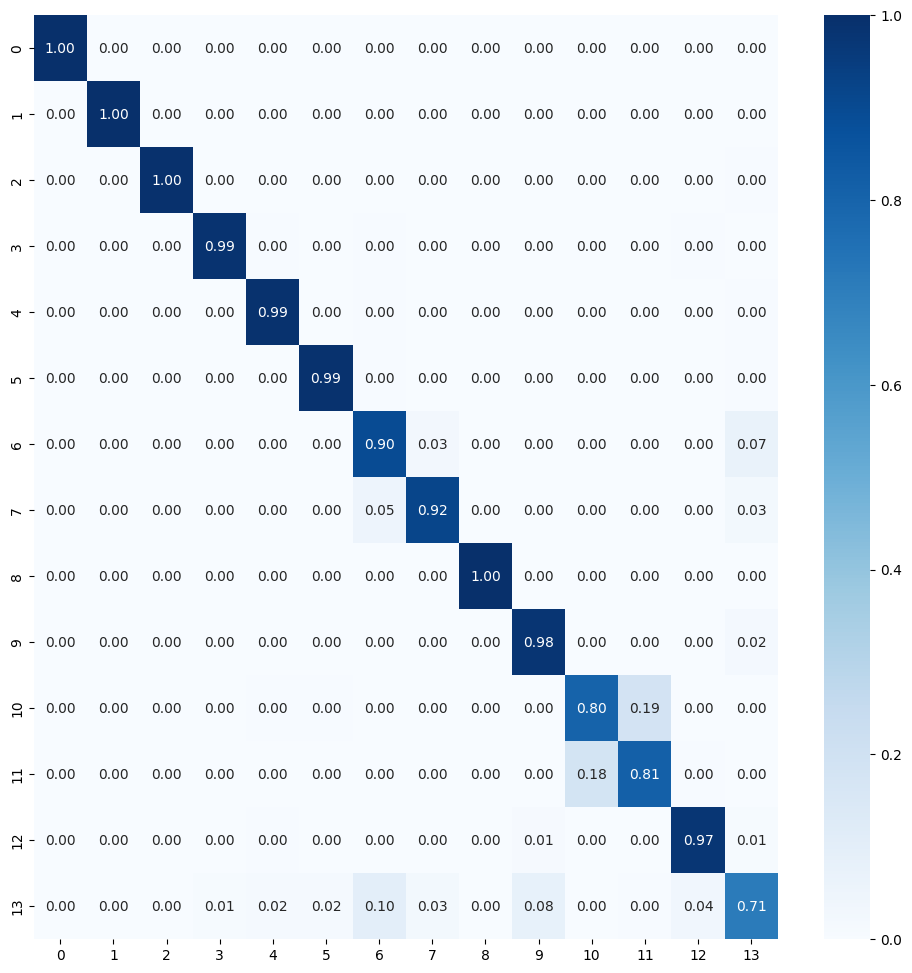


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_23 - Trainable: True
dropout_46 - Trainable: True
dense_70 - Trainable: True
dropout_47 - Trainable: True
dense_71 - Trainable: True
Epoch 1/50
459/459 [==============================] - 43s 81ms/step - loss: 0.1184 - accuracy: 0.9595 - val_loss: 0.3348 - val_accuracy: 0.9200 - lr: 1.0000e-04
Epoch 2/50
459/459 [==============================] - 61s 133ms/step - loss: 0.1160 - accuracy: 0.9611 - val_loss: 0.3322 - val_accuracy: 0.9110 - lr: 1.0000e-04
Epoch 3/50
459/459 [==============================] - 71s 156ms/step - loss: 0.1122 - accuracy: 0.9628 - val_loss: 0.3435 - val_accuracy: 0.9047 - lr: 1.0000e-04
Epoch 4/50
459/459 [=========================

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150014_5.pkl
460/460 [==============================] - 50s 109ms/step - loss: 0.0631 - accuracy: 0.9780
Train Accuracy: 0.9780272245407104
Train Log Loss: 0.0631427988409996
99/99 [==============================] - 13s 123ms/step - loss: 0.3475 - accuracy: 0.9295
Validation Accuracy: 0.9295238256454468
Validation Log Loss: 0.3475293219089508
99/99 [==============================] - 13s 115ms/step - loss: 0.3097 - accuracy: 0.9343
Test Accuracy: 0.9342857003211975
Test Log Loss: 0.30970680713653564
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 

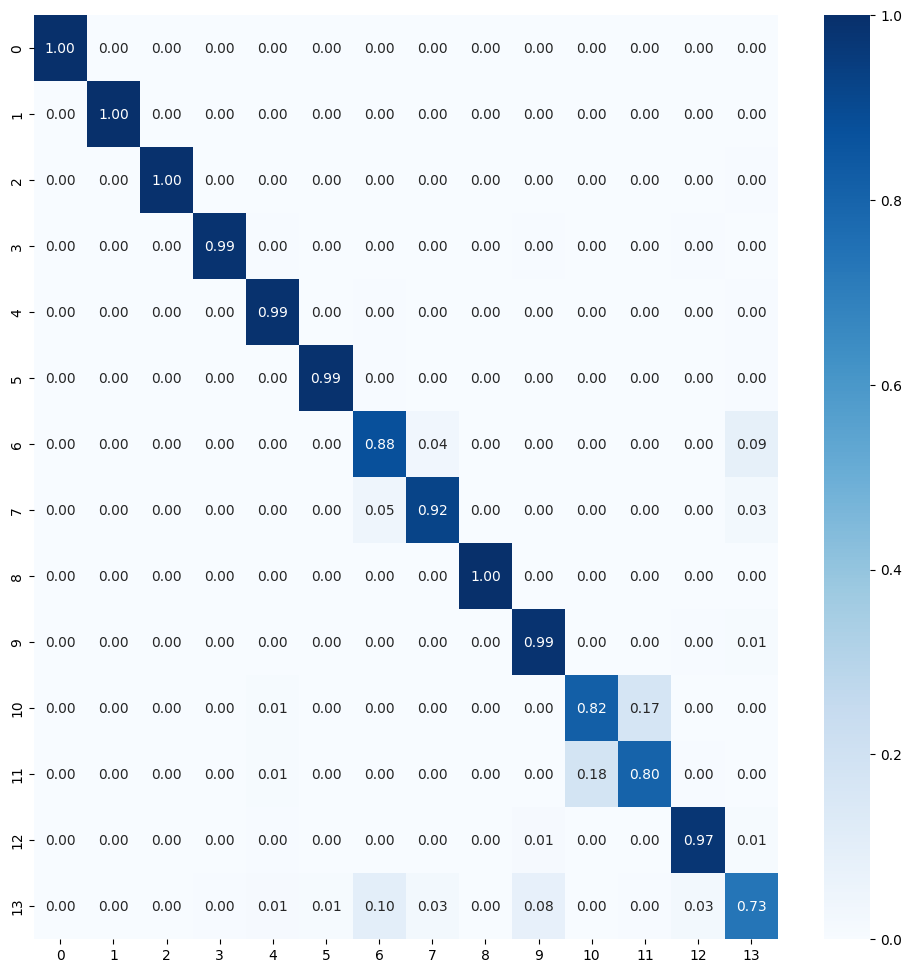


Best fold was 1 with val_accuracy: 0.9330
Average training accuracy in 5-fold: 0.9754022359848022
Average validation precision in 5-fold: 0.9313137888908386

Test Metrics
test_acc_list: [0.9342857003211975, 0.9339682459831238, 0.9342857003211975, 0.9330158829689026, 0.9342857003211975]
Average Test Accuracy with 5-fold: 0.9339682459831238
test_loss_list: [0.32041946053504944, 0.32208147644996643, 0.32327982783317566, 0.32115671038627625, 0.30970680713653564]
Average Test Log Loss with 5-fold: 0.3193288564682007

Precision List: [0.9335800862455246, 0.9333599852989399, 0.9337841868761835, 0.9323130219300649, 0.933619497962041]
Average Precision List with 5-fold: 0.9333313556625509
Recall List: [0.9342857142857143, 0.9339682539682539, 0.9342857142857144, 0.9330158730158729, 0.934285714285714]
Average Recall List with 5-fold: 0.933968253968254
F1 Score List: [0.9334924763555935, 0.9332720212936687, 0.9334602390486639, 0.9321538635249839, 0.9335589727765446]
Average F1 Score List with 5-f

In [29]:
%%time

num_classes = 14
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/15
name_save_model: MobileNet_tf_150015
Found 15750 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small
- upatre

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_28 - Trainable: True
dropout_56 - Trainable: True
dense_85 - Trainable: True
dropout_57 - Trainable: True
dense_86 - Trainable: True
Epoch 1/50
492/492 [==============================] - 86s 152ms/step - loss: 0.1142 - accuracy: 0.96

History for fold 1 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150015_1.pkl
493/493 [==============================] - 65s 131ms/step - loss: 0.0635 - accuracy: 0.9785
Train Accuracy: 0.9784761667251587
Train Log Loss: 0.0634957104921341
106/106 [==============================] - 14s 130ms/step - loss: 0.3620 - accuracy: 0.9289
Validation Accuracy: 0.9288889169692993
Validation Log Loss: 0.36202549934387207
106/106 [==============================] - 14s 130ms/step - loss: 0.3164 - accuracy: 0.9360
Test Accuracy: 0.9359999895095825
Test Log Loss: 0.31643110513687134
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0 

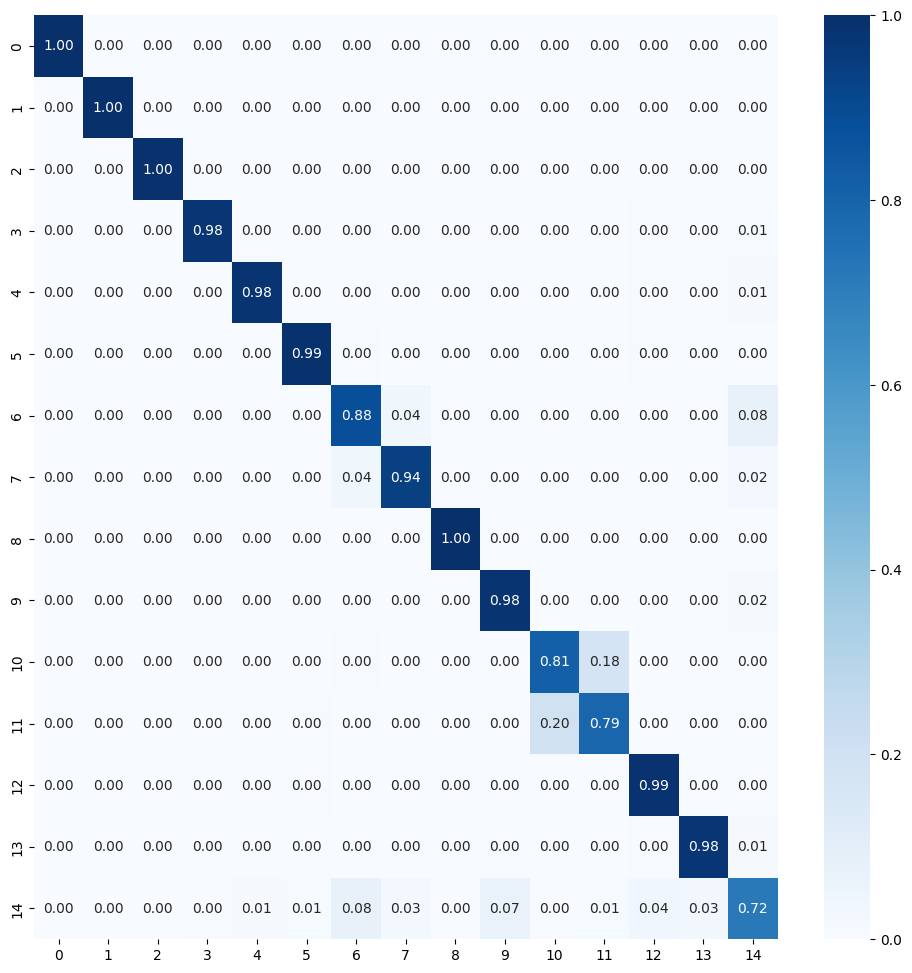


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_28 - Trainable: True
dropout_56 - Trainable: True
dense_85 - Trainable: True
dropout_57 - Trainable: True
dense_86 - Trainable: True
Epoch 1/50
492/492 [==============================] - 91s 165ms/step - loss: 0.1124 - accuracy: 0.9625 - val_loss: 0.3166 - val_accuracy: 0.9241 - lr: 1.0000e-04
Epoch 2/50
492/492 [==============================] - 83s 168ms/step - loss: 0.1106 - accuracy: 0.9630 - val_loss: 0.4282 - val_accuracy: 0.9021 - lr: 1.0000e-04
Epoch 3/50
492/492 [==============================] - 79s 160ms/step - loss: 0.1101 - accuracy: 0.9628 - val_loss: 0.3542 - val_accuracy: 0.9226 - lr: 1.0000e-04
Epoch 4/50
492/492 [========================

History for fold 2 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150015_2.pkl
493/493 [==============================] - 61s 123ms/step - loss: 0.0664 - accuracy: 0.9770
Train Accuracy: 0.9769523739814758
Train Log Loss: 0.06640280783176422
106/106 [==============================] - 14s 124ms/step - loss: 0.3613 - accuracy: 0.9298
Validation Accuracy: 0.9297778010368347
Validation Log Loss: 0.36134418845176697
106/106 [==============================] - 14s 122ms/step - loss: 0.3134 - accuracy: 0.9360
Test Accuracy: 0.9359999895095825
Test Log Loss: 0.3133770227432251
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0 

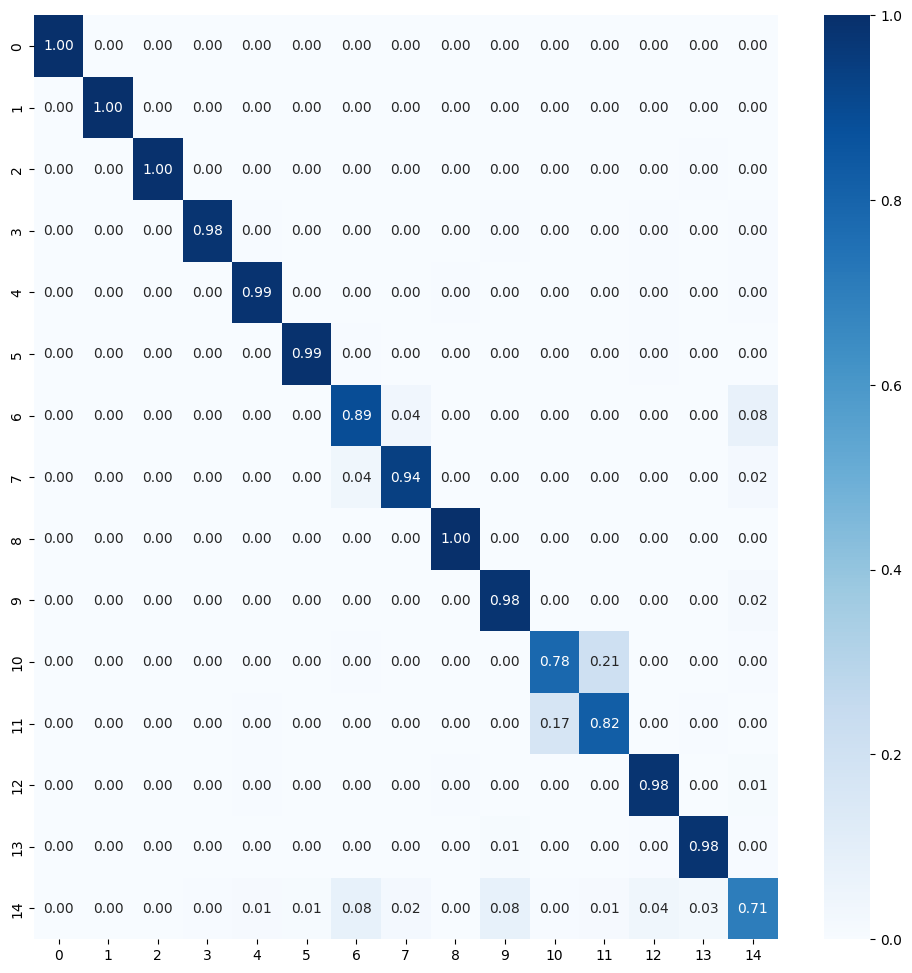


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_28 - Trainable: True
dropout_56 - Trainable: True
dense_85 - Trainable: True
dropout_57 - Trainable: True
dense_86 - Trainable: True
Epoch 1/50
492/492 [==============================] - 57s 108ms/step - loss: 0.1129 - accuracy: 0.9630 - val_loss: 0.4241 - val_accuracy: 0.8979 - lr: 1.0000e-04
Epoch 2/50
492/492 [==============================] - 65s 131ms/step - loss: 0.1123 - accuracy: 0.9642 - val_loss: 0.3861 - val_accuracy: 0.9000 - lr: 1.0000e-04
Epoch 3/50
492/492 [==============================] - 79s 160ms/step - loss: 0.1093 - accuracy: 0.9634 - val_loss: 0.3455 - val_accuracy: 0.9247 - lr: 1.0000e-04
Epoch 4/50
492/492 [========================

History for fold 3 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150015_3.pkl
493/493 [==============================] - 60s 121ms/step - loss: 0.0613 - accuracy: 0.9783
Train Accuracy: 0.9783492088317871
Train Log Loss: 0.061280280351638794
106/106 [==============================] - 13s 120ms/step - loss: 0.3531 - accuracy: 0.9319
Validation Accuracy: 0.931851863861084
Validation Log Loss: 0.3531138002872467
106/106 [==============================] - 14s 130ms/step - loss: 0.3069 - accuracy: 0.9378
Test Accuracy: 0.9377777576446533
Test Log Loss: 0.30693143606185913
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0 

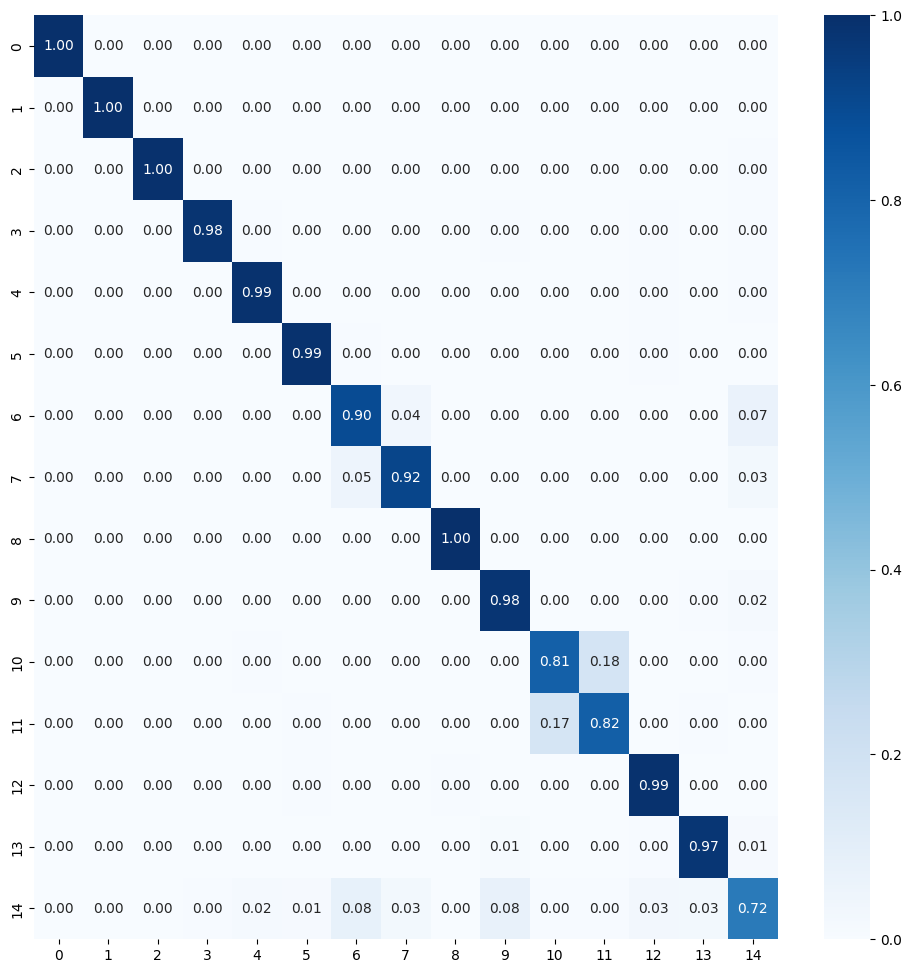


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_28 - Trainable: True
dropout_56 - Trainable: True
dense_85 - Trainable: True
dropout_57 - Trainable: True
dense_86 - Trainable: True
Epoch 1/50
492/492 [==============================] - 87s 158ms/step - loss: 0.1157 - accuracy: 0.9615 - val_loss: 0.5739 - val_accuracy: 0.8774 - lr: 1.0000e-04
Epoch 2/50
492/492 [==============================] - 75s 153ms/step - loss: 0.1120 - accuracy: 0.9637 - val_loss: 0.3557 - val_accuracy: 0.9060 - lr: 1.0000e-04
Epoch 3/50
492/492 [==============================] - 75s 151ms/step - loss: 0.1098 - accuracy: 0.9635 - val_loss: 0.3626 - val_accuracy: 0.9244 - lr: 1.0000e-04
Epoch 4/50
492/492 [========================

History for fold 4 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150015_4.pkl
493/493 [==============================] - 68s 137ms/step - loss: 0.0613 - accuracy: 0.9779
Train Accuracy: 0.977904736995697
Train Log Loss: 0.06133021041750908
106/106 [==============================] - 16s 142ms/step - loss: 0.3524 - accuracy: 0.9301
Validation Accuracy: 0.9300740957260132
Validation Log Loss: 0.35239484906196594
106/106 [==============================] - 15s 137ms/step - loss: 0.3085 - accuracy: 0.9372
Test Accuracy: 0.9371851682662964
Test Log Loss: 0.3084605634212494
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0  

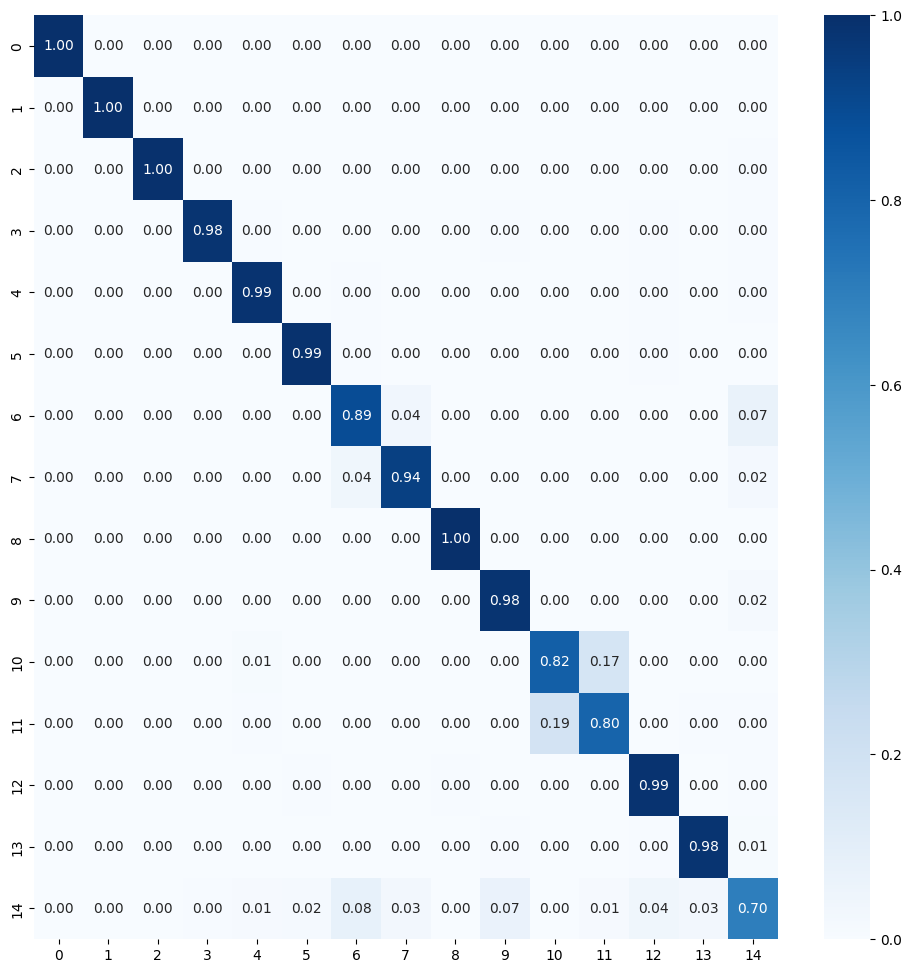


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_28 - Trainable: True
dropout_56 - Trainable: True
dense_85 - Trainable: True
dropout_57 - Trainable: True
dense_86 - Trainable: True
Epoch 1/50
492/492 [==============================] - 97s 176ms/step - loss: 0.1142 - accuracy: 0.9619 - val_loss: 0.3318 - val_accuracy: 0.9104 - lr: 1.0000e-04
Epoch 2/50
492/492 [==============================] - 90s 182ms/step - loss: 0.1093 - accuracy: 0.9648 - val_loss: 0.3198 - val_accuracy: 0.9152 - lr: 1.0000e-04
Epoch 3/50
492/492 [==============================] - 82s 166ms/step - loss: 0.1089 - accuracy: 0.9634 - val_loss: 0.3574 - val_accuracy: 0.9015 - lr: 1.0000e-04
Epoch 4/50
492/492 [========================

History for fold 5 saved as c7_base_pickle_plus_50_epochs_MobileNet_tf_150015_5.pkl
493/493 [==============================] - 74s 150ms/step - loss: 0.0670 - accuracy: 0.9776
Train Accuracy: 0.9775872826576233
Train Log Loss: 0.066965252161026
106/106 [==============================] - 15s 142ms/step - loss: 0.3566 - accuracy: 0.9301
Validation Accuracy: 0.9300740957260132
Validation Log Loss: 0.3565596044063568
106/106 [==============================] - 16s 147ms/step - loss: 0.3113 - accuracy: 0.9387
Test Accuracy: 0.9386666417121887
Test Log Loss: 0.3112877905368805
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0

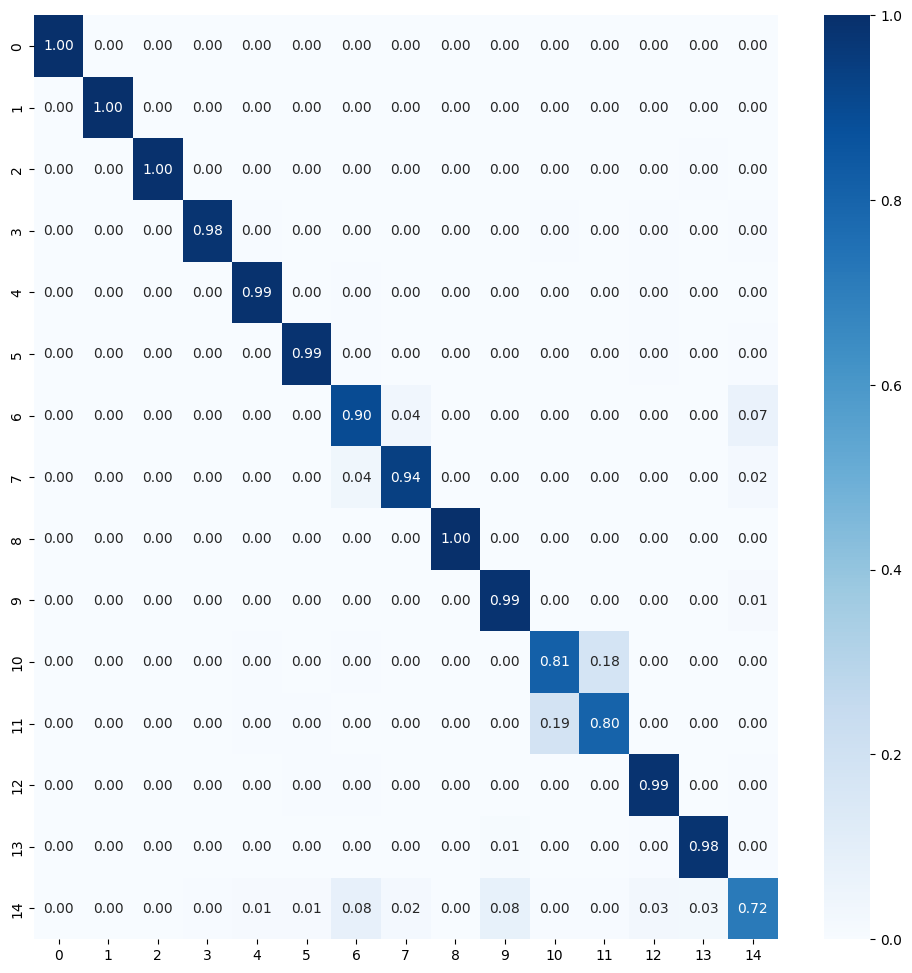


Best fold was 3 with val_accuracy: 0.9324
Average training accuracy in 5-fold: 0.9759384036064148
Average validation precision in 5-fold: 0.9314880967140198

Test Metrics
test_acc_list: [0.9359999895095825, 0.9359999895095825, 0.9377777576446533, 0.9371851682662964, 0.9386666417121887]
Average Test Accuracy with 5-fold: 0.9371259093284607
test_loss_list: [0.31643110513687134, 0.3133770227432251, 0.30693143606185913, 0.3084605634212494, 0.3112877905368805]
Average Test Log Loss with 5-fold: 0.3112975835800171

Precision List: [0.9350551588741186, 0.9351892992932549, 0.9369041795193236, 0.9360654267119425, 0.9379859567588393]
Average Precision List with 5-fold: 0.9362400042314958
Recall List: [0.9359999999999999, 0.9360000000000002, 0.9377777777777777, 0.9371851851851853, 0.9386666666666665]
Average Recall List with 5-fold: 0.9371259259259259
F1 Score List: [0.9352298235524167, 0.9350732349752299, 0.9369107345111547, 0.9361543032016596, 0.9377630464303354]
Average F1 Score List with 5-f

In [30]:
%%time

num_classes = 15
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

In [31]:
print(f"test_acc_list_all = {test_acc_list_all}")
print(f"test_loss_list_all = {test_loss_list_all}")
print(f"precision_list_all = {precision_list_all}")
print(f"recall_list_all = {recall_list_all}")
print(f"f1_score_list_all = {f1_score_list_all}")

test_acc_list_all = [1.0, 1.0, 0.9975555419921875, 0.9950222373008728, 0.9954074144363403, 0.9954285860061646, 0.9954444527626037, 0.9965432286262512, 0.9740444421768188, 0.954101026058197, 0.95659259557724, 0.9593162536621094, 0.9339682459831238, 0.9371259093284607]
test_loss_list_all = [0.0011768629075959325, 0.0024957763729617, 0.022699081525206565, 0.05747189000248909, 0.031307287886738776, 0.03628302589058876, 0.03232695758342743, 0.025811388343572616, 0.16328552663326262, 0.2854249894618988, 0.28129810094833374, 0.2551925957202911, 0.3193288564682007, 0.3112975835800171]
precision_list_all = [1.0, 1.0, 0.9975721933007347, 0.9950534306849759, 0.9954379854803864, 0.9954530464640581, 0.9954730681316809, 0.9965660783106497, 0.9739755060036934, 0.9537547883743484, 0.9561530349099716, 0.958875933088666, 0.9333313556625509, 0.9362400042314958]
recall_list_all = [1.0, 1.0, 0.9975555555555555, 0.9950222222222223, 0.9954074074074075, 0.9954285714285716, 0.9954444444444445, 0.99654320987654

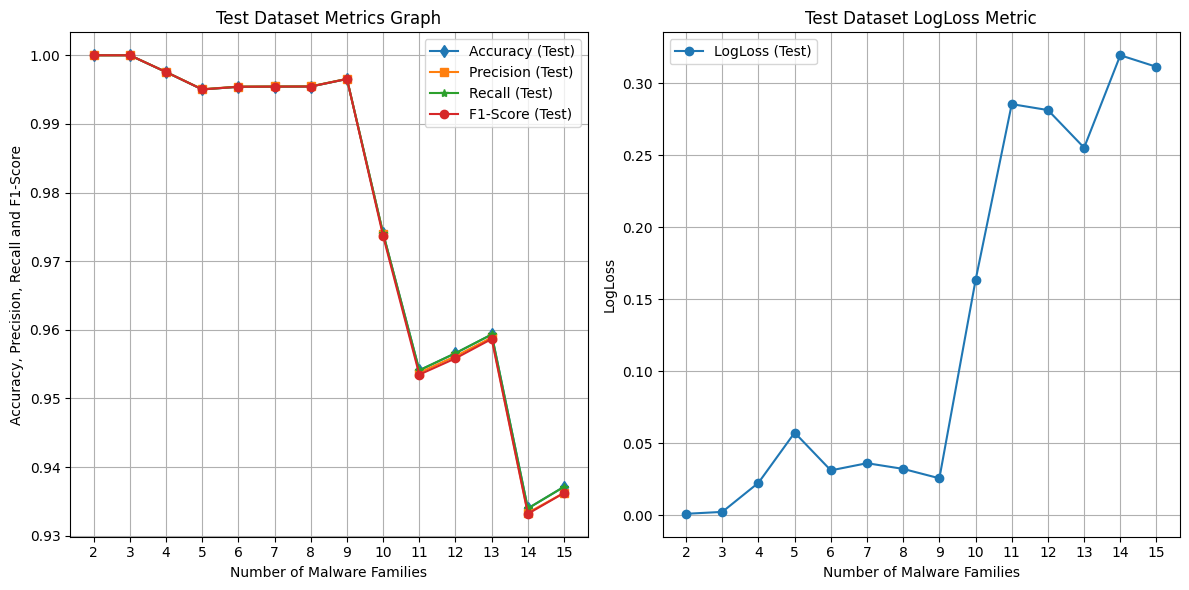

In [32]:
import matplotlib.pyplot as plt

# Datos históricos
strategies = [str(i) for i in range(2, len(test_acc_list_all) + 2)]

# Crear gráfico para Test Accuracy y Test LogLoss en una fila con dos columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


# Gráfico para Test Accuracy, Precision, Recall and F1-Score
axes[0].plot(strategies, test_acc_list_all, marker='d', label='Accuracy (Test)')
axes[0].plot(strategies, precision_list_all, marker='s', label='Precision (Test)')
axes[0].plot(strategies, recall_list_all, marker='*', label='Recall (Test)')
axes[0].plot(strategies, f1_score_list_all, marker='o', label='F1-Score (Test)')
axes[0].set_title('Test Dataset Metrics Graph')
axes[0].set_xlabel('Number of Malware Families')
axes[0].set_ylabel('Accuracy, Precision, Recall and F1-Score')
axes[0].legend()
axes[0].grid(True)

# Gráfico para Test LogLoss
axes[1].plot(strategies, test_loss_list_all, marker='o', label='LogLoss (Test)')
axes[1].set_title('Test Dataset LogLoss Metric')
axes[1].set_xlabel('Number of Malware Families')
axes[1].set_ylabel('LogLoss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
